🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb) · [A4 Clustering](../diagnostics/A4_clustering_unsupervised.ipynb) · **[A5 PCA & dimensionality](../diagnostics/A5_pca_dimensionality.ipynb)**
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Auxiliary diagnostic (C · never selects a query). Dimensionality, PCA, and supervised/nonlinear reduction across all eight functions.**

---

# You Sank My Function! — PCA, Dimensionality & Advanced Reduction
## Imperial College Business School — Capstone Project

> **Purpose.** A4 asked whether the *design geometry* falls into groups. This notebook asks the
> prior question: **how many directions does the design actually live in, and are they the
> directions that matter?**
>
> PCA answers the first half. It finds the orthogonal directions of greatest variance in
> $\mathbf{X}$, ranks them, and tells you how much of the spread each one carries. That is a
> statement about **where you have sampled** — not about the function.
>
> The second half is where most PCA analyses quietly go wrong. **Variance is not relevance.**
> The direction along which your design spreads most is under no obligation to be the direction
> along which $y$ changes most. Sections 8 and 9 measure that gap directly and introduce the two
> tools that close it — **PLS** and **active subspaces** — both of which use $y$ on purpose,
> rather than by accident.

### Why the eight functions make this a good teaching set

The challenge hands us a **natural dimensionality ladder**: $d = 2, 2, 3, 4, 4, 5, 6, 8$ with the
same kind of design and the same $[0,1]^d$ box in every case. That is a controlled experiment in
the curse of dimensionality that you would otherwise have to simulate. Every claim about "PCA
degrades in high dimensions" can be checked against our own data rather than asserted.

| Function | Dims | Working hypothesis | What this notebook asks of it |
|----------|------|--------------------|-------------------------------|
| F1 | 2D | Branin-Hoo (3 optima) | PCA cannot reduce 2D usefully — so what *is* it doing? Also: a pathological $y$ scale, the preprocessing lesson |
| F2 | 2D | Six-hump camelback | The clean 2D control: hand-computed PCA verified against `sklearn` |
| F3 | 3D | Hartmann 3D (confirmed ✓) | First case where a 2D projection is a genuine reduction |
| F4 | 4D | Shekel / smooth basin | Wide $y$ range — does a rank transform change the conclusions? |
| F5 | 4D | Hartmann 4D scaled | $y \sim 10^4$. The scaling trap, and the clearest example of BO distorting the spectrum |
| F6 | 5D | Rejected Styblinski-Tang | A2 found an $x_5$ signal — do loadings and the active subspace agree? |
| F7 | 6D | Hartmann 6D negated (confirmed ✓) | **Control** — known structure, verifiable reduction |
| F8 | 8D | Ackley negated/shifted | The hard end of the ladder: intrinsic dimension, distance concentration, and where PCA stops helping |

---

**Educational framing, not a competitive engine.** Nothing here selects a query. PCA has no
uncertainty model and therefore no acquisition function. What it can do is tell you whether an
8-dimensional problem is *really* 8-dimensional, which changes how you spend your remaining
evaluations.

**How to use it each week:** drop the updated `consolidated_observations.csv` next to the notebook
and re-run all cells. Every spectrum, loading, test and figure recomputes.

---
## Section 1 — Theory: what PCA is, precisely

### 1.1 The two definitions, and why they coincide

Take $n$ observations in $d$ dimensions, stacked as $\mathbf{X} \in \mathbb{R}^{n \times d}$, and
**centre** each column so that $\bar{x}_j = 0$. PCA can be defined two ways, and they give the
same answer:

**Maximum variance.** Find the unit vector $\mathbf{w}_1$ along which the projected data spreads most:

$$
\mathbf{w}_1 \;=\; \arg\max_{\lVert \mathbf{w} \rVert = 1} \; \operatorname{Var}(\mathbf{X}\mathbf{w})
\;=\; \arg\max_{\lVert \mathbf{w} \rVert = 1} \; \mathbf{w}^\top \mathbf{S} \, \mathbf{w},
\qquad
\mathbf{S} = \tfrac{1}{n-1}\mathbf{X}^\top \mathbf{X}
$$

**Minimum reconstruction error.** Find the $k$-dimensional subspace whose orthogonal projection
$\Pi_k$ loses least:

$$
\min_{\Pi_k} \; \sum_{i=1}^{n} \lVert \mathbf{x}_i - \Pi_k \mathbf{x}_i \rVert^2
$$

Both are solved by the eigenvectors of the covariance matrix $\mathbf{S}$, ordered by eigenvalue:

$$
\mathbf{S}\mathbf{w}_k = \lambda_k \mathbf{w}_k, \qquad \lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d \ge 0
$$

The equivalence is worth internalising: *the directions that preserve the most spread are exactly
the directions that lose the least when you throw the rest away.* Section 3 verifies this
numerically on F2.

### 1.2 Vocabulary — the four things people confuse

| Term | Shape | What it is |
|---|---|---|
| **Component / loading** $\mathbf{w}_k$ | $d \times 1$ | A *direction* in input space. Its entries say how much each original $x_j$ contributes |
| **Score** $\mathbf{X}\mathbf{w}_k$ | $n \times 1$ | The *coordinate* of each observation along that direction |
| **Eigenvalue** $\lambda_k$ | scalar | The variance of the $k$-th score |
| **Explained variance ratio** | scalar | $\lambda_k / \sum_j \lambda_j$ — the share of total spread that component carries |

`sklearn` gives you loadings in `pca.components_` (shape $k \times d$, one row per component) and
scores from `pca.transform(X)`. Mixing these up is the single most common PCA error in coursework.

**Sign is arbitrary.** $\mathbf{w}_k$ and $-\mathbf{w}_k$ are both valid eigenvectors, so "PC1
increases with $x_3$" is only meaningful relative to a convention you fix yourself. Section 7 fixes one.

### 1.3 SVD is the same thing, computed better

For centred $\mathbf{X}$, the singular value decomposition $\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$ gives

$$
\mathbf{S} = \frac{\mathbf{X}^\top\mathbf{X}}{n-1} = \mathbf{V}\frac{\boldsymbol{\Sigma}^2}{n-1}\mathbf{V}^\top
\quad\Longrightarrow\quad
\mathbf{w}_k = \mathbf{v}_k, \qquad \lambda_k = \frac{\sigma_k^2}{n-1}
$$

`sklearn` uses SVD, never forming $\mathbf{X}^\top\mathbf{X}$ explicitly, because squaring the
matrix squares its condition number. With $n = 22$ and near-collinear columns that matters.
Section 3 confirms the two routes agree to machine precision.

### 1.4 Preprocessing is not a detail — it *is* the analysis

**Centring is mandatory.** Skip it and the first "component" mostly points at the mean of the
cloud, which is not structure.

**Scaling is a modelling choice, not a default.** Two matrices, two different analyses:

- **Covariance PCA** (centre only) — components chase whichever column has the largest raw spread.
- **Correlation PCA** (centre *and* divide by $s_j$) — every variable gets equal say.

Our inputs are all confined to $[0,1]^d$ by construction, so the two are *nearly* the same here —
but not identical, because the design does not fill every axis to the same extent. Section 4
quantifies exactly how much this changes for each function.

The moment $y$ joins the matrix, the choice stops being cosmetic. F5's outputs run to $\sim 10^4$
while its inputs sit inside $[0,1]$. Append $y$ unstandardised and **PC1 becomes $y$**, carrying
essentially 100% of the variance — a spectacular-looking result that contains no information
whatsoever. Section 4.3 does this deliberately so you can see the number.

**Transforming $y$ itself.** F1's outputs span 170 orders of magnitude; F5's span four. A
colour scale or a regression on raw $y$ is dominated by a handful of points in both cases.
Section 2.4 compares three treatments — identity, signed log, and rank — and states which one
each function gets and why.

### 1.5 How many components? Five rules, none of them authoritative

| Rule | Statement | Weakness |
|---|---|---|
| **Cumulative variance** | Keep enough PCs for 90% or 95% | The threshold is a convention, not a result |
| **Kaiser** | Keep $\lambda_k > 1$ (correlation PCA) | Over-retains; the cut is arbitrary at $\lambda = 1.001$ |
| **Scree elbow** | Keep up to the bend | Subjective — so we locate it geometrically, as A4 did for $K$ |
| **Broken stick** | Keep $\lambda_k$ above $b_k = \frac{1}{d}\sum_{i=k}^{d} \frac{1}{i}$ | Assumes a specific null |
| **Parallel analysis** | Keep $\lambda_k$ above the 95th percentile of shuffled data | Needs simulation, but is the honest one |

**Parallel analysis** (Horn, 1965) is the direct analogue of A4's permutation test. Shuffle each
column of $\mathbf{X}$ independently — this destroys correlations *between* columns while
preserving each column's own marginal distribution — recompute the eigenvalues, and repeat.
A component is real only if its eigenvalue beats what pure noise produces. Section 5 runs all
five rules side by side and shows how often they disagree.

**Expect them to retain almost everything.** Latin hypercube and Sobol designs are engineered to
spread points *evenly in every direction*. An ideal space-filling design in $[0,1]^d$ has a
covariance matrix close to $\frac{1}{12}\mathbf{I}$ — all eigenvalues equal, no compressible
structure at all. A flat scree plot is the design working correctly. Recognising this is the
difference between reporting a finding and reporting a tautology.

### 1.6 Effective dimensionality: a number instead of a threshold

Rather than pick a cut, summarise the whole spectrum. With $p_k = \lambda_k / \sum_j \lambda_j$:

$$
d_{\text{eff}}^{\text{PR}} = \frac{\left(\sum_k \lambda_k\right)^2}{\sum_k \lambda_k^2}
\qquad\qquad
d_{\text{eff}}^{\text{H}} = \exp\!\left(-\sum_k p_k \log p_k\right)
$$

The **participation ratio** and the **exponential of the spectral entropy** both equal $d$ when all
eigenvalues are equal, and fall towards 1 as the spectrum concentrates. They give a continuous
reading of "how many directions is this design really using", which is far more useful for
tracking week-on-week than a retained-component count that jumps between integers.

### 1.7 What PCA cannot do

- **It is unsupervised.** $y$ is never consulted, so nothing guarantees that a high-variance
  direction is a relevant one. In our data the failure turns out to be subtler and more
  interesting than the textbook version — see Section 8.
- **It is linear.** A curved manifold gets flattened. Section 10 brings in kernel PCA, and Section 11 Isomap,
  MDS and $t$-SNE for that, along with the metric needed to tell whether they helped.
- **It is unstable at our sample sizes.** Eigenvectors of a covariance matrix estimated from
  22 points in 2D — or 52 in 8D — move under resampling. Section 7 bootstraps them rather than
  assuming they are fixed.
- **It cannot propose a query.** No $\sigma(\mathbf{x})$, no acquisition function. Same standing
  as A1, A2 and A4: diagnostic only.

### 1.8 The advanced techniques, and what each is for

| Method | Uses $y$? | Linear? | Use it when | Section |
|---|---|---|---|---|
| **PCA** | No | Yes | You want an honest description of the design's geometry | 3–7 |
| **Sparse PCA** | No | Yes | You need loadings you can name a variable in | 7 |
| **PCR** | Only after | Yes | Baseline: is the top-variance subspace predictive? | 8 |
| **PLS** | Yes | Yes | You want the directions that predict $y$, not the ones that spread | 8 |
| **Active subspace** | Yes (gradients) | Yes | BBO in $d \ge 5$: which directions does the *function* actually respond to? | 9 |
| **Kernel PCA** | No | No | Curved structure you suspect is smooth | 10 |
| **Isomap / MDS** | No | No | Preserving geodesic or metric distances | 10 |
| **$t$-SNE** | No | No | Visual inspection only — never for measurement | 10 |
| **Random projection** | No | Yes | A sanity baseline: how good is "no thought at all"? | 10 |

Read that table as a decision tree, not a menu. For an optimisation problem the column that matters
is the second one: **methods that ignore $y$ can only ever describe your sampling.**

---
## Section 2 — Setup, data contract, and the exploration toolkit

### Cell 1 — Imports and global settings

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy import stats
from scipy.spatial.distance import pdist, squareform

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA, KernelPCA, SparsePCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.manifold import TSNE, Isomap, MDS, trustworthiness
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score, adjusted_rand_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.random_projection import GaussianRandomProjection
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel

warnings.filterwarnings('ignore')

RANDOM_STATE = 42      # every stochastic step is seeded with this
N_PERM       = 500     # replicates for parallel analysis and permutation tests
N_BOOT       = 400     # bootstrap replicates for loading stability
CV_FOLDS     = 5       # folds for every cross-validated comparison

# UMAP is optional -- it is not part of the standard scikit-learn stack.
try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

print('Imports OK.')
print(f'Reproducibility : RANDOM_STATE={RANDOM_STATE}')
print(f'Resampling      : {N_PERM} permutations, {N_BOOT} bootstraps, {CV_FOLDS}-fold CV')
print(f'UMAP available  : {HAS_UMAP}' + ('' if HAS_UMAP else '   (Section 11 will skip it -- pip install umap-learn to enable)'))

Imports OK.
Reproducibility : RANDOM_STATE=42
Resampling      : 500 permutations, 400 bootstraps, 5-fold CV
UMAP available  : False   (Section 11 will skip it -- pip install umap-learn to enable)


### Cell 2 — Load all eight functions

Identical data contract to A1/A2/A4: one tidy CSV, one row per evaluation, all eight functions.
`dim` tells us how many of the `x1..x8` columns are active for each function — the rest are `NaN`
and must never be fed to a model. `source` separates the space-filling design (`initial`) from the
live Bayesian-optimisation points (`weekly`), a distinction that turns out to matter a great deal
in Section 6.

In [2]:
DATA_FILE = os.environ.get("BBO_DATA_FILE", "consolidated_observations.csv")
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"Could not find {DATA_FILE!r} in {os.getcwd()!r}. "
        "Put consolidated_observations.csv next to this notebook, "
        "or set the BBO_DATA_FILE environment variable."
    )
OBS = pd.read_csv(DATA_FILE)


def load_function(fid):
    """Bundle everything the PCA cells need for one function.

    Keys
    ----
    fid, dim, xcols : identity and the ACTIVE input columns only
    X, y            : (n, dim) inputs and (n,) outputs, all observations
    X_init, y_init  : the space-filling design only
    X_week, y_week  : the weekly Bayesian-optimisation points only
    df              : raw rows, ordered by week
    """
    if isinstance(fid, str):                       # accept 'function_5', 'f5', '5'
        fid = int("".join(ch for ch in fid if ch.isdigit()))
    sub = OBS[OBS["function"] == fid].sort_values("week").reset_index(drop=True)
    if sub.empty:
        raise ValueError(f"No rows for function {fid} in {DATA_FILE}.")
    dim   = int(sub["dim"].iloc[0])
    xcols = [f"x{i}" for i in range(1, dim + 1)]

    # Guard the data contract: an active column must never contain NaN,
    # and an inactive column must be entirely NaN.
    if sub[xcols].isna().any().any():
        raise ValueError(f"F{fid}: NaN inside an active input column.")

    def XY(frame):
        return frame[xcols].to_numpy(float), frame["y"].to_numpy(float)

    X,  y  = XY(sub)
    Xi, yi = XY(sub[sub["source"] == "initial"])
    Xw, yw = XY(sub[sub["source"] == "weekly"])
    return dict(fid=fid, dim=dim, xcols=xcols, X=X, y=y,
                X_init=Xi, y_init=yi, X_week=Xw, y_week=yw, df=sub)


FIDS = [1, 2, 3, 4, 5, 6, 7, 8]
DATA = {fid: load_function(fid) for fid in FIDS}
DIMS = {fid: DATA[fid]['dim'] for fid in FIDS}

# Convenience globals so cells can be run in isolation (F1_X, F1_y, ...)
for _fid, _d in DATA.items():
    globals()[f"F{_fid}_X"] = _d["X"]
    globals()[f"F{_fid}_y"] = _d["y"]

print(f"Loaded {len(OBS)} observations from {DATA_FILE} "
      f"(weeks {OBS['week'].min()}-{OBS['week'].max()}).")
print("The dimensionality ladder:",
      "  ".join(f"F{f}={DIMS[f]}D" for f in FIDS))

Loaded 279 observations from consolidated_observations.csv (weeks 0-13).
The dimensionality ladder: F1=2D  F2=2D  F3=3D  F4=4D  F5=4D  F6=5D  F7=6D  F8=8D


### Cell 3 — Plot theme and the core PCA utilities

Everything downstream is built from these. Each does one thing.

| Function | Role |
|----------|------|
| `style_ax(ax)` | Consistent dark-theme panel styling (matches A1–A4) |
| `get_X(fid, scaling, source)` | Build the input matrix under a named preprocessing choice |
| `fit_pca(Z)` | PCA on a prepared matrix → scores, loadings, eigenvalues, ratios |
| `eff_dim(evr)` | Participation ratio and entropy-based effective dimension |
| `broken_stick(d)` | The broken-stick null spectrum |
| `parallel_analysis(Z)` | Horn's parallel analysis — the permutation null for eigenvalues |
| `knee_index(vals)` | Geometric elbow, reused from A4 |
| `transform_y(y, mode)` | identity / signed-log / rank treatments of the output |
| `perm_test_corr(a, b)` | Permutation $p$-value for a correlation |
| `align_sign(w, ref)` | Fix PCA's arbitrary sign against a reference |

In [3]:
# -- Plot theme (matches the rest of the capstone notebooks) ------------------
BG, TC, AC = '#0d1117', 'white', '#aaaaaa'
PC_COLORS  = ['#44d9ff', '#ffb347', '#8dff8d', '#ff6b9d',
              '#c792ea', '#ffe066', '#7fdbca', '#ff9f43']
DIM_CMAP   = plt.get_cmap('plasma')


def style_ax(ax):
    """Dark background, muted ticks, subtle spines."""
    ax.set_facecolor(BG)
    ax.tick_params(colors='#666666', labelsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333333')
    ax.grid(True, color='#222222', linestyle='--', linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)


def dim_color(d):
    """One colour per input dimension, so the ladder reads consistently."""
    return DIM_CMAP((d - 2) / 6.0)


# -- Preprocessing -----------------------------------------------------------
SCALINGS = ['raw', 'standard', 'minmax', 'robust']


def get_X(fid, scaling='standard', source='all'):
    """Return (Z, scaler) -- the input matrix under one named preprocessing choice.

    scaling='raw'      : centred only  -> covariance PCA
    scaling='standard' : centred + /s  -> correlation PCA (the default here)
    scaling='minmax'   : rescaled to [0,1] per column, then centred by PCA itself
    scaling='robust'   : median / IQR  -> resistant to a single stray point

    source='all' | 'initial' | 'weekly' selects which observations to use.

    NOTE: PCA always centres internally, so 'raw' still means "centred, not scaled".
    """
    d = DATA[fid]
    M = {'all': d['X'], 'initial': d['X_init'], 'weekly': d['X_week']}[source]
    if scaling == 'raw':
        return M.copy(), None
    scaler = {'standard': StandardScaler(),
              'minmax':   MinMaxScaler(),
              'robust':   RobustScaler()}[scaling]
    return scaler.fit_transform(M), scaler


def fit_pca(Z, n_components=None, random_state=RANDOM_STATE):
    """PCA on an already-prepared matrix.

    Returns a dict with scores, loadings (n_comp x d), eigenvalues, explained
    variance ratio, cumulative ratio, and the fitted estimator.
    """
    n_components = n_components or min(Z.shape)
    p = PCA(n_components=n_components, random_state=random_state)
    scores = p.fit_transform(Z)
    return dict(pca=p, scores=scores, loadings=p.components_,
                eig=p.explained_variance_, evr=p.explained_variance_ratio_,
                cum=np.cumsum(p.explained_variance_ratio_))


def eff_dim(evr):
    """Effective dimensionality: (participation ratio, exp of spectral entropy).

    Both equal d when the spectrum is flat and approach 1 when one component
    carries everything. Reported as a continuous alternative to a retained count.
    """
    p = np.asarray(evr, float)
    p = p[p > 0]
    pr = 1.0 / np.sum(p ** 2)                       # equals (sum L)^2 / sum L^2
    H  = -np.sum(p * np.log(p))
    return float(pr), float(np.exp(H))


def broken_stick(d):
    """Expected proportions under the broken-stick null: b_k = (1/d) sum_{i=k}^d 1/i."""
    return np.array([np.sum(1.0 / np.arange(k, d + 1)) / d for k in range(1, d + 1)])


def parallel_analysis(Z, n_perm=N_PERM, random_state=RANDOM_STATE):
    """Horn's parallel analysis.

    Shuffle each COLUMN independently. This keeps every marginal distribution
    exactly as observed while destroying all between-column association, so the
    null answers precisely the right question: 'how large would this eigenvalue
    be if the variables were unrelated?'

    Returns (null_mean, null_p95, p_values) -- each of length d.
    """
    rng = np.random.default_rng(random_state)
    Z   = np.asarray(Z, float)
    n, d = Z.shape
    obs = PCA(n_components=d).fit(Z).explained_variance_
    null = np.empty((n_perm, d))
    for b in range(n_perm):
        S = np.column_stack([rng.permutation(Z[:, j]) for j in range(d)])
        null[b] = PCA(n_components=d).fit(S).explained_variance_
    p = ((null >= obs).sum(axis=0) + 1) / (n_perm + 1)   # add-one: never p=0
    return null.mean(axis=0), np.percentile(null, 95, axis=0), p


def knee_index(vals):
    """Index of the geometric knee of a decreasing curve (A4's elbow_k, generalised).

    Both axes are min-max normalised first, otherwise the y-scale swamps the
    x-scale and the answer is always the second point.
    """
    v = np.asarray(vals, float)
    if len(v) < 3:
        return 0
    x = np.arange(len(v), dtype=float)
    x = (x - x.min()) / (np.ptp(x) if np.ptp(x) else 1.0)
    y = (v - v.min()) / (np.ptp(v) if np.ptp(v) else 1.0)
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    u = (p2 - p1) / np.linalg.norm(p2 - p1)
    dist = [np.linalg.norm((np.array([xi, yi]) - p1)
                           - ((np.array([xi, yi]) - p1) @ u) * u)
            for xi, yi in zip(x, y)]
    return int(np.argmax(dist))


def transform_y(y, mode='identity'):
    """Three treatments of the output.

    'identity'   : as observed -- the only version you may quote as a number
    'signed_log' : sign(y) * log1p(|y| / s) with s a robust scale. Compresses
                   heavy tails while preserving sign and monotonicity
    'rank'       : ranks mapped to [0, 1]. Scale-free and outlier-proof, and it
                   keeps exactly the information an optimiser needs -- the ORDER
    """
    y = np.asarray(y, float)
    if mode == 'identity':
        return y
    if mode == 'signed_log':
        s = np.median(np.abs(y - np.median(y)))
        s = s if s > 0 else (np.std(y) if np.std(y) > 0 else 1.0)
        return np.sign(y) * np.log1p(np.abs(y) / s)
    if mode == 'rank':
        return (stats.rankdata(y) - 1) / max(len(y) - 1, 1)
    raise ValueError(f"unknown y mode {mode!r}")


def recommend_y_mode(y):
    """Documented rule for choosing a y treatment. Stated, not hidden in an argmax.

    dynamic range > 1e6 or |skew| > 1.5 -> 'rank'
    |skew| > 1.0                        -> 'signed_log'
    otherwise                           -> 'identity'
    """
    a = np.abs(np.asarray(y, float))
    a = a[a > 0]
    dyn = (a.max() / a.min()) if len(a) else 1.0
    sk  = float(stats.skew(y))
    if dyn > 1e6 or abs(sk) > 1.5:
        return 'rank', dyn, sk
    if abs(sk) > 1.0:
        return 'signed_log', dyn, sk
    return 'identity', dyn, sk


def perm_test_corr(a, b, n_perm=N_PERM, random_state=RANDOM_STATE):
    """Two-sided permutation p-value for |corr(a, b)|. Returns (r, p)."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    if np.std(a) == 0 or np.std(b) == 0:
        return 0.0, 1.0
    r = float(np.corrcoef(a, b)[0, 1])
    rng = np.random.default_rng(random_state)
    null = np.array([abs(np.corrcoef(a, rng.permutation(b))[0, 1])
                     for _ in range(n_perm)])
    p = float((null >= abs(r)).sum() + 1) / (n_perm + 1)
    return r, p


def align_sign(w, ref):
    """Flip w so it points the same way as ref. PCA's sign is arbitrary; a
    comparison across bootstrap replicates or across scalings is meaningless
    until you impose a convention."""
    return w if float(np.dot(w, ref)) >= 0 else -w


print('Utilities defined:')
for f in ['style_ax', 'dim_color', 'get_X', 'fit_pca', 'eff_dim', 'broken_stick',
          'parallel_analysis', 'knee_index', 'transform_y', 'recommend_y_mode',
          'perm_test_corr', 'align_sign']:
    print(f'  - {f}')

Utilities defined:
  - style_ax
  - dim_color
  - get_X
  - fit_pca
  - eff_dim
  - broken_stick
  - parallel_analysis
  - knee_index
  - transform_y
  - recommend_y_mode
  - perm_test_corr
  - align_sign


### Cell 4 — Inventory: the sample-size reality check, one dimension at a time

Before any decomposition, look at what each function actually gives you. Two columns decide how
much of this notebook is trustworthy for a given function:

- **obs/dim** — observations per input dimension. A covariance matrix in $d$ dimensions has
  $d(d+1)/2$ free parameters. F8 estimates 36 of them from 52 points. That is not comfortable.
- **params/obs** — that same count as a ratio. Above about $0.5$, treat every eigenvector as
  provisional and lean on Section 7's bootstrap rather than the point estimate.

The $y$ columns set up Section 2.4: `dyn range` is $\max|y| / \min|y|$ over the non-zero outputs,
and it is the number that decides whether a raw colour scale will show you anything at all.

In [4]:
rows = []
for fid in FIDS:
    d = DATA[fid]
    n, dim = len(d['y']), d['dim']
    mode, dyn, sk = recommend_y_mode(d['y'])
    n_cov = dim * (dim + 1) // 2
    rows.append({
        'Fn':          f'F{fid}',
        'Dim':         dim,
        'N':           n,
        'Init':        len(d['y_init']),
        'Weekly':      len(d['y_week']),
        'Obs/dim':     round(n / dim, 1),
        'Cov params':  n_cov,
        'Params/obs':  round(n_cov / n, 2),
        'y min':       f"{d['y'].min():.4g}",
        'y max':       f"{d['y'].max():.4g}",
        'y skew':      round(sk, 2),
        'dyn range':   f"{dyn:.2g}",
        'y treatment': mode,
    })

INVENTORY = pd.DataFrame(rows)
print('=' * 118)
print('  DATASET INVENTORY -- the dimensionality ladder')
print('=' * 118)
print(INVENTORY.to_string(index=False))

print('\n  Covariance-estimation load (d(d+1)/2 parameters from N points):')
for r in rows:
    flag = ('  !! strained'  if r['Params/obs'] > 0.5 else
            '  ~  workable'  if r['Params/obs'] > 0.25 else
            '  ok comfortable')
    print(f"    {r['Fn']}: {r['Cov params']:>2} parameters from {r['N']:>2} observations "
          f"= {r['Params/obs']:.2f} per obs{flag}")

Y_MODE = {r['Fn']: r['y treatment'] for r in rows}
print('\n  y treatment adopted per function (rule stated in recommend_y_mode):')
print('   ', {k: v for k, v in Y_MODE.items()})
print('\n  Rule: dyn range > 1e6 or |skew| > 1.5 -> rank; |skew| > 1.0 -> signed log; else identity.')
print('  Raw y is still what gets quoted as a number. The transform is for scales, colours and diagnostics.')

  DATASET INVENTORY -- the dimensionality ladder
Fn  Dim  N  Init  Weekly  Obs/dim  Cov params  Params/obs     y min      y max  y skew dyn range y treatment
F1    2 23    10      13     11.5           3        0.13 -0.003606          2    0.87  2.9e+170        rank
F2    2 23    10      13     11.5           3        0.13   -0.1261     0.6505   -0.63        47    identity
F3    3 28    15      13      9.3           6        0.21   -0.4432 -0.0003699   -2.41   1.2e+03        rank
F4    4 43    30      13     10.8          10        0.23    -32.63     0.6549   -0.21   1.2e+03    identity
F5    4 33    20      13      8.2          10        0.30    0.1129       8662    1.24   7.7e+04  signed_log
F6    5 33    20      13      6.6          15        0.45    -2.571    -0.2347   -0.22        11    identity
F7    6 43    30      13      7.2          21        0.49  0.002701      3.322    0.78   1.2e+03    identity
F8    8 53    40      13      6.6          36        0.68     5.592         10 

### 2.4 The preprocessing lesson, before anything else

Look at F1's `dyn range` above. Its outputs run from around $10^{-124}$ to $2$ — 170 orders of
magnitude. Almost every observation is numerically indistinguishable from zero next to the handful
that are not. Plot that on a linear colour scale and you get one bright point and twenty-one black
ones; regress on it and a single observation sets every coefficient.

This is not a data error. It is what a **sharply spiked landscape** looks like when you sample it:
the function is essentially flat at zero across most of the box, with narrow regions where it rises.
F5 has the same shape in milder form.

The three treatments in `transform_y` handle it differently:

- **identity** keeps the units, so it is the only version you may quote in the report.
- **signed log** compresses the tail while preserving sign and order. Good for regression targets.
- **rank** discards magnitude entirely and keeps only the ordering — which, for an *optimiser*,
  is very nearly all the information that matters. Scale-free, outlier-proof, and directly
  comparable across all eight functions.

### Cell 5 — Figure 1: what each treatment does to each function's output

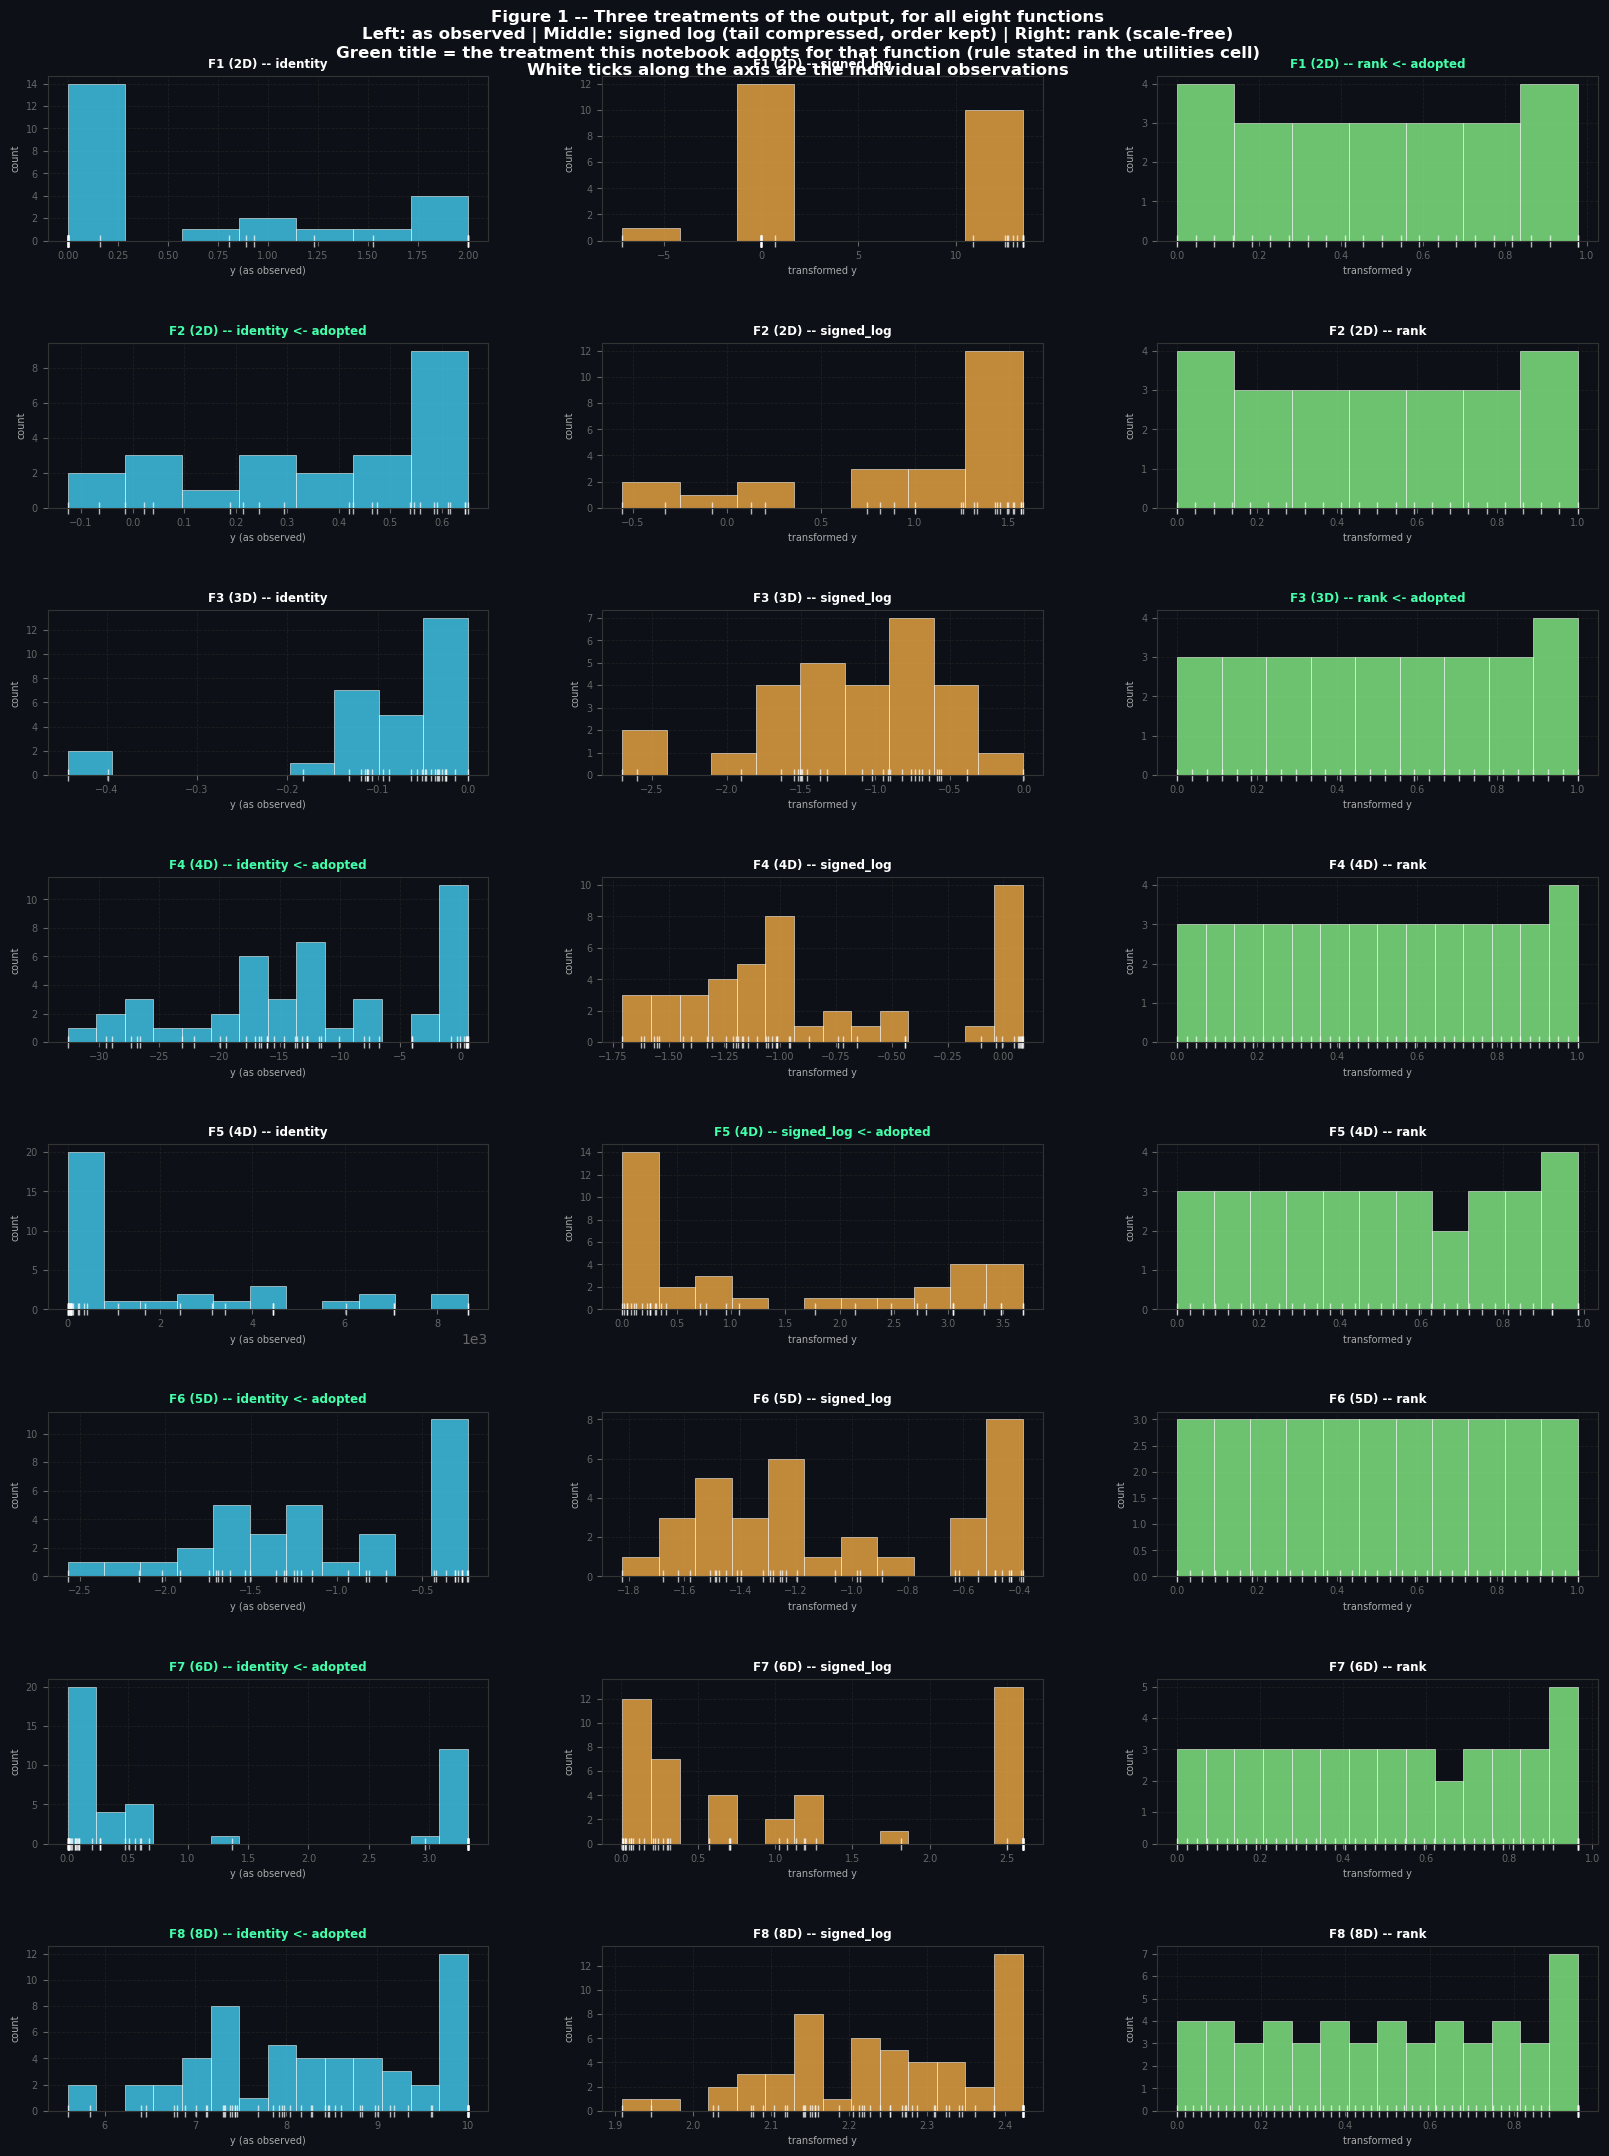

Saved pca_fig1_y_transforms.png

  Concentration of the raw output, by function:
    F1: the single most extreme observation carries  14.8% of the total absolute deviation from the median
    F2: the single most extreme observation carries  12.3% of the total absolute deviation from the median
    F3: the single most extreme observation carries  23.1% of the total absolute deviation from the median
    F4: the single most extreme observation carries   5.8% of the total absolute deviation from the median
    F5: the single most extreme observation carries  13.4% of the total absolute deviation from the median
    F6: the single most extreme observation carries   7.3% of the total absolute deviation from the median
    F7: the single most extreme observation carries   6.5% of the total absolute deviation from the median
    F8: the single most extreme observation carries   4.8% of the total absolute deviation from the median


In [5]:
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(8, 3, figure=fig, hspace=0.62, wspace=0.26,
                       top=0.955, bottom=0.030)

MODES = ['identity', 'signed_log', 'rank']
MODE_COL = {'identity': '#44d9ff', 'signed_log': '#ffb347', 'rank': '#8dff8d'}

for r, fid in enumerate(FIDS):
    d = DATA[fid]
    for c, mode in enumerate(MODES):
        ax = fig.add_subplot(gs[r, c])
        style_ax(ax)
        yt = transform_y(d['y'], mode)
        ax.hist(yt, bins=min(14, max(5, len(yt) // 3)), color=MODE_COL[mode],
                alpha=0.75, edgecolor='white', lw=0.5)
        rug = np.full(len(yt), 0.0)
        ax.plot(yt, rug, '|', color='white', ms=8, alpha=0.7, clip_on=False)
        chosen = ' <- adopted' if Y_MODE[f'F{fid}'] == mode else ''
        ax.set_title(f"F{fid} ({d['dim']}D) -- {mode}{chosen}",
                     color=('#44ffaa' if chosen else TC), fontsize=8.5,
                     fontweight='bold')
        ax.set_xlabel('transformed y' if c else 'y (as observed)',
                      color=AC, fontsize=7)
        ax.set_ylabel('count', color=AC, fontsize=7)
        if mode == 'identity' and np.ptp(d['y']) > 0:
            ax.ticklabel_format(axis='x', style='sci', scilimits=(-2, 3))

fig.suptitle(
    'Figure 1 -- Three treatments of the output, for all eight functions\n'
    'Left: as observed | Middle: signed log (tail compressed, order kept) | Right: rank (scale-free)\n'
    'Green title = the treatment this notebook adopts for that function (rule stated in the utilities cell)\n'
    'White ticks along the axis are the individual observations',
    color='white', fontsize=12, fontweight='bold', y=0.985)

plt.savefig('pca_fig1_y_transforms.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig1_y_transforms.png')

print('\n  Concentration of the raw output, by function:')
for fid in FIDS:
    y = DATA[fid]['y']
    share = float(np.max(np.abs(y - np.median(y))) / (np.sum(np.abs(y - np.median(y))) + 1e-300))
    print(f"    F{fid}: the single most extreme observation carries "
          f"{share*100:5.1f}% of the total absolute deviation from the median")

### Cell 6 — `explore(fid)`: the one-stop dossier for any function

This is the working tool for the rest of the term. Pass it a function id and it prints everything
you need before deciding how to spend a query: shape, sample size, output distribution, per-input
correlations with $y$, the PCA spectrum, effective dimensionality, and the current best point.

It is deliberately **dimension-aware** — the advice it prints changes with $d$, because a 2D
function and an 8D function need different things from you.

In [6]:
def explore(fid, y_mode=None, show=True):
    """Print a complete per-function dossier. Returns the summary dict.

    y_mode overrides the adopted treatment from the inventory cell if you want to compare.
    """
    d    = DATA[fid]
    dim  = d['dim']
    n    = len(d['y'])
    mode = y_mode or Y_MODE[f'F{fid}']
    yv   = transform_y(d['y'], mode)

    Z, _ = get_X(fid, 'standard')
    P    = fit_pca(Z)
    pr, he = eff_dim(P['evr'])
    n95  = int(np.searchsorted(P['cum'], 0.95) + 1)
    n90  = int(np.searchsorted(P['cum'], 0.90) + 1)
    best = int(np.argmax(d['y']))

    # marginal association of each input with the (transformed) output
    cors = np.array([np.corrcoef(d['X'][:, j], yv)[0, 1] for j in range(dim)])
    # association of each PC score with the output
    pcor = np.array([np.corrcoef(P['scores'][:, k], yv)[0, 1]
                     for k in range(P['scores'].shape[1])])

    out = dict(fid=fid, dim=dim, n=n, y_mode=mode, evr=P['evr'], cum=P['cum'],
               pr=pr, he=he, n90=n90, n95=n95, x_corr=cors, pc_corr=pcor,
               best_x=d['X'][best], best_y=float(d['y'][best]))
    if not show:
        return out

    bar = '=' * 92
    print(bar)
    print(f"  F{fid} DOSSIER  --  {dim}D, n={n} ({len(d['y_init'])} initial + {len(d['y_week'])} weekly)")
    print(bar)

    print(f"\n  OUTPUT   raw range [{d['y'].min():.4g}, {d['y'].max():.4g}]   "
          f"median {np.median(d['y']):.4g}   skew {stats.skew(d['y']):+.2f}")
    print(f"           treatment adopted: {mode}")

    print(f"\n  DESIGN COVERAGE (per input, over [0,1])")
    cov = pd.DataFrame({
        'input':      d['xcols'],
        'min':        np.round(d['X'].min(axis=0), 3),
        'max':        np.round(d['X'].max(axis=0), 3),
        'mean':       np.round(d['X'].mean(axis=0), 3),
        'sd':         np.round(d['X'].std(axis=0), 3),
        f'corr(x,y*)': np.round(cors, 3),
    })
    print(cov.to_string(index=False))
    j = int(np.argmax(np.abs(cors)))
    r_j, p_j = perm_test_corr(d['X'][:, j], yv)
    print(f"    strongest marginal: {d['xcols'][j]}  r={r_j:+.3f}  "
          f"(permutation p={p_j:.4f})"
          + ("  <- survives" if p_j < 0.05 else "  <- not distinguishable from chance"))

    print(f"\n  PCA SPECTRUM (standardised inputs, y excluded)")
    spec = pd.DataFrame({
        'PC':          [f'PC{k+1}' for k in range(len(P['evr']))],
        'eigenvalue':  np.round(P['eig'], 4),
        'evr %':       np.round(P['evr'] * 100, 1),
        'cumulative %': np.round(P['cum'] * 100, 1),
        'corr(PC,y*)': np.round(pcor, 3),
    })
    print(spec.to_string(index=False))
    print(f"    effective dimension: participation ratio {pr:.2f} / {dim}   "
          f"entropy-based {he:.2f} / {dim}")
    print(f"    components for 90% / 95% of variance: {n90} / {n95}  (of {dim})")
    k_top = int(np.argmax(np.abs(pcor)))
    print(f"    most y-associated component: PC{k_top+1} "
          f"(r={pcor[k_top]:+.3f}), which carries {P['evr'][k_top]*100:.1f}% of the variance")
    if k_top != 0:
        print(f"    NOTE: that is not PC1. Variance rank != relevance rank -- see Section 8.")

    print(f"\n  BEST OBSERVED   y = {d['y'][best]:.6g}")
    print(f"    x = {np.round(d['X'][best], 4).tolist()}")
    print(f"    portal format: {'-'.join(f'{v:.6f}' for v in d['X'][best])}")

    print(f"\n  WHAT TO DO AT {dim}D")
    if dim == 2:
        print("    Plot the raw inputs directly -- you lose nothing, and no projection")
        print("    can tell you more than the true scatter. PCA here is a rotation only:")
        print("    useful for teaching the mechanics, useless as compression.")
    elif dim <= 4:
        print("    A full pairs plot is still readable (6 panels at most). Use PCA as a")
        print("    cross-check on what the pairs plot shows, not as a replacement for it.")
    elif dim <= 6:
        print("    Pairs plots start to overwhelm. PCA/PLS projections become the primary")
        print("    view. Watch the explained-variance figure on every projection you read.")
    else:
        print("    Direct visualisation is finished. Reduction is mandatory, but so is")
        print("    validating it: check intrinsic dimension (Section 12) and trustworthiness")
        print("    (Section 11) before believing any 2D picture of this function.")
    print()
    return out


DOSSIER = {fid: explore(fid, show=False) for fid in FIDS}
explore(8)      # the hard end of the ladder, shown in full
print()
explore(1)      # and the easy end, for contrast

  F8 DOSSIER  --  8D, n=53 (40 initial + 13 weekly)

  OUTPUT   raw range [5.592, 10]   median 8.284   skew -0.14
           treatment adopted: identity

  DESIGN COVERAGE (per input, over [0,1])
input   min   max  mean    sd  corr(x,y*)
   x1 0.009 0.986 0.427 0.327      -0.770
   x2 0.003 0.974 0.391 0.301      -0.487
   x3 0.023 0.999 0.420 0.295      -0.764
   x4 0.009 0.903 0.360 0.257      -0.401
   x5 0.010 0.987 0.543 0.279       0.257
   x6 0.022 0.990 0.476 0.243       0.120
   x7 0.036 0.993 0.492 0.272      -0.584
   x8 0.042 0.989 0.536 0.250       0.182
    strongest marginal: x1  r=-0.770  (permutation p=0.0020)  <- survives

  PCA SPECTRUM (standardised inputs, y excluded)
 PC  eigenvalue  evr %  cumulative %  corr(PC,y*)
PC1      2.3658   29.0          29.0       -0.913
PC2      1.3795   16.9          45.9       -0.048
PC3      1.1890   14.6          60.5       -0.196
PC4      0.9117   11.2          71.7       -0.011
PC5      0.8967   11.0          82.7       -0.096
PC

{'fid': 1,
 'dim': 2,
 'n': 23,
 'y_mode': 'rank',
 'evr': array([0.58619122, 0.41380878]),
 'cum': array([0.58619122, 1.        ]),
 'pr': 1.9422836649898976,
 'he': 1.9703572120836201,
 'n90': 2,
 'n95': 2,
 'x_corr': array([0.3672607 , 0.33046648]),
 'pc_corr': array([ 0.45565485, -0.02859893]),
 'best_x': array([0.628468, 0.628468]),
 'best_y': 1.9999504877582948}

---
## Section 3 — PCA by hand on F2, then verified against `sklearn`

Before trusting a library call on an 8-dimensional matrix, do the whole computation manually on a
2-dimensional one where every intermediate quantity can be inspected. F2 is the right choice: it is
2D, its outputs are well behaved (skew $-0.58$, no transform needed), and its two inputs are
mildly correlated, so the components are not trivially the axes.

**The four steps.**

1. Centre: $\tilde{\mathbf{X}} = \mathbf{X} - \bar{\mathbf{x}}$
2. Covariance: $\mathbf{S} = \tilde{\mathbf{X}}^\top\tilde{\mathbf{X}} / (n-1)$
3. Eigendecompose: $\mathbf{S} = \mathbf{W}\boldsymbol{\Lambda}\mathbf{W}^\top$, sorted descending
4. Project: $\mathbf{T} = \tilde{\mathbf{X}}\mathbf{W}$

Then compare against SVD and against `sklearn`. All three must agree up to component sign.

### Cell 7 — Three routes to the same decomposition

In [7]:
fid = 2
d   = DATA[fid]
X   = d['X']
n, p_dim = X.shape

print('=' * 92)
print(f'  PCA BY HAND -- F{fid} ({p_dim}D, n={n}), standardised inputs')
print('=' * 92)

# Step 0 -- standardise (correlation PCA). Done explicitly so every number is visible.
mu, sd = X.mean(axis=0), X.std(axis=0, ddof=0)
Zh = (X - mu) / sd
print(f'\n  Step 0  column means  {np.round(mu, 4)}')
print(f'          column sds    {np.round(sd, 4)}')
print(f'          after scaling: means {np.round(Zh.mean(axis=0), 12)}, '
      f'sds {np.round(Zh.std(axis=0), 6)}')

# Step 1-2 -- covariance of the standardised data (= correlation of the raw data)
S = (Zh - Zh.mean(axis=0)).T @ (Zh - Zh.mean(axis=0)) / (n - 1)
print(f'\n  Step 2  covariance matrix S (= correlation matrix of raw X)')
print('         ', np.round(S, 4).tolist())
print(f'          trace(S) = {np.trace(S):.4f}   '
      f'(equals d = {p_dim} for a correlation matrix, up to the ddof convention)')

# Step 3 -- eigendecomposition, sorted descending
w_eig, W = np.linalg.eigh(S)                 # eigh: symmetric, returns ASCENDING
order = np.argsort(w_eig)[::-1]
w_eig, W = w_eig[order], W[:, order]
print(f'\n  Step 3  eigenvalues  {np.round(w_eig, 4)}')
print(f'          ratios       {np.round(w_eig / w_eig.sum(), 4)}')
print(f'          eigenvectors (columns):')
for k in range(p_dim):
    print(f'            w{k+1} = {np.round(W[:, k], 4)}   |w|={np.linalg.norm(W[:, k]):.6f}')
print(f'          orthogonality check  w1.w2 = {float(W[:, 0] @ W[:, 1]):.2e}')

# Step 4 -- scores
T_hand = (Zh - Zh.mean(axis=0)) @ W
print(f'\n  Step 4  score variances {np.round(T_hand.var(axis=0, ddof=1), 4)}'
      f'   <- these ARE the eigenvalues')

# Route B -- SVD of the centred matrix
Zc = Zh - Zh.mean(axis=0)
U, sv, Vt = np.linalg.svd(Zc, full_matrices=False)
eig_svd = sv ** 2 / (n - 1)
print(f'\n  ROUTE B (SVD)     eigenvalues {np.round(eig_svd, 4)}')

# Route C -- sklearn
P = fit_pca(Zh)
print(f'  ROUTE C (sklearn) eigenvalues {np.round(P["eig"], 4)}')

print(f'\n  AGREEMENT')
print(f'    |eig_hand - eig_svd|      max = {np.abs(w_eig - eig_svd).max():.2e}')
print(f'    |eig_hand - eig_sklearn|  max = {np.abs(w_eig - P["eig"]).max():.2e}')
load_hand = W.T                                            # rows = components
load_sk   = np.vstack([align_sign(P['loadings'][k], load_hand[k])
                       for k in range(p_dim)])
print(f'    |loadings| agree to        max = {np.abs(np.abs(load_hand) - np.abs(load_sk)).max():.2e}')
print(f'    (after aligning signs -- sklearn is free to return -w and often does)')

print(f'\n  RECONSTRUCTION -- the second definition of PCA')
for k in range(1, p_dim + 1):
    Zk = P['scores'][:, :k] @ P['loadings'][:k] + 0.0      # sklearn scores are centred
    err = np.mean(np.sum((Zc - Zk) ** 2, axis=1))
    print(f'    keep {k} of {p_dim} components -> mean squared reconstruction error '
          f'{err:.4f}   (discarded eigenvalue sum = {w_eig[k:].sum():.4f})')
print('    Those two columns match: the error of a k-component reconstruction is exactly')
print('    the sum of the eigenvalues you threw away. Maximum variance and minimum error')
print('    are the same optimisation problem seen from two sides.')

  PCA BY HAND -- F2 (2D, n=23), standardised inputs

  Step 0  column means  [0.6155 0.5473]
          column sds    [0.2144 0.3315]
          after scaling: means [0. 0.], sds [1. 1.]

  Step 2  covariance matrix S (= correlation matrix of raw X)
          [[1.0455, 0.2296], [0.2296, 1.0455]]
          trace(S) = 2.0909   (equals d = 2 for a correlation matrix, up to the ddof convention)

  Step 3  eigenvalues  [1.2751 0.8159]
          ratios       [0.6098 0.3902]
          eigenvectors (columns):
            w1 = [0.7071 0.7071]   |w|=1.000000
            w2 = [-0.7071  0.7071]   |w|=1.000000
          orthogonality check  w1.w2 = 0.00e+00

  Step 4  score variances [1.2751 0.8159]   <- these ARE the eigenvalues

  ROUTE B (SVD)     eigenvalues [1.2751 0.8159]
  ROUTE C (sklearn) eigenvalues [1.2751 0.8159]

  AGREEMENT
    |eig_hand - eig_svd|      max = 2.22e-16
    |eig_hand - eig_sklearn|  max = 3.33e-16
    |loadings| agree to        max = 2.22e-16
    (after aligning signs -- 

### Cell 8 — Uncorrelated scores, whitening, and what centring is actually for

Three properties asserted in Section 1 and never yet demonstrated. All three are one-liners once
the decomposition exists, and each is a claim you could otherwise take on faith and be wrong about.

**Scores are uncorrelated.** This is the property PCA is usually *sold* on — "a set of uncorrelated
components" — and it is not the same claim as "the loadings are orthogonal", which Cell 7 already
checked. Orthogonal loadings are a statement about directions in input space; uncorrelated scores
are a statement about the projected data. The eigendecomposition delivers both at once, because
$\operatorname{Cov}(\mathbf{T}) = \mathbf{W}^\top\mathbf{S}\mathbf{W} = \boldsymbol{\Lambda}$ —
diagonal, with the eigenvalues down the diagonal and exact zeros everywhere else.

**Whitening** goes one step further: divide each score by $\sqrt{\lambda_k}$ and the covariance
becomes the identity. Every direction now has unit variance, so Euclidean distance in whitened
space is Mahalanobis distance in the original. That is occasionally what you want — and often a
disaster, because it amplifies the smallest-variance directions, which at our sample sizes are
mostly estimation noise.

**Centring** is the step people skip because `sklearn` hides it. If you do not subtract the mean,
$\mathbf{X}^\top\mathbf{X}/(n-1)$ is not a covariance matrix — it is a second-moment matrix, and
its leading eigenvector is dominated by the *location* of the cloud rather than its shape. Our
inputs sit in $[0,1]^d$ with means near $0.5$, so the mean vector is large relative to the spread,
and the effect is severe. The cell below runs it both ways.

In [8]:
fid = 2
d   = DATA[fid]
dim = d['dim']
Z, _ = get_X(fid, 'standard')      # computed here, not from SPEC -- that is built in Section 5
P   = fit_pca(Z)

print('=' * 96)
print(f'  UNCORRELATED SCORES, WHITENING, AND CENTRING -- demonstrated on F{fid}')
print('=' * 96)

# -- 1. The scores are uncorrelated -----------------------------------------
T = P['scores']
C = np.cov(T.T, ddof=1)
print('\n  1. COVARIANCE OF THE SCORES  Cov(T) = W^T S W')
print('     ', np.array2string(C, precision=6, suppress_small=True).replace('\n', '\n      '))
off = C[~np.eye(dim, dtype=bool)]
print(f'     diagonal  = {np.round(np.diag(C), 5)}   <- these are the eigenvalues')
print(f'     eigenvalues = {np.round(P["eig"], 5)}')
print(f'     largest off-diagonal entry = {np.abs(off).max():.2e}  <- zero to machine precision')
print('     The components are UNCORRELATED. Note this is a stronger, different statement than')
print('     "the loadings are orthogonal": that one is about directions, this one is about data.')
Rm = np.corrcoef(Z.T)
print(f'\n     For contrast, the ORIGINAL inputs are correlated: largest |off-diagonal| '
      f'correlation = {np.abs(Rm[~np.eye(dim, dtype=bool)]).max():.4f}')
print('     Decorrelating them is what the rotation bought us.')

# -- 2. Whitening ------------------------------------------------------------
print('\n  2. WHITENING  T_white = T / sqrt(lambda)')
Tw = T / np.sqrt(P['eig'])
Cw = np.cov(Tw.T, ddof=1)
print('     ', np.array2string(Cw, precision=6, suppress_small=True).replace('\n', '\n      '))
print(f'     max |Cov(T_white) - I| = {np.abs(Cw - np.eye(dim)).max():.2e}')
print('     Every direction now carries unit variance, so Euclidean distance here equals')
print('     Mahalanobis distance in the original space.')
print(f'     The price: the smallest component was scaled up by a factor of '
      f'{np.sqrt(P["eig"][0] / P["eig"][-1]):.2f} relative to the largest.')
print('     At n = 22-52 the trailing directions are mostly estimation noise, so whitening')
print('     amplifies exactly what you would rather suppress. Used here to show the mechanism,')
print('     NOT adopted anywhere else in this notebook.')

# -- 3. Centring -------------------------------------------------------------
print('\n  3. CENTRING -- the step sklearn performs silently')
print('     Demonstrated on the RAW inputs, because that is where it bites. (On standardised')
print('     data the means are already zero, so centred and uncentred trivially agree -- which')
print('     is itself worth knowing: standardising has quietly done the centring for you.)')

Xr = DATA[fid]['X']
nr = len(Xr)
mu = Xr.mean(axis=0)
Xrc = Xr - mu
S_centred   = Xrc.T @ Xrc / (nr - 1)          # covariance
S_uncentred = Xr.T  @ Xr  / (nr - 1)          # second moment -- NOT a covariance

print(f'\n     column means of the raw inputs: {np.round(mu, 4)}   '
      f'|mean vector| = {np.linalg.norm(mu):.4f}')
print(f'     typical spread about the mean : {np.round(Xr.std(axis=0), 4)}')
print('     The mean vector is LARGER than the spread. Whatever dominates the uncentred')
print('     matrix will therefore be location, not shape.')

for label, M in [('centred (a covariance matrix)', S_centred),
                 ('uncentred (a second-moment matrix)', S_uncentred)]:
    w_, V_ = np.linalg.eigh(M)
    o = np.argsort(w_)[::-1]
    w_, V_ = w_[o], V_[:, o]
    v1 = align_sign(V_[:, 0], np.ones(dim))
    print(f'\n     {label}')
    print(f'       eigenvalues {np.round(w_, 5)}   PC1 share {w_[0]/w_.sum()*100:5.1f}%')
    print(f'       PC1 = {np.round(v1, 4)}')
    cos_mu = abs(float(v1 @ (mu / np.linalg.norm(mu))))
    print(f'       |cos| between this PC1 and the MEAN direction = {cos_mu:.4f}')

print('\n     Read the last line of each block. The uncentred PC1 lines up almost exactly with')
print('     the mean direction: its "dominant component" is pointing at where the cloud SITS,')
print('     not at how it is SHAPED. That is not structure, it is an origin -- and it inflates')
print('     the headline explained-variance figure while carrying no information at all.')
print('     An uncentred PCA always looks impressive. That is the problem with it.')

  UNCORRELATED SCORES, WHITENING, AND CENTRING -- demonstrated on F2

  1. COVARIANCE OF THE SCORES  Cov(T) = W^T S W
      [[ 1.275055 -0.      ]
       [-0.        0.815854]]
     diagonal  = [1.27506 0.81585]   <- these are the eigenvalues
     eigenvalues = [1.27506 0.81585]
     largest off-diagonal entry = 1.26e-17  <- zero to machine precision
     The components are UNCORRELATED. Note this is a stronger, different statement than
     "the loadings are orthogonal": that one is about directions, this one is about data.

     For contrast, the ORIGINAL inputs are correlated: largest |off-diagonal| correlation = 0.2196
     Decorrelating them is what the rotation bought us.

  2. WHITENING  T_white = T / sqrt(lambda)
      [[ 1. -0.]
       [-0.  1.]]
     max |Cov(T_white) - I| = 3.33e-16
     Every direction now carries unit variance, so Euclidean distance here equals
     Mahalanobis distance in the original space.
     The price: the smallest component was scaled up by a factor

### Cell 9 — Figure 2: the geometry, and what "rotation" means in 2D

Three panels for F2, and one for F1 alongside it.

- **Left** — standardised data with both component directions drawn, scaled by $\sqrt{\lambda_k}$
  so their lengths show the variance they carry.
- **Middle** — the same points in PC coordinates. Nothing has been lost: this is a rigid rotation.
  The cloud is now axis-aligned and PC1 is by construction the widest direction.
- **Right** — the 1-component reconstruction. Every point collapses onto the PC1 line, and the
  residual segments are what a "50% of variance retained" summary actually discards.

**The 2D lesson:** at $d=2$, PCA either keeps everything (a rotation, no compression) or halves the
dimension in one step (usually far too lossy). There is no useful middle. This is why F1 and F2 get
plotted directly everywhere else in the capstone, and why PCA earns its keep only from F3 upward.

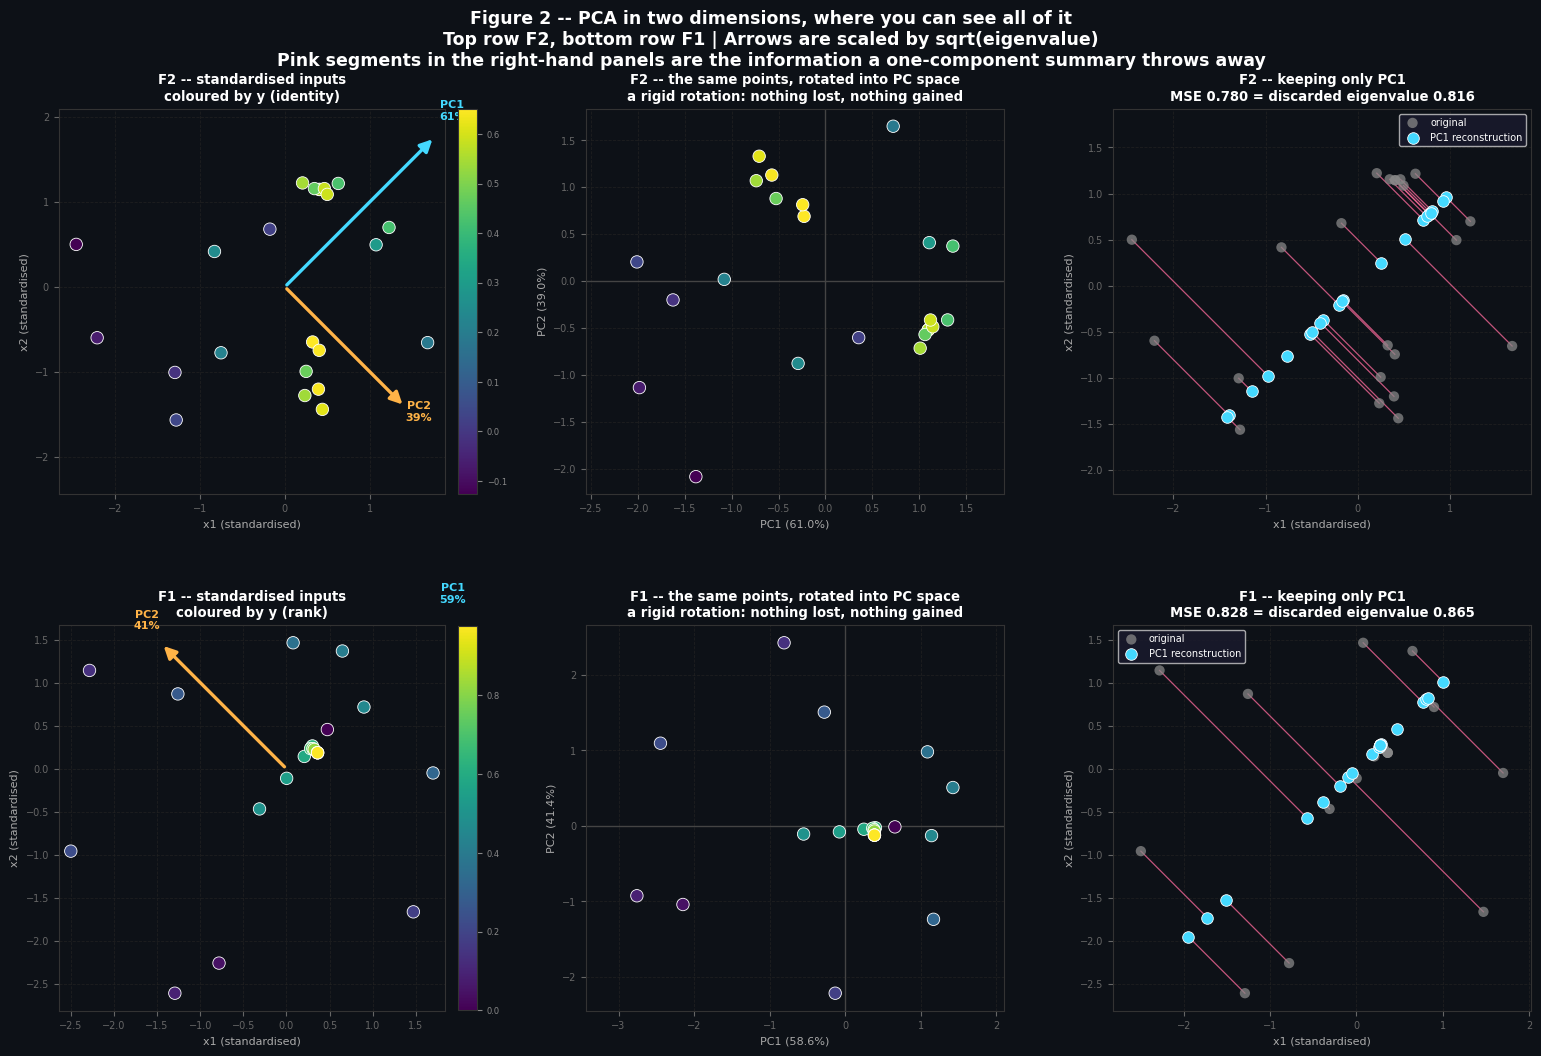

Saved pca_fig2_geometry_2d.png


In [9]:
fig = plt.figure(figsize=(19, 11))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.34, wspace=0.26,
                       top=0.885, bottom=0.065)

for row, fid in enumerate([2, 1]):
    dd = DATA[fid]
    Z, _ = get_X(fid, 'standard')
    Zc   = Z - Z.mean(axis=0)
    P    = fit_pca(Z)
    yv   = transform_y(dd['y'], Y_MODE[f'F{fid}'])

    # -- Panel A: original coordinates with component arrows -----------------
    ax = fig.add_subplot(gs[row, 0])
    style_ax(ax)
    sc = ax.scatter(Zc[:, 0], Zc[:, 1], c=yv, cmap='viridis', s=80,
                    edgecolor='white', lw=0.6, zorder=3)
    cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.03)
    cb.ax.tick_params(colors='#888888', labelsize=6)
    cb.outline.set_edgecolor('#333333')
    for k in range(2):
        w = align_sign(P['loadings'][k], np.ones(2))
        L = np.sqrt(P['eig'][k]) * 2.2
        ax.annotate('', xy=(w[0] * L, w[1] * L), xytext=(0, 0),
                    arrowprops=dict(color=PC_COLORS[k], lw=2.4,
                                    arrowstyle='-|>', mutation_scale=18), zorder=5)
        ax.text(w[0] * L * 1.12, w[1] * L * 1.12,
                f'PC{k+1}\n{P["evr"][k]*100:.0f}%', color=PC_COLORS[k],
                fontsize=8, fontweight='bold', ha='center', zorder=6)
    ax.set_title(f"F{fid} -- standardised inputs\ncoloured by y ({Y_MODE[f'F{fid}']})",
                 color=TC, fontsize=9.5, fontweight='bold')
    ax.set_xlabel('x1 (standardised)', color=AC, fontsize=8)
    ax.set_ylabel('x2 (standardised)', color=AC, fontsize=8)
    ax.set_aspect('equal', adjustable='datalim')

    # -- Panel B: PC coordinates ---------------------------------------------
    ax = fig.add_subplot(gs[row, 1])
    style_ax(ax)
    ax.axhline(0, color='#444444', lw=1)
    ax.axvline(0, color='#444444', lw=1)
    ax.scatter(P['scores'][:, 0], P['scores'][:, 1], c=yv, cmap='viridis',
               s=80, edgecolor='white', lw=0.6, zorder=3)
    ax.set_title(f"F{fid} -- the same points, rotated into PC space\n"
                 f"a rigid rotation: nothing lost, nothing gained",
                 color=TC, fontsize=9.5, fontweight='bold')
    ax.set_xlabel(f"PC1 ({P['evr'][0]*100:.1f}%)", color=AC, fontsize=8)
    ax.set_ylabel(f"PC2 ({P['evr'][1]*100:.1f}%)", color=AC, fontsize=8)
    ax.set_aspect('equal', adjustable='datalim')

    # -- Panel C: rank-1 reconstruction --------------------------------------
    ax = fig.add_subplot(gs[row, 2])
    style_ax(ax)
    Z1 = P['scores'][:, :1] @ P['loadings'][:1]
    for i in range(len(Zc)):
        ax.plot([Zc[i, 0], Z1[i, 0]], [Zc[i, 1], Z1[i, 1]],
                color='#ff6b9d', lw=0.9, alpha=0.75, zorder=2)
    ax.scatter(Zc[:, 0], Zc[:, 1], s=55, color='#888888', alpha=0.75,
               edgecolor='none', zorder=3, label='original')
    ax.scatter(Z1[:, 0], Z1[:, 1], s=70, color='#44d9ff',
               edgecolor='white', lw=0.6, zorder=4, label='PC1 reconstruction')
    err = float(np.mean(np.sum((Zc - Z1) ** 2, axis=1)))
    ax.set_title(f"F{fid} -- keeping only PC1\n"
                 f"MSE {err:.3f} = discarded eigenvalue {P['eig'][1]:.3f}",
                 color=TC, fontsize=9.5, fontweight='bold')
    ax.set_xlabel('x1 (standardised)', color=AC, fontsize=8)
    ax.set_ylabel('x2 (standardised)', color=AC, fontsize=8)
    ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white', loc='best')
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle(
    'Figure 2 -- PCA in two dimensions, where you can see all of it\n'
    'Top row F2, bottom row F1 | Arrows are scaled by sqrt(eigenvalue)\n'
    'Pink segments in the right-hand panels are the information a one-component summary throws away',
    color='white', fontsize=12.5, fontweight='bold', y=0.975)

plt.savefig('pca_fig2_geometry_2d.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig2_geometry_2d.png')

---
## Section 4 — Preprocessing decides the answer

Three experiments, in increasing order of how badly they can mislead you.

**4.1 — Which scaler?** Our inputs all live in $[0,1]^d$, so standardising should barely matter.
"Should" is a hypothesis; the cell below measures it. The comparison is made on the **subspace**
rather than the numbers: two preprocessing choices agree if the principal directions they produce
span the same space, which is what the *principal angle* between subspaces measures.

**4.2 — Does the $y$ treatment change the geometry?** It should not — $y$ is not in the matrix.
This is included as a control, and a control that comes out as expected is still worth running.

**4.3 — The circularity trap.** A4's Section 6 showed what happens when $y$ enters a clustering
feature matrix. For PCA the failure is even starker, because PCA reports the damage as a headline
percentage. Append raw $y$ to F5's inputs and PC1 will be $y$, at essentially 100% of the variance.
The analysis is not wrong; it is empty. You put the answer in and read it back out.

### Cell 10 — Scaler comparison across all eight functions

In [10]:
def principal_angle(A, B):
    """Largest principal angle (degrees) between two subspaces given as row-stacked
    orthonormal bases. 0 deg = identical subspace, 90 deg = orthogonal.

    This is the right comparison for PCA: individual eigenvectors can swap or flip
    without the SUBSPACE they span changing at all.
    """
    Qa = np.linalg.qr(np.asarray(A).T)[0]
    Qb = np.linalg.qr(np.asarray(B).T)[0]
    s  = np.linalg.svd(Qa.T @ Qb, compute_uv=False)
    return float(np.degrees(np.arccos(np.clip(s.min(), -1, 1))))


print('=' * 112)
print('  4.1  DOES THE SCALER MATTER?  Inputs are already in [0,1]^d, so this is a real question')
print('=' * 112)

rows = []
for fid in FIDS:
    dim = DIMS[fid]
    k   = max(1, dim // 2)                      # compare the top half of the spectrum
    ref = fit_pca(get_X(fid, 'standard')[0])
    rec = {'Fn': f'F{fid}', 'Dim': dim, 'k compared': k,
           'PC1% (standard)': round(ref['evr'][0] * 100, 1)}
    for sc in ['raw', 'minmax', 'robust']:
        cur = fit_pca(get_X(fid, sc)[0])
        rec[f'PC1% ({sc})'] = round(cur['evr'][0] * 100, 1)
        rec[f'angle vs std ({sc})'] = round(
            principal_angle(ref['loadings'][:k], cur['loadings'][:k]), 1)
    rows.append(rec)

SCALER_TABLE = pd.DataFrame(rows)
print(SCALER_TABLE.to_string(index=False))
print('\n  Angles are in degrees between the top-k principal SUBSPACES.')
print('    < 5 deg  : the choice is cosmetic for this function')
print('    5-20 deg : the choice shifts the analysis; state which you used')
print('    > 20 deg : the choice IS the analysis; justify it explicitly')

worst = max(FIDS, key=lambda f: max(
    SCALER_TABLE.loc[SCALER_TABLE['Fn'] == f'F{f}', c].iloc[0]
    for c in SCALER_TABLE.columns if c.startswith('angle')))
print(f'\n  Largest sensitivity to the scaler: F{worst}')

print('\n' + '=' * 112)
print('  4.2  CONTROL -- does the y treatment move the input geometry? (it must not)')
print('=' * 112)
moved = []
for fid in FIDS:
    ref = fit_pca(get_X(fid, 'standard')[0])['loadings']
    for mode in ['identity', 'signed_log', 'rank']:
        _ = transform_y(DATA[fid]['y'], mode)          # computed, deliberately unused
        cur = fit_pca(get_X(fid, 'standard')[0])['loadings']
        if principal_angle(ref, cur) > 1e-8:
            moved.append((fid, mode))
print(f'  Functions whose loadings moved under a change of y treatment: '
      f'{len(moved)} of {len(FIDS)}')
print('  Zero is the only acceptable answer, and it is guaranteed by construction: PCA is')
print('  fitted on X alone, so y cannot reach it. The control is worth running anyway --')
print('  if this ever came back non-zero, you would have leaked y into the feature matrix,')
print('  which is exactly the failure 4.3 walks into on purpose.')

  4.1  DOES THE SCALER MATTER?  Inputs are already in [0,1]^d, so this is a real question
Fn  Dim  k compared  PC1% (standard)  PC1% (raw)  angle vs std (raw)  PC1% (minmax)  angle vs std (minmax)  PC1% (robust)  angle vs std (robust)
F1    2           1             58.6        58.8                 5.4           58.8                    5.5           61.7                   21.6
F2    2           1             61.0        72.8                32.0           71.3                   30.7           83.7                   37.9
F3    3           1             43.3        46.7                50.9           46.4                   47.5           50.8                   41.4
F4    4           2             37.0        38.8                 8.6           38.2                    6.7           39.7                   27.8
F5    4           2             52.3        52.0                 4.5           53.7                    5.2           52.5                    4.2
F6    5           2             37.7    

### Cell 11 — 4.3 The circularity trap, quantified

Three feature matrices per function:

- **(A)** $\mathbf{X}$ standardised — the honest setup used everywhere else in this notebook
- **(B)** $[\mathbf{X} \mid y]$, everything standardised — $y$ is one column among $d+1$
- **(C)** $[\mathbf{X} \mid y]$, raw — the scale trap

Column **`y in PC1`** is the headline: the squared loading of $y$ on the first component, i.e. the
share of PC1's direction that is simply the output axis. When that hits 1.00, PCA has found
nothing except the variable you handed it.

In [11]:
print('=' * 118)
print('  4.3  WHAT HAPPENS WHEN y ENTERS THE FEATURE MATRIX')
print('=' * 118)

rows = []
for fid in FIDS:
    d   = DATA[fid]
    dim = d['dim']

    Za = get_X(fid, 'standard')[0]
    Pa = fit_pca(Za)

    Mb = StandardScaler().fit_transform(np.column_stack([d['X'], d['y']]))
    Pb = fit_pca(Mb)

    Mc = np.column_stack([d['X'], d['y']])           # NOT standardised
    Pc = fit_pca(Mc)

    y_share_raw = float(Mc.var(axis=0)[-1] / Mc.var(axis=0).sum())
    rows.append({
        'Fn':               f'F{fid}',
        'Dim':              dim,
        'PC1% (A: X)':      round(Pa['evr'][0] * 100, 1),
        'PC1% (B: X|y std)': round(Pb['evr'][0] * 100, 1),
        'PC1% (C: X|y raw)': round(Pc['evr'][0] * 100, 2),
        'y in PC1 (B)':     round(float(Pb['loadings'][0, -1] ** 2), 3),
        'y in PC1 (C)':     round(float(Pc['loadings'][0, -1] ** 2), 4),
        'y var share (C)':  f"{y_share_raw*100:.2f}%",
    })

LEAK_TABLE = pd.DataFrame(rows)
print(LEAK_TABLE.to_string(index=False))

print('\n  Reading the last three columns:')
print("    'y in PC1' is the squared loading of the y column on the first component.")
print('    1.000 means PC1 points exactly along y and along nothing else.')
print('    In setup (C) the x columns are numerically invisible: they live in [0,1] while')
print('    y ranges over orders of magnitude, so squared Euclidean distance is all y.')

print('\n  The single worst case in this dataset:')
i = LEAK_TABLE['y var share (C)'].map(lambda s: float(s.rstrip('%'))).idxmax()
r = LEAK_TABLE.loc[i]
print(f"    {r['Fn']}: y alone is {r['y var share (C)']} of the raw matrix variance, and PC1")
print(f"    carries {r['PC1% (C: X|y raw)']}% of it. A perfect-looking result that says nothing.")

print('\n  When IS [X|y] legitimate? When you are DESCRIBING, not DISCOVERING -- e.g. building a')
print('  summary segmentation where you already accept that y drives the split. It can never')
print('  answer "does the input geometry predict the outcome", because it assumes the answer.')
print('  The legitimate supervised alternatives are PCR and PLS -- Section 8.')

  4.3  WHAT HAPPENS WHEN y ENTERS THE FEATURE MATRIX
Fn  Dim  PC1% (A: X)  PC1% (B: X|y std)  PC1% (C: X|y raw)  y in PC1 (B)  y in PC1 (C) y var share (C)
F1    2         58.6               46.3              89.65         0.361        0.9941          89.15%
F2    2         61.0               59.4              56.01         0.440        0.1641          28.87%
F3    3         43.3               34.3              44.81         0.367        0.0063           4.56%
F4    4         37.0               41.0              99.79         0.352        0.9996          99.75%
F5    4         52.3               57.0             100.00         0.297        1.0000         100.00%
F6    5         37.7               44.3              69.77         0.325        0.7859          55.55%
F7    6         31.4               35.6              86.12         0.294        0.9669          83.35%
F8    8         29.0               35.7              79.55         0.289        0.8935          71.16%

  Reading the last 

---
## Section 5 — The scree gallery: how many components does each function need?

Now the central descriptive result. For each function we compute the full eigenvalue spectrum of
the standardised inputs and confront it with **four different retention rules at once**, plus the
permutation null from parallel analysis.

**What to look for.** A space-filling design in $[0,1]^d$ has a near-isotropic covariance matrix,
so its eigenvalues should be nearly equal — a scree plot that is almost a flat line, and a
cumulative curve that is almost the straight diagonal. Deviations from that diagonal are the
signal. They can come from only two places:

1. the design was not as space-filling as intended, or
2. the weekly BO points have concentrated the sample somewhere.

Section 6 separates those two explanations. For now, note which functions bend away from the
diagonal and by how much.

### Cell 12 — Full spectra, five retention rules, and Horn's parallel analysis

In [12]:
print('=' * 118)
print('  PCA SPECTRA AND COMPONENT-RETENTION RULES -- standardised inputs, y excluded')
print(f'  Parallel analysis: {N_PERM} column-wise permutations per function')
print('=' * 118)

SPEC = {}
rows = []

for fid in FIDS:
    dim  = DIMS[fid]
    Z, _ = get_X(fid, 'standard')
    P    = fit_pca(Z)
    evr, eig, cum = P['evr'], P['eig'], P['cum']

    bs        = broken_stick(dim)
    pa_mean, pa_p95, pa_p = parallel_analysis(Z)
    pr, he    = eff_dim(evr)

    k_var95   = int(np.searchsorted(cum, 0.95) + 1)
    k_var90   = int(np.searchsorted(cum, 0.90) + 1)
    k_kaiser  = int((eig > 1.0).sum())
    k_bstick  = int((evr > bs).sum())
    k_scree   = int(knee_index(eig) + 1)
    # Horn's rule retains the LEADING RUN of components that clear the null, not every
    # component that happens to clear it. A later component beating its (lower) null
    # while an earlier one does not is a real thing to notice, but it does not mean
    # "retain k components" -- so the count and the survivor list are reported separately.
    above     = eig > pa_p95
    k_horn    = int(np.argmin(above)) if not above.all() else int(dim)
    horn_any  = [k for k in range(dim) if above[k]]

    SPEC[fid] = dict(P=P, evr=evr, eig=eig, cum=cum, bs=bs,
                     pa_mean=pa_mean, pa_p95=pa_p95, pa_p=pa_p,
                     pr=pr, he=he, Z=Z, horn_any=horn_any,
                     k=dict(var90=k_var90, var95=k_var95, kaiser=k_kaiser,
                            bstick=k_bstick, scree=k_scree, horn=k_horn))

    rows.append({
        'Fn':          f'F{fid}',
        'd':           dim,
        'N':           len(DATA[fid]['y']),
        'PC1 %':       round(evr[0] * 100, 1),
        'PC1+2 %':     round(cum[1] * 100, 1) if dim >= 2 else 100.0,
        'flat ref %':  round(100.0 / dim, 1),
        'd_eff (PR)':  round(pr, 2),
        'd_eff (H)':   round(he, 2),
        'k 90%':       k_var90,
        'k 95%':       k_var95,
        'k Kaiser':    k_kaiser,
        'k b-stick':   k_bstick,
        'k scree':     k_scree,
        'k Horn':      k_horn,
    })

SPEC_TABLE = pd.DataFrame(rows)
print(SPEC_TABLE.to_string(index=False))

print('\n  "flat ref %" is 100/d -- what PC1 would carry if the design were perfectly isotropic.')
print('  Compare it with the PC1 % column: the excess is the design\'s anisotropy.')
for fid in FIDS:
    dim  = DIMS[fid]
    excess = SPEC[fid]['evr'][0] * 100 - 100.0 / dim
    tag = ('  <- markedly anisotropic' if excess > 15 else
           '  <- mildly anisotropic'   if excess > 7  else
           '  <- close to isotropic (a space-filling design behaving as designed)')
    print(f"    F{fid} ({dim}D): PC1 = {SPEC[fid]['evr'][0]*100:5.1f}% vs flat {100.0/dim:5.1f}% "
          f"-> excess {excess:+5.1f} pts{tag}")

print('\n  Components surviving Horn\'s parallel analysis (eigenvalue above the 95th percentile')
print('  of column-shuffled data) -- the only rule here with a stated null hypothesis:')
for fid in FIDS:
    s = SPEC[fid]
    surv = [f'PC{k+1} (p={s["pa_p"][k]:.3f})' for k in s['horn_any']]
    print(f"    F{fid}: retain {s['k']['horn']} | components clearing the null: " +
          (', '.join(surv) if surv else 'none -- the spectrum is indistinguishable from noise'))
    if surv and s['k']['horn'] == 0:
        print(f"       note: PC1 does NOT clear its own null while a later component does.")
        print(f"       Retention is still 0 -- you cannot keep PC2 and discard PC1, since the")
        print(f"       components are defined by the ordering. Read it as: this design has no")
        print(f"       leading direction, but it is not perfectly isotropic either.")

  PCA SPECTRA AND COMPONENT-RETENTION RULES -- standardised inputs, y excluded
  Parallel analysis: 500 column-wise permutations per function
Fn  d  N  PC1 %  PC1+2 %  flat ref %  d_eff (PR)  d_eff (H)  k 90%  k 95%  k Kaiser  k b-stick  k scree  k Horn
F1  2 23   58.6    100.0        50.0        1.94       1.97      2      2         1          1        1       0
F2  2 23   61.0    100.0        50.0        1.91       1.95      2      2         1          1        1       0
F3  3 28   43.3     81.8        33.3        2.71       2.83      3      3         2          2        2       0
F4  4 43   37.0     66.9        25.0        3.53       3.73      4      4         2          3        3       0
F5  4 33   52.3     77.6        25.0        2.75       3.23      3      4         2          2        2       1
F6  5 33   37.7     62.8        20.0        3.91       4.36      4      5         2          3        3       1
F7  6 43   31.4     54.9        16.7        4.68       5.21      5      6 

Fn  d  N  PC1 %  PC1+2 %  flat ref %  d_eff (PR)  d_eff (H)  k 90%  k 95%  k Kaiser  k b-stick  k scree  k Horn
F1  2 22   58.5    100.0        50.0        1.94       1.97      2      2         1          1        1       0
F2  2 22   61.9    100.0        50.0        1.89       1.94      2      2         1          1        1       0
F3  3 27   43.2     81.7        33.3        2.71       2.83      3      3         2          2        2       0
F4  4 42   36.9     66.9        25.0        3.53       3.74      4      4         2          3        3       0
F5  4 32   52.0     77.0        25.0        2.77       3.25      3      4         2          1        2       1
F6  5 32   37.5     62.7        20.0        3.93       4.38      4      5         2          3        3       1
F7  6 42   31.0     54.7        16.7        4.70       5.23      5      6         3          3        4       2
F8  8 52   28.2     45.3        12.5        6.01       6.86      7      7         3          5        2 

### Cell 13 — Figure 3: scree and cumulative curves, all eight functions

Two panels per function.

- **Left (scree)** — eigenvalues in cyan. Three nulls overlaid: the flat isotropic reference
  ($\lambda = 1$ for standardised data), the broken-stick expectation, and the 95th percentile
  from parallel analysis. A bar above the pink parallel-analysis line is a component that a
  permutation test would call real.
- **Right (cumulative)** — the cumulative variance curve against the grey diagonal you would get
  from a perfectly isotropic design. The **area between the curve and the diagonal** is a clean
  scalar summary of how compressible the design is, and it is printed in every title.

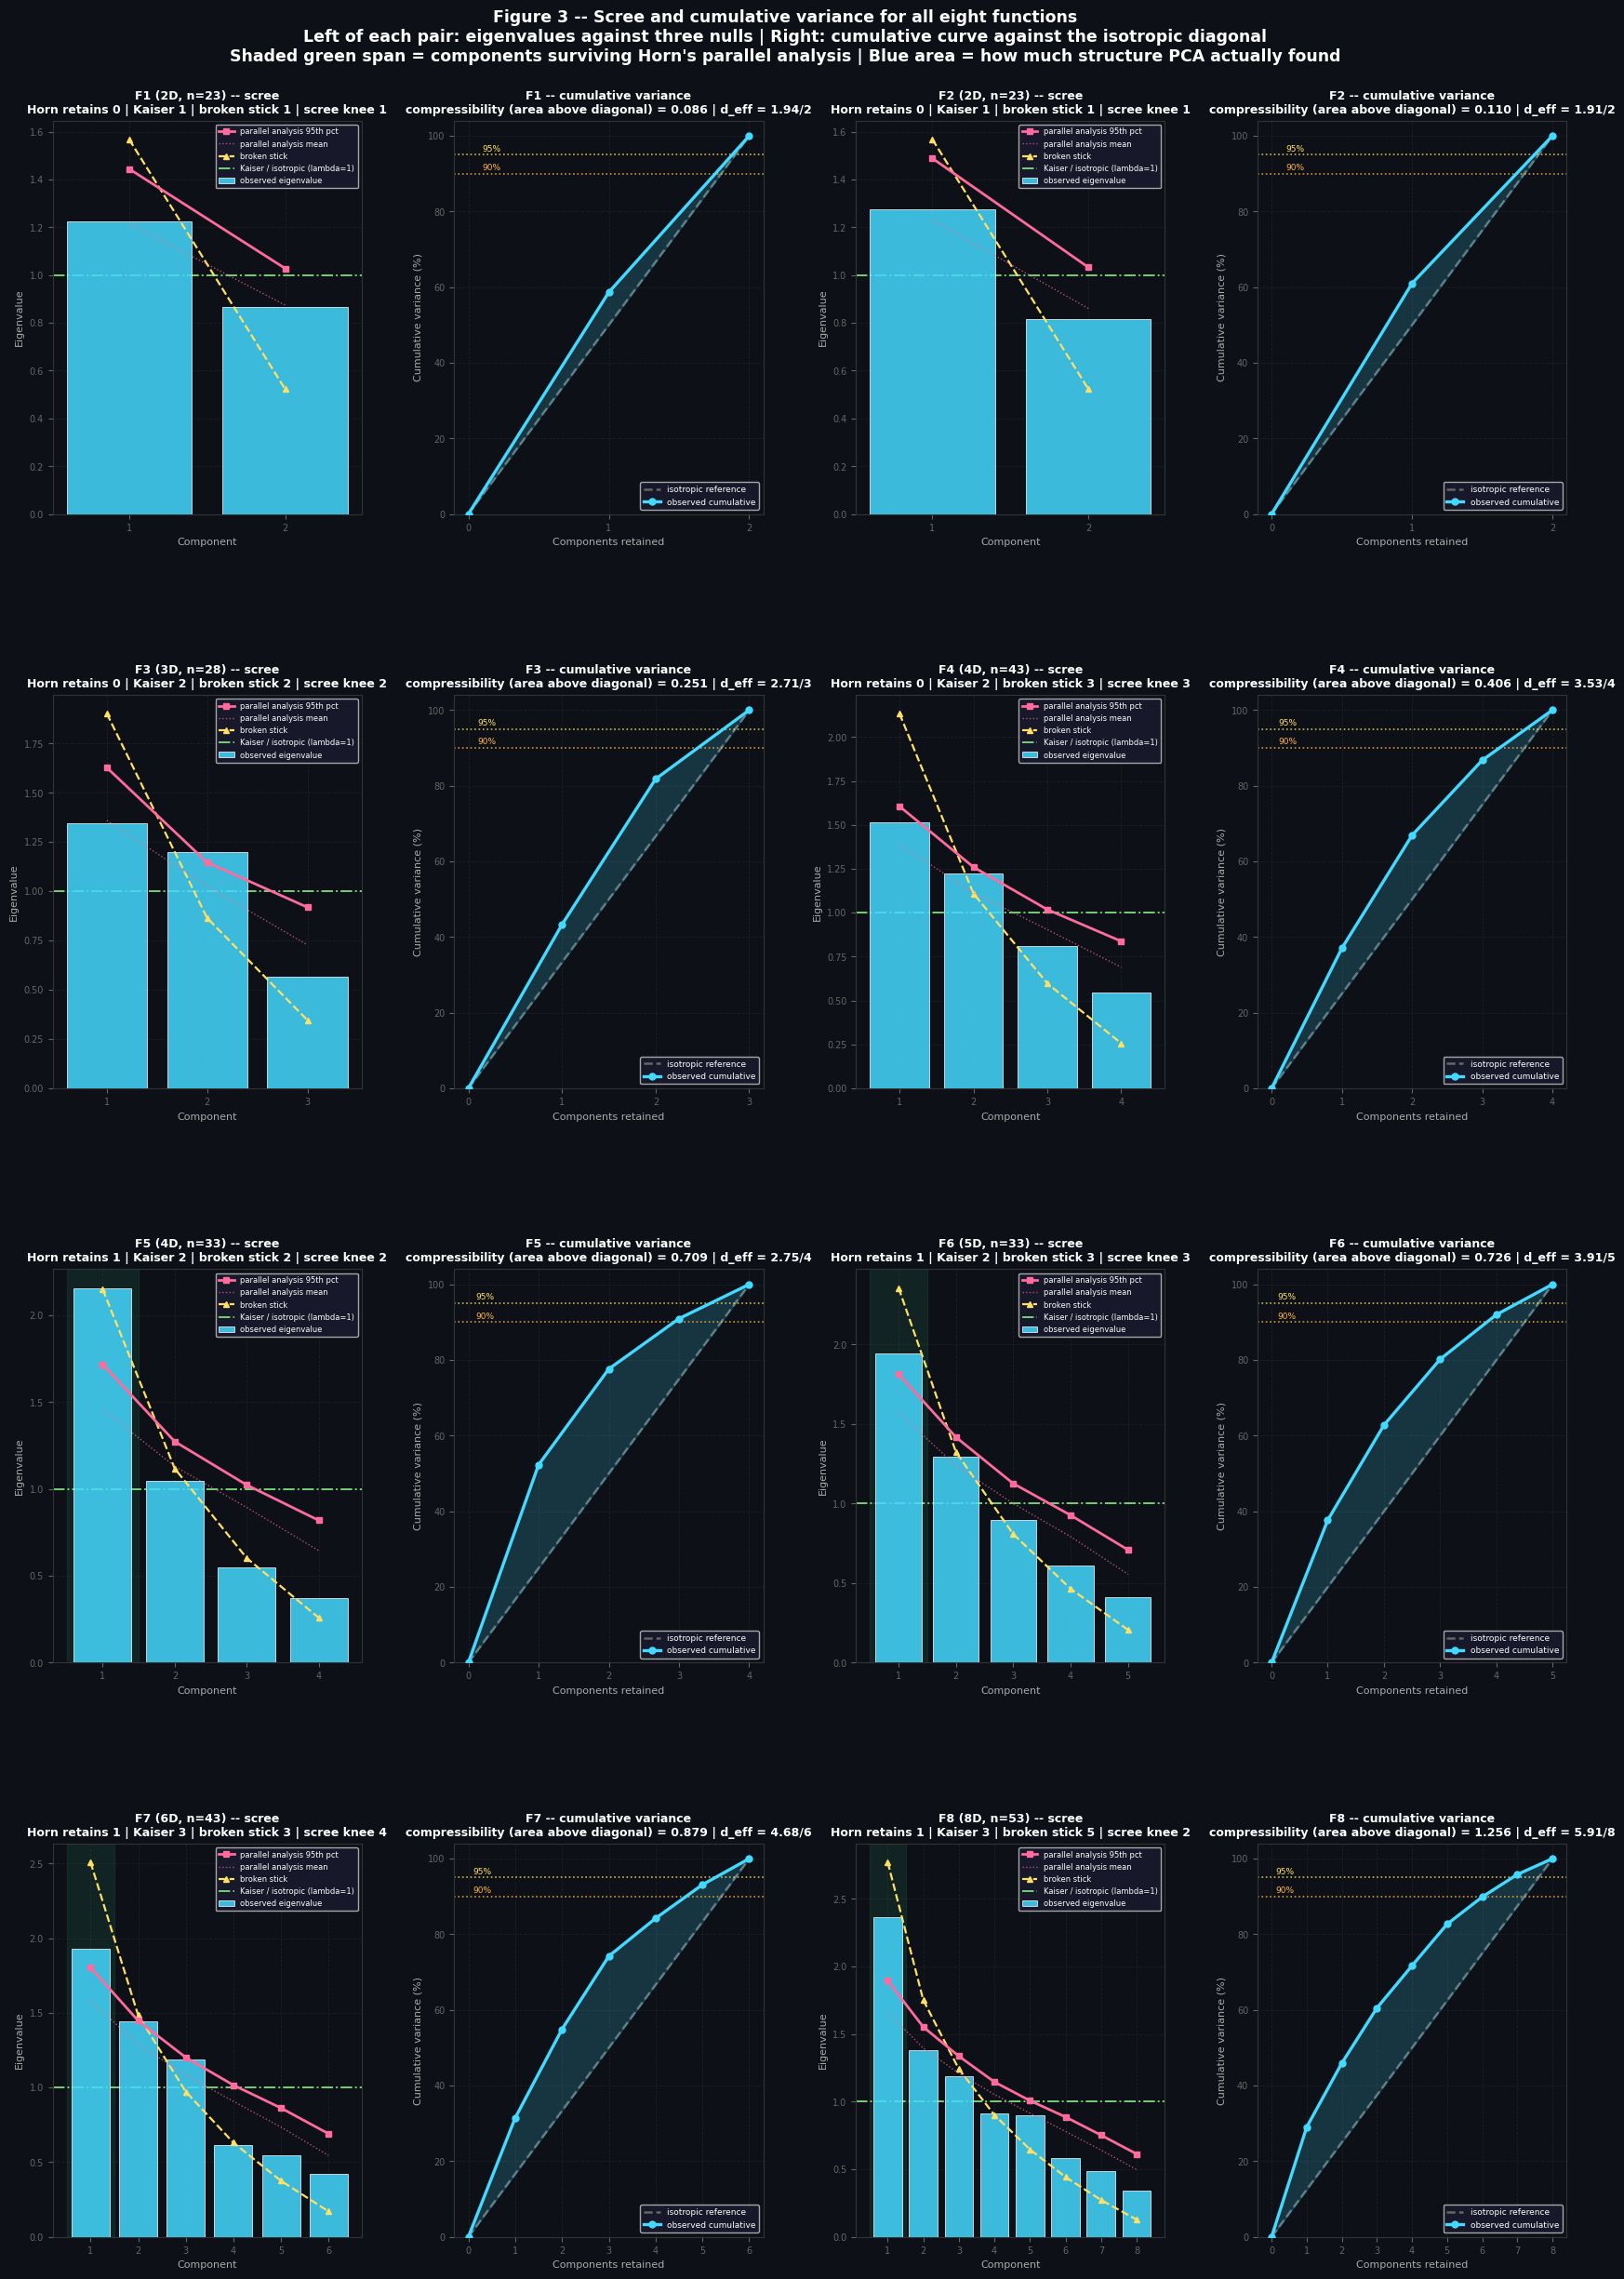

Saved pca_fig3_scree_gallery.png


In [13]:
fig = plt.figure(figsize=(21, 25))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.46, wspace=0.30,
                       top=0.940, bottom=0.030)

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    s   = SPEC[fid]
    dim = DIMS[fid]
    ks  = np.arange(1, dim + 1)

    # -- Scree ---------------------------------------------------------------
    ax = fig.add_subplot(gs[r, c * 2])
    style_ax(ax)
    ax.bar(ks, s['eig'], color='#44d9ff', alpha=0.85, edgecolor='white',
           lw=0.6, zorder=3, label='observed eigenvalue')
    ax.plot(ks, s['pa_p95'], color='#ff6b9d', lw=2, marker='s', ms=5,
            zorder=5, label='parallel analysis 95th pct')
    ax.plot(ks, s['pa_mean'], color='#ff6b9d', lw=1, ls=':', alpha=0.7,
            zorder=5, label='parallel analysis mean')
    ax.plot(ks, s['bs'] * s['eig'].sum(), color='#ffe066', lw=1.6, ls='--',
            marker='^', ms=4, zorder=4, label='broken stick')
    ax.axhline(1.0, color='#8dff8d', lw=1.4, ls='-.', alpha=0.8,
               label='Kaiser / isotropic (lambda=1)')
    k_h = s['k']['horn']
    if k_h:
        ax.axvspan(0.5, k_h + 0.5, color='#44ffaa', alpha=0.08, zorder=1)
    ax.set_title(f"F{fid} ({dim}D, n={len(DATA[fid]['y'])}) -- scree\n"
                 f"Horn retains {k_h} | Kaiser {s['k']['kaiser']} | "
                 f"broken stick {s['k']['bstick']} | scree knee {s['k']['scree']}",
                 color=TC, fontsize=9, fontweight='bold')
    ax.set_xlabel('Component', color=AC, fontsize=8)
    ax.set_ylabel('Eigenvalue', color=AC, fontsize=8)
    ax.set_xticks(ks)
    ax.legend(fontsize=6, facecolor='#1a1a2e', labelcolor='white', loc='upper right')

    # -- Cumulative ----------------------------------------------------------
    ax = fig.add_subplot(gs[r, c * 2 + 1])
    style_ax(ax)
    cum = np.r_[0.0, s['cum']]
    diag = np.linspace(0, 1, dim + 1)
    ax.plot(np.arange(dim + 1), diag * 100, color='#666666', lw=1.8, ls='--',
            label='isotropic reference')
    ax.fill_between(np.arange(dim + 1), diag * 100, cum * 100,
                    color='#44d9ff', alpha=0.18, zorder=2)
    ax.plot(np.arange(dim + 1), cum * 100, color='#44d9ff', lw=2.4,
            marker='o', ms=5, zorder=4, label='observed cumulative')
    ax.axhline(95, color='#ffe066', ls=':', lw=1.2, alpha=0.8)
    ax.axhline(90, color='#ffb347', ls=':', lw=1.2, alpha=0.8)
    ax.text(0.1, 96, '95%', color='#ffe066', fontsize=6.5)
    ax.text(0.1, 91, '90%', color='#ffb347', fontsize=6.5)
    gap = float(np.trapezoid(cum - diag, dx=1.0)) if hasattr(np, 'trapezoid') \
          else float(np.trapz(cum - diag, dx=1.0))
    ax.set_title(f"F{fid} -- cumulative variance\n"
                 f"compressibility (area above diagonal) = {gap:.3f} | "
                 f"d_eff = {s['pr']:.2f}/{dim}",
                 color=TC, fontsize=9, fontweight='bold')
    ax.set_xlabel('Components retained', color=AC, fontsize=8)
    ax.set_ylabel('Cumulative variance (%)', color=AC, fontsize=8)
    ax.set_xticks(np.arange(dim + 1))
    ax.set_ylim(0, 104)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='lower right')

fig.suptitle(
    'Figure 3 -- Scree and cumulative variance for all eight functions\n'
    'Left of each pair: eigenvalues against three nulls | Right: cumulative curve against the isotropic diagonal\n'
    'Shaded green span = components surviving Horn\'s parallel analysis | '
    'Blue area = how much structure PCA actually found',
    color='white', fontsize=12.5, fontweight='bold', y=0.988)

plt.savefig('pca_fig3_scree_gallery.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig3_scree_gallery.png')

---
## Section 6 — Whose anisotropy is it: the function's, or the search's?

This section is specific to Bayesian optimisation and it is the one most likely to earn marks,
because it is a caveat that a generic PCA tutorial cannot raise.

Our observations are **not a random sample of the domain**. Weeks 1 onward are chosen by an
acquisition function that deliberately concentrates queries where the surrogate thinks the optimum
lies. So a spectrum computed on all observations mixes two things:

- the **design's** geometry (the space-filling initial points), and
- the **search's** history (the weekly points, clustered by construction).

Split them and the ambiguity disappears. The initial design is exchangeable and isotropic by
intent, so *its* spectrum is the honest baseline. If the combined spectrum is more concentrated
than the initial-only spectrum, the extra anisotropy is the optimiser's footprint — evidence about
where the GP has been looking, not about the landscape.

Both readings are useful, but they answer different questions and must not be swapped.

### Cell 14 — Initial design vs. initial + weekly, with bootstrap intervals

In [14]:
def boot_eff_dim(X, n_boot=N_BOOT, random_state=RANDOM_STATE):
    """Bootstrap CI for the participation-ratio effective dimension.

    Resampling rows with replacement is the only honest way to attach an interval
    to d_eff at n = 10-52. Degenerate resamples (a zero-variance column) are skipped.
    """
    rng = np.random.default_rng(random_state)
    n = len(X)
    out = []
    for _ in range(n_boot):
        Xb = X[rng.integers(0, n, n)]
        if np.any(Xb.std(axis=0) < 1e-12):
            continue
        Zb = StandardScaler().fit_transform(Xb)
        out.append(eff_dim(fit_pca(Zb)['evr'])[0])
    out = np.array(out)
    return float(np.mean(out)), float(np.percentile(out, 5)), float(np.percentile(out, 95))


print('=' * 116)
print('  DESIGN GEOMETRY vs SEARCH HISTORY -- PCA on initial-only against PCA on everything')
print('=' * 116)

ANISO = {}
rows = []
for fid in FIDS:
    d   = DATA[fid]
    dim = d['dim']

    Zi = StandardScaler().fit_transform(d['X_init'])
    Za = StandardScaler().fit_transform(d['X'])
    Pi, Pa = fit_pca(Zi), fit_pca(Za)
    pri, _ = eff_dim(Pi['evr'])
    pra, _ = eff_dim(Pa['evr'])

    mi, li, ui = boot_eff_dim(d['X_init'])
    ma, la, ua = boot_eff_dim(d['X'])

    k = max(1, dim // 2)
    ang = principal_angle(Pi['loadings'][:k], Pa['loadings'][:k])

    ANISO[fid] = dict(Pi=Pi, Pa=Pa, pri=pri, pra=pra,
                      ci_i=(li, ui), ci_a=(la, ua), angle=ang)
    rows.append({
        'Fn':                f'F{fid}',
        'd':                 dim,
        'n init':            len(d['y_init']),
        'n all':             len(d['y']),
        'PC1% init':         round(Pi['evr'][0] * 100, 1),
        'PC1% all':          round(Pa['evr'][0] * 100, 1),
        'd_eff init':        round(pri, 2),
        'd_eff all':         round(pra, 2),
        'd_eff init 90% CI': f"[{li:.2f}, {ui:.2f}]",
        'd_eff all 90% CI':  f"[{la:.2f}, {ua:.2f}]",
        'delta d_eff':       round(pra - pri, 2),
        'subspace angle':    round(ang, 1),
    })

ANISO_TABLE = pd.DataFrame(rows)
print(ANISO_TABLE.to_string(index=False))

print('\n  Interpretation, function by function:')
for fid in FIDS:
    a = ANISO[fid]
    delta = a['pra'] - a['pri']
    lo_a, hi_a = a['ci_a']
    lo_i, hi_i = a['ci_i']
    overlap = not (hi_a < lo_i or hi_i < lo_a)
    if delta < -0.4 and not overlap:
        msg = ('the weekly points have measurably CONCENTRATED the sample -- '
               'the extra anisotropy is the optimiser\'s footprint, not the landscape')
    elif delta < -0.4:
        msg = ('the sample looks more concentrated, but the bootstrap intervals overlap, '
               'so this is suggestive rather than established')
    elif delta > 0.4:
        msg = ('the weekly points have SPREAD the sample -- the acquisition function has been '
               'exploring, not exploiting')
    else:
        msg = 'the search has not measurably changed the design geometry yet'
    print(f"    F{fid} ({DIMS[fid]}D): d_eff {a['pri']:.2f} -> {a['pra']:.2f} "
          f"({delta:+.2f}) -- {msg}")

print('\n  Subspace angle compares the top-d/2 principal directions of the two samples.')
print('  A large angle means the weekly points did not merely shrink the cloud -- they moved it,')
print('  so the leading directions of "all observations" no longer describe the original design.')

  DESIGN GEOMETRY vs SEARCH HISTORY -- PCA on initial-only against PCA on everything
Fn  d  n init  n all  PC1% init  PC1% all  d_eff init  d_eff all d_eff init 90% CI d_eff all 90% CI  delta d_eff  subspace angle
F1  2      10     23       65.3      58.6        1.83       1.94      [1.31, 2.00]     [1.48, 2.00]         0.11             0.0
F2  2      10     23       79.3      61.0        1.49       1.91      [1.16, 1.90]     [1.62, 2.00]         0.42             0.0
F3  3      15     28       52.3      43.3        2.55       2.71      [1.91, 2.80]     [2.22, 2.82]         0.16            16.2
F4  4      30     43       35.5      37.0        3.59       3.53      [2.91, 3.68]     [2.90, 3.68]        -0.06             3.3
F5  4      20     33       34.0      52.3        3.66       2.75      [2.70, 3.67]     [2.26, 3.13]        -0.91            60.7
F6  5      20     33       35.3      37.7        4.07       3.91      [2.91, 4.16]     [3.06, 4.19]        -0.16            22.5
F7  6      3

Fn  d  n init  n all  PC1% init  PC1% all  d_eff init  d_eff all d_eff init 90% CI d_eff all 90% CI  delta d_eff  subspace angle
F1  2      10     22       65.3      58.5        1.83       1.94      [1.31, 2.00]     [1.46, 2.00]         0.11             0.0
F2  2      10     22       79.3      61.9        1.49       1.89      [1.16, 1.90]     [1.59, 2.00]         0.41             0.0
F3  3      15     27       52.3      43.2        2.55       2.71      [1.78, 2.82]     [2.24, 2.83]         0.17            16.2
F4  4      30     42       35.5      36.9        3.59       3.53      [2.95, 3.70]     [2.93, 3.67]        -0.06             3.2
F5  4      20     32       34.0      52.0        3.66       2.77      [2.78, 3.67]     [2.27, 3.22]        -0.89            58.5
F6  5      20     32       35.3      37.5        4.07       3.93      [2.91, 4.12]     [2.97, 4.12]        -0.14            21.1
F7  6      30     42       28.4      31.0        4.98       4.70      [3.83, 4.90]     [3.76, 4.7

### Cell 15 — Figure 4: the optimiser's footprint on the spectrum

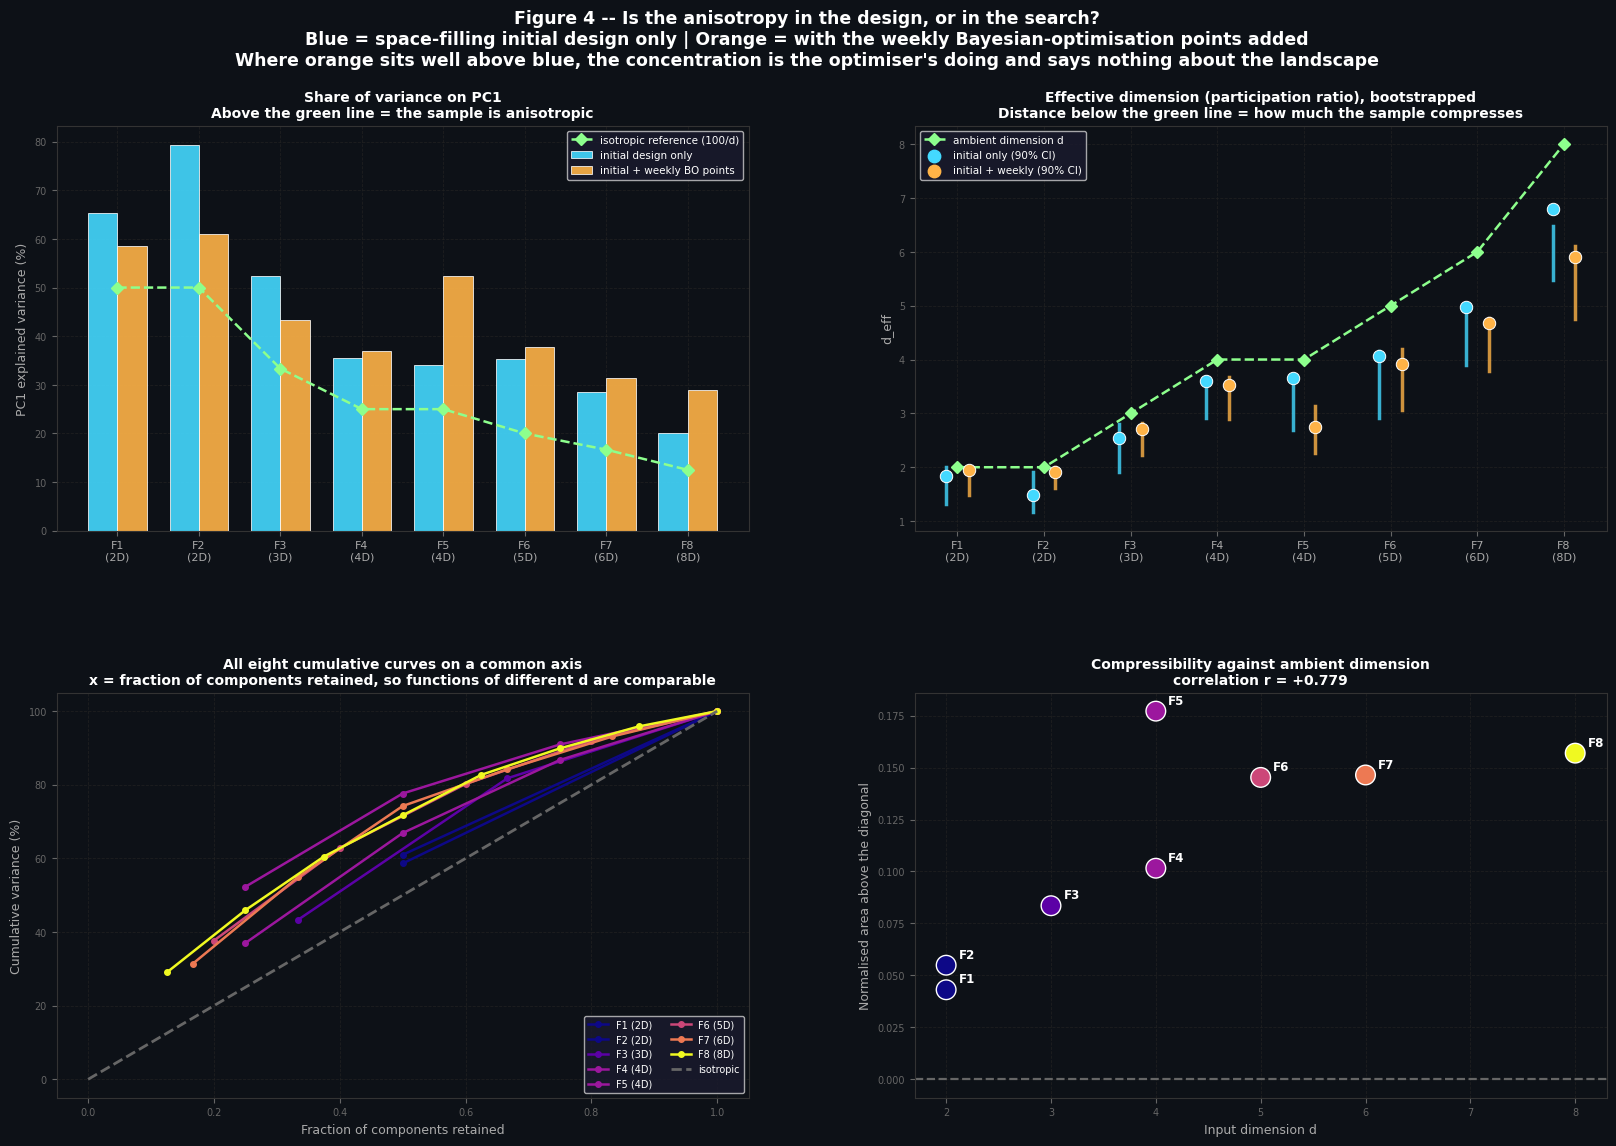

Saved pca_fig4_design_vs_search.png


In [15]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.24,
                       top=0.875, bottom=0.065)

x = np.arange(len(FIDS))
names = [f'F{f}\n({DIMS[f]}D)' for f in FIDS]

# -- Panel 1: PC1 share, initial vs all --------------------------------------
ax = fig.add_subplot(gs[0, 0])
style_ax(ax)
w = 0.36
ax.bar(x - w / 2, [ANISO[f]['Pi']['evr'][0] * 100 for f in FIDS], w,
       label='initial design only', color='#44d9ff', alpha=0.9,
       edgecolor='white', lw=0.6)
ax.bar(x + w / 2, [ANISO[f]['Pa']['evr'][0] * 100 for f in FIDS], w,
       label='initial + weekly BO points', color='#ffb347', alpha=0.9,
       edgecolor='white', lw=0.6)
ax.plot(x, [100.0 / DIMS[f] for f in FIDS], color='#8dff8d', lw=1.8, ls='--',
        marker='D', ms=6, label='isotropic reference (100/d)')
ax.set_xticks(x); ax.set_xticklabels(names, color=AC, fontsize=8)
ax.set_title('Share of variance on PC1\nAbove the green line = the sample is anisotropic',
             color=TC, fontsize=10, fontweight='bold')
ax.set_ylabel('PC1 explained variance (%)', color=AC, fontsize=9)
ax.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white')

# -- Panel 2: effective dimension with bootstrap CIs -------------------------
ax = fig.add_subplot(gs[0, 1])
style_ax(ax)
for i, f in enumerate(FIDS):
    a = ANISO[f]
    ax.plot([i - 0.13, i - 0.13], a['ci_i'], color='#44d9ff', lw=2.5, alpha=0.8)
    ax.plot([i + 0.13, i + 0.13], a['ci_a'], color='#ffb347', lw=2.5, alpha=0.8)
    ax.scatter([i - 0.13], [a['pri']], s=80, color='#44d9ff',
               edgecolor='white', lw=0.7, zorder=5)
    ax.scatter([i + 0.13], [a['pra']], s=80, color='#ffb347',
               edgecolor='white', lw=0.7, zorder=5)
ax.plot(x, [DIMS[f] for f in FIDS], color='#8dff8d', lw=1.8, ls='--',
        marker='D', ms=6, label='ambient dimension d')
ax.scatter([], [], s=80, color='#44d9ff', label='initial only (90% CI)')
ax.scatter([], [], s=80, color='#ffb347', label='initial + weekly (90% CI)')
ax.set_xticks(x); ax.set_xticklabels(names, color=AC, fontsize=8)
ax.set_title('Effective dimension (participation ratio), bootstrapped\n'
             'Distance below the green line = how much the sample compresses',
             color=TC, fontsize=10, fontweight='bold')
ax.set_ylabel('d_eff', color=AC, fontsize=9)
ax.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white', loc='upper left')

# -- Panel 3: full spectra, overlaid, normalised by d ------------------------
ax = fig.add_subplot(gs[1, 0])
style_ax(ax)
for f in FIDS:
    evr = SPEC[f]['evr']
    frac = np.arange(1, len(evr) + 1) / len(evr)
    ax.plot(frac, np.cumsum(evr) * 100, marker='o', ms=4, lw=1.8,
            color=dim_color(DIMS[f]), label=f'F{f} ({DIMS[f]}D)')
ax.plot([0, 1], [0, 100], color='#666666', lw=2, ls='--', label='isotropic')
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_title('All eight cumulative curves on a common axis\n'
             'x = fraction of components retained, so functions of different d are comparable',
             color=TC, fontsize=10, fontweight='bold')
ax.set_xlabel('Fraction of components retained', color=AC, fontsize=9)
ax.set_ylabel('Cumulative variance (%)', color=AC, fontsize=9)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white', ncol=2, loc='lower right')

# -- Panel 4: compressibility vs dimension -----------------------------------
ax = fig.add_subplot(gs[1, 1])
style_ax(ax)
comp = []
for f in FIDS:
    evr = SPEC[f]['evr']; dd = len(evr)
    cum = np.r_[0.0, np.cumsum(evr)]
    diag = np.linspace(0, 1, dd + 1)
    comp.append(float(np.sum(cum - diag)) / dd)
sc = ax.scatter([DIMS[f] for f in FIDS], comp, s=200,
                c=[dim_color(DIMS[f]) for f in FIDS],
                edgecolor='white', lw=1.0, zorder=4)
for f, cv in zip(FIDS, comp):
    ax.annotate(f'F{f}', (DIMS[f], cv), textcoords='offset points',
                xytext=(9, 5), color='white', fontsize=8.5, fontweight='bold')
ax.axhline(0, color='#666666', lw=1.6, ls='--')
if len(set(DIMS.values())) > 2:
    rr = np.corrcoef([DIMS[f] for f in FIDS], comp)[0, 1]
    ax.set_title(f'Compressibility against ambient dimension\n'
                 f'correlation r = {rr:+.3f}',
                 color=TC, fontsize=10, fontweight='bold')
ax.set_xlabel('Input dimension d', color=AC, fontsize=9)
ax.set_ylabel('Normalised area above the diagonal', color=AC, fontsize=9)

fig.suptitle(
    'Figure 4 -- Is the anisotropy in the design, or in the search?\n'
    'Blue = space-filling initial design only | Orange = with the weekly Bayesian-optimisation points added\n'
    'Where orange sits well above blue, the concentration is the optimiser\'s doing and says nothing about the landscape',
    color='white', fontsize=12.5, fontweight='bold', y=0.972)

plt.savefig('pca_fig4_design_vs_search.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig4_design_vs_search.png')

---
## Section 7 — Loadings: which inputs build which component, and can you trust the answer?

A loading vector $\mathbf{w}_k$ says how each original input contributes to component $k$. It is
the only part of a PCA output that is interpretable in the language of the problem — "PC1 is mostly
$x_2$ against $x_5$" is a sentence you can act on, whereas "PC1 explains 31%" is not.

**Two things must be checked before quoting a loading.**

**Sign.** $\mathbf{w}$ and $-\mathbf{w}$ are the same component. Any statement of the form
"PC1 increases with $x_3$" is meaningless until you fix a convention. Ours: make the largest-magnitude
entry positive. Arbitrary, but stated and applied consistently.

**Stability.** The loadings are eigenvectors of a covariance matrix estimated from between 22 and
52 points. Eigenvectors of an almost-flat spectrum are *badly* conditioned: when $\lambda_1 \approx \lambda_2$
the plane they span is well determined but the individual directions inside it are nearly arbitrary,
and they will rotate freely under resampling. Since Section 5 established that our spectra *are*
almost flat, this is the expected case, not an edge case.

So we bootstrap. Resample the rows with replacement, refit, align the sign against the original,
and record the loading. What comes back is an interval per input, and a stability score
$\overline{|\cos\theta|}$ between the bootstrap PC1 and the original PC1:

- $> 0.9$ — the direction is well determined; quote it
- $0.7$–$0.9$ — quote it with the interval attached
- $< 0.7$ — the direction is not identified at this sample size; report the *subspace* instead

### Cell 16 — Loadings, with bootstrap intervals and a stability score

In [16]:
def fix_loading_sign(W):
    """Convention: make the largest-magnitude entry of each component positive."""
    W = np.array(W, float, copy=True)
    for k in range(W.shape[0]):
        j = int(np.argmax(np.abs(W[k])))
        if W[k, j] < 0:
            W[k] = -W[k]
    return W


def bootstrap_loadings(X, k=0, n_boot=N_BOOT, random_state=RANDOM_STATE):
    """Bootstrap the k-th loading vector.

    Returns (loadings_matrix (n_boot x d), stability, ref_vector) where stability
    is the mean |cosine| between each bootstrap replicate and the original vector.
    The absolute value handles the sign ambiguity; align_sign handles the display.
    """
    rng = np.random.default_rng(random_state)
    n   = len(X)
    ref = fix_loading_sign(fit_pca(StandardScaler().fit_transform(X))['loadings'])[k]
    out = []
    for _ in range(n_boot):
        Xb = X[rng.integers(0, n, n)]
        if np.any(Xb.std(axis=0) < 1e-12):
            continue
        Wb = fit_pca(StandardScaler().fit_transform(Xb))['loadings']
        if Wb.shape[0] <= k:
            continue
        out.append(align_sign(Wb[k], ref))
    out = np.array(out)
    cos = np.abs(out @ ref)
    return out, float(np.mean(cos)), ref


print('=' * 116)
print('  PC1 LOADINGS WITH BOOTSTRAP INTERVALS')
print(f'  {N_BOOT} row resamples per function; sign aligned to the original component')
print('=' * 116)

LOADS = {}
for fid in FIDS:
    d   = DATA[fid]
    W   = fix_loading_sign(SPEC[fid]['P']['loadings'])
    boot, stab, ref = bootstrap_loadings(d['X'], k=0)
    lo  = np.percentile(boot, 5, axis=0)
    hi  = np.percentile(boot, 95, axis=0)
    gap = (SPEC[fid]['eig'][0] - SPEC[fid]['eig'][1]) / SPEC[fid]['eig'][0] if DIMS[fid] > 1 else 1.0
    LOADS[fid] = dict(W=W, boot=boot, stab=stab, lo=lo, hi=hi, ref=ref, gap=float(gap))

    verdict = ('well determined'            if stab > 0.90 else
               'usable, quote the interval' if stab > 0.70 else
               'NOT identified at this n')
    crosses = [d['xcols'][j] for j in range(DIMS[fid]) if lo[j] < 0 < hi[j]]

    print(f"\n  F{fid} ({DIMS[fid]}D, n={len(d['y'])}) -- PC1 carries "
          f"{SPEC[fid]['evr'][0]*100:.1f}% | eigen-gap (L1-L2)/L1 = {gap:.2f}")
    print(f"    stability (mean |cos| to bootstrap replicates) = {stab:.3f} -> {verdict}")
    tbl = pd.DataFrame({
        'input':    d['xcols'],
        'PC1':      np.round(ref, 3),
        'boot 5%':  np.round(lo, 3),
        'boot 95%': np.round(hi, 3),
        'sig':      ['' if (l < 0 < h) else 'yes' for l, h in zip(lo, hi)],
    })
    print(tbl.to_string(index=False))
    if crosses:
        print(f"    interval crosses zero for: {', '.join(crosses)} "
              f"-- those inputs' contribution to PC1 is not established")

print('\n' + '-' * 116)
print('  The eigen-gap column explains the stability column. When L1 and L2 are close, the plane')
print('  they span is determined but the individual axes inside it are free to rotate, so PC1 and')
print('  PC2 swap places under resampling. That is a property of the geometry, not a bug.')

  PC1 LOADINGS WITH BOOTSTRAP INTERVALS
  400 row resamples per function; sign aligned to the original component

  F1 (2D, n=23) -- PC1 carries 58.6% | eigen-gap (L1-L2)/L1 = 0.29
    stability (mean |cos| to bootstrap replicates) = 0.723 -> usable, quote the interval
input   PC1  boot 5%  boot 95% sig
   x1 0.707    0.707     0.707 yes
   x2 0.707   -0.707     0.707    
    interval crosses zero for: x2 -- those inputs' contribution to PC1 is not established

  F2 (2D, n=23) -- PC1 carries 61.0% | eigen-gap (L1-L2)/L1 = 0.36
    stability (mean |cos| to bootstrap replicates) = 0.898 -> usable, quote the interval
input   PC1  boot 5%  boot 95% sig
   x1 0.707    0.707     0.707 yes
   x2 0.707   -0.707     0.707    
    interval crosses zero for: x2 -- those inputs' contribution to PC1 is not established

  F3 (3D, n=28) -- PC1 carries 43.3% | eigen-gap (L1-L2)/L1 = 0.11
    stability (mean |cos| to bootstrap replicates) = 0.744 -> usable, quote the interval
input    PC1  boot 5%  boo


  F1 (2D, n=22) -- PC1 carries 58.5% | eigen-gap (L1-L2)/L1 = 0.29
    stability (mean |cos| to bootstrap replicates) = 0.748 -> usable, quote the interval
input   PC1  boot 5%  boot 95% sig
   x1 0.707   -0.707     0.707    
   x2 0.707    0.707     0.707 yes
    interval crosses zero for: x1 -- those inputs' contribution to PC1 is not established

  F2 (2D, n=22) -- PC1 carries 61.9% | eigen-gap (L1-L2)/L1 = 0.38
    stability (mean |cos| to bootstrap replicates) = 0.928 -> well determined
input   PC1  boot 5%  boot 95% sig
   x1 0.707   -0.707     0.707    
   x2 0.707    0.707     0.707 yes
    interval crosses zero for: x1 -- those inputs' contribution to PC1 is not established



  F3 (3D, n=27) -- PC1 carries 43.2% | eigen-gap (L1-L2)/L1 = 0.11
    stability (mean |cos| to bootstrap replicates) = 0.760 -> usable, quote the interval
input    PC1  boot 5%  boot 95% sig
   x1  0.776    0.243     0.743 yes
   x2  0.487   -0.549     0.746    
   x3 -0.401   -0.735     0.599    
    interval crosses zero for: x2, x3 -- those inputs' contribution to PC1 is not established



  F4 (4D, n=42) -- PC1 carries 36.9% | eigen-gap (L1-L2)/L1 = 0.19
    stability (mean |cos| to bootstrap replicates) = 0.785 -> usable, quote the interval
input   PC1  boot 5%  boot 95% sig
   x1 0.666   -0.133     0.716    
   x2 0.524   -0.029     0.665    
   x3 0.270   -0.619     0.681    
   x4 0.458   -0.226     0.664    
    interval crosses zero for: x1, x2, x3, x4 -- those inputs' contribution to PC1 is not established



  F5 (4D, n=32) -- PC1 carries 52.0% | eigen-gap (L1-L2)/L1 = 0.52
    stability (mean |cos| to bootstrap replicates) = 0.973 -> well determined
input    PC1  boot 5%  boot 95% sig
   x1 -0.153   -0.460     0.276    
   x2  0.585    0.505     0.630 yes
   x3  0.541    0.443     0.580 yes
   x4  0.585    0.488     0.627 yes
    interval crosses zero for: x1 -- those inputs' contribution to PC1 is not established



  F6 (5D, n=32) -- PC1 carries 37.5% | eigen-gap (L1-L2)/L1 = 0.33
    stability (mean |cos| to bootstrap replicates) = 0.868 -> usable, quote the interval
input    PC1  boot 5%  boot 95% sig
   x1 -0.249   -0.513     0.304    
   x2  0.378   -0.296     0.593    
   x3 -0.368   -0.633     0.306    
   x4 -0.552   -0.638    -0.227 yes
   x5  0.596    0.194     0.656 yes
    interval crosses zero for: x1, x2, x3 -- those inputs' contribution to PC1 is not established



  F7 (6D, n=42) -- PC1 carries 31.0% | eigen-gap (L1-L2)/L1 = 0.24
    stability (mean |cos| to bootstrap replicates) = 0.808 -> usable, quote the interval
input    PC1  boot 5%  boot 95% sig
   x1  0.502   -0.052     0.611    
   x2  0.432   -0.186     0.580    
   x3 -0.404   -0.577     0.084    
   x4  0.229   -0.411     0.509    
   x5  0.446   -0.217     0.592    
   x6 -0.382   -0.594     0.214    
    interval crosses zero for: x1, x2, x3, x4, x5, x6 -- those inputs' contribution to PC1 is not established



  F8 (8D, n=52) -- PC1 carries 28.2% | eigen-gap (L1-L2)/L1 = 0.40
    stability (mean |cos| to bootstrap replicates) = 0.916 -> well determined
input    PC1  boot 5%  boot 95% sig
   x1  0.463    0.265     0.552 yes
   x2  0.398    0.159     0.509 yes
   x3  0.468    0.257     0.521 yes
   x4  0.343    0.015     0.499 yes
   x5 -0.295   -0.425     0.011    
   x6 -0.184   -0.385     0.085    
   x7  0.365    0.115     0.485 yes
   x8 -0.193   -0.439     0.171    
    interval crosses zero for: x5, x6, x8 -- those inputs' contribution to PC1 is not established

--------------------------------------------------------------------------------------------------------------------
  The eigen-gap column explains the stability column. When L1 and L2 are close, the plane
  they span is determined but the individual axes inside it are free to rotate, so PC1 and
  PC2 swap places under resampling. That is a property of the geometry, not a bug.


### Cell 17 — Sparse PCA: loadings you can put in a sentence

Standard PCA gives every input a non-zero loading, which makes interpretation a matter of squinting
at magnitudes. **Sparse PCA** adds an $\ell_1$ penalty so that most loadings are driven exactly to
zero, at the cost of some explained variance and of strict orthogonality.

For a BBO report this is often the better summary: *"PC1 is $x_2$ and $x_5$"* is checkable and
actionable in a way that *"PC1 is $0.41x_1 - 0.38x_2 + 0.29x_3 \ldots$"* is not. The trade-off is
printed explicitly below — how much variance the sparse version gives up for how many zeros.

In [17]:
print('=' * 108)
print('  SPARSE PCA vs STANDARD PCA -- interpretability against explained variance')
print('=' * 108)

def sparse_explained(Z, W):
    """Variance of Z captured by the (possibly non-orthogonal) sparse components,
    via projection onto an orthonormal basis for their span."""
    Q = np.linalg.qr(np.asarray(W).T)[0]
    return float(np.sum((Z @ Q) ** 2) / np.sum(Z ** 2))


rows = []
for fid in FIDS:
    d   = DATA[fid]
    dim = d['dim']
    k   = max(1, min(2, dim))
    Z   = SPEC[fid]['Z']

    dense_evr = float(SPEC[fid]['cum'][k - 1])
    sp = SparsePCA(n_components=k, alpha=1.0, ridge_alpha=0.01,
                   max_iter=2000, random_state=RANDOM_STATE).fit(Z)
    Ws = sp.components_
    nz = int(np.sum(np.abs(Ws) > 1e-8))
    sparse_evr = sparse_explained(Z, Ws) if nz else 0.0

    Wn = fix_loading_sign(np.array([w / (np.linalg.norm(w) + 1e-12) for w in Ws]))
    active = [', '.join(d['xcols'][j] for j in range(dim) if abs(Wn[c, j]) > 0.15) or '(all shrunk)'
              for c in range(k)]

    rows.append({
        'Fn':               f'F{fid}',
        'd':                dim,
        'k':                k,
        'dense var %':      round(dense_evr * 100, 1),
        'sparse var %':     round(sparse_evr * 100, 1),
        'cost (pts)':       round((dense_evr - sparse_evr) * 100, 1),
        'non-zero loadings': f'{nz}/{k*dim}',
        'PC1 reads as':     active[0],
    })

SPARSE_TABLE = pd.DataFrame(rows)
print(SPARSE_TABLE.to_string(index=False))
print('\n  "PC1 reads as" lists the inputs with |loading| > 0.15 after renormalising.')
print('  Read the cost column before using the sparse version: if it gives up more than a few')
print('  points of explained variance, the sparsity is buying interpretability you have not earned.')

  SPARSE PCA vs STANDARD PCA -- interpretability against explained variance
Fn  d  k  dense var %  sparse var %  cost (pts) non-zero loadings           PC1 reads as
F1  2  2        100.0         100.0         0.0               4/4                 x1, x2
F2  2  2        100.0         100.0         0.0               4/4                 x1, x2
F3  3  2         81.8          79.7         2.1               4/6                 x1, x2
F4  4  2         66.9          66.1         0.8               5/8             x1, x2, x4
F5  4  2         77.6          77.2         0.4               4/8             x2, x3, x4
F6  5  2         62.8          60.8         2.0              7/10             x3, x4, x5
F7  6  2         54.9          53.7         1.2              6/12             x2, x4, x5
F8  8  2         45.9          45.0         0.9             10/16 x1, x2, x3, x4, x5, x7

  "PC1 reads as" lists the inputs with |loading| > 0.15 after renormalising.
  Read the cost column before using the spars

Fn  d  k  dense var %  sparse var %  cost (pts) non-zero loadings           PC1 reads as
F1  2  2        100.0         100.0        -0.0               4/4                 x1, x2
F2  2  2        100.0         100.0         0.0               4/4                 x1, x2
F3  3  2         81.7          79.6         2.2               4/6                 x1, x2
F4  4  2         66.9          66.1         0.8               5/8             x1, x2, x4
F5  4  2         77.0          76.4         0.6               4/8             x2, x3, x4
F6  5  2         62.7          60.8         1.9              7/10             x3, x4, x5
F7  6  2         54.7          53.4         1.2              6/12             x1, x3, x6
F8  8  2         45.3          44.3         1.0             10/16 x1, x2, x3, x4, x5, x7

  "PC1 reads as" lists the inputs with |loading| > 0.15 after renormalising.
  Read the cost column before using the sparse version: if it gives up more than a few
  points of explained variance, th

### Cell 18 — Figure 5: loading heatmaps and PC1 with bootstrap intervals

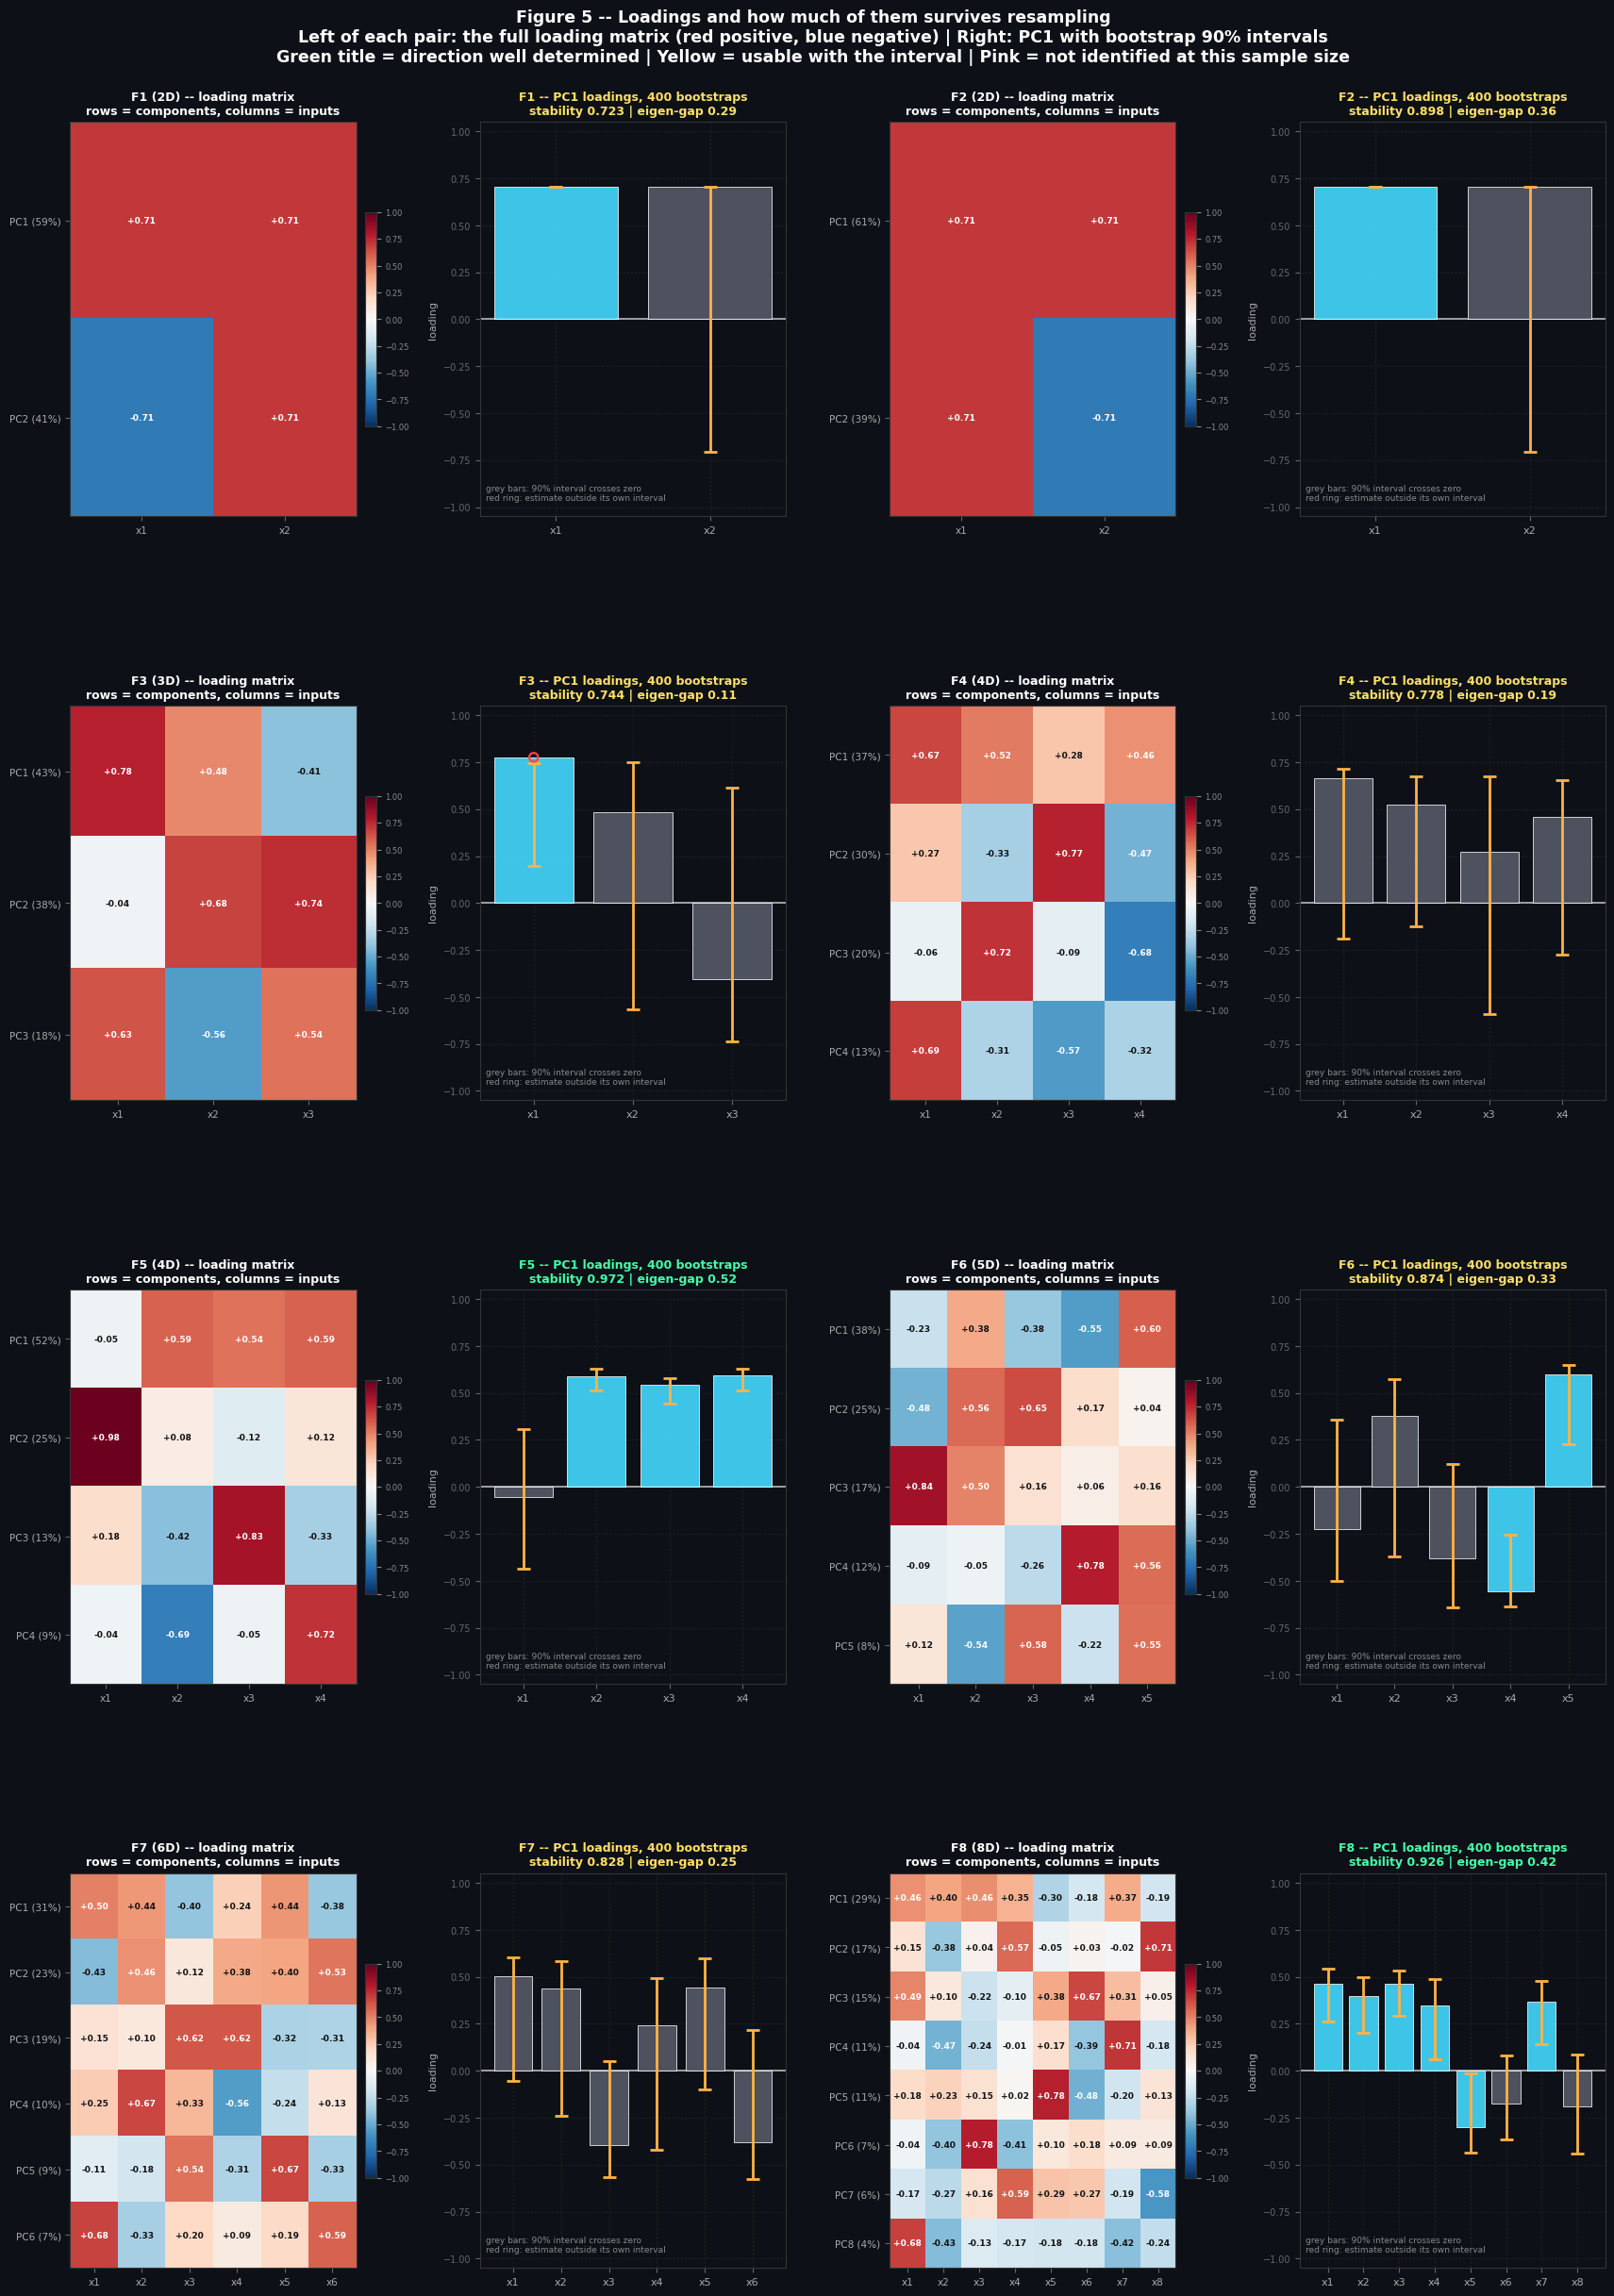

Saved pca_fig5_loadings.png


In [18]:
fig = plt.figure(figsize=(21, 25))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.48, wspace=0.34,
                       top=0.940, bottom=0.030)

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    d   = DATA[fid]
    dim = d['dim']
    L   = LOADS[fid]

    # -- Heatmap of all loadings ---------------------------------------------
    ax = fig.add_subplot(gs[r, c * 2])
    style_ax(ax)
    ax.grid(False)
    W = L['W']
    im = ax.imshow(W, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(dim)); ax.set_xticklabels(d['xcols'], color=AC, fontsize=7.5)
    ax.set_yticks(range(W.shape[0]))
    ax.set_yticklabels([f"PC{k+1} ({SPEC[fid]['evr'][k]*100:.0f}%)"
                        for k in range(W.shape[0])], color=AC, fontsize=7.5)
    for a in range(W.shape[0]):
        for b in range(dim):
            v = W[a, b]
            # RdBu_r is near-white at 0, so light cells need dark text
            ax.text(b, a, f'{v:+.2f}', ha='center', va='center',
                    color=('white' if abs(v) > 0.45 else '#111111'),
                    fontsize=6.5, fontweight='bold')
    cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cb.ax.tick_params(colors='#888888', labelsize=6)
    cb.outline.set_edgecolor('#333333')
    ax.set_title(f"F{fid} ({dim}D) -- loading matrix\n"
                 f"rows = components, columns = inputs",
                 color=TC, fontsize=9, fontweight='bold')

    # -- PC1 loadings with bootstrap CI --------------------------------------
    ax = fig.add_subplot(gs[r, c * 2 + 1])
    style_ax(ax)
    xs = np.arange(dim)
    cols = ['#44d9ff' if not (lo < 0 < hi) else '#555a66'
            for lo, hi in zip(L['lo'], L['hi'])]
    ax.bar(xs, L['ref'], color=cols, alpha=0.9, edgecolor='white', lw=0.6, zorder=3)
    # Drawn as an explicit interval rather than an errorbar: the point estimate is
    # NOT guaranteed to sit inside its own bootstrap percentiles when the replicate
    # distribution is skewed or bimodal, which is exactly what happens when PC1 and
    # PC2 swap under resampling. Hiding that behind a symmetric bar would misreport it.
    ax.vlines(xs, L['lo'], L['hi'], color='#ffb347', lw=2.0, zorder=5)
    ax.scatter(xs, L['lo'], marker='_', s=110, color='#ffb347', lw=2.0, zorder=5)
    ax.scatter(xs, L['hi'], marker='_', s=110, color='#ffb347', lw=2.0, zorder=5)
    outside = [j for j in range(dim) if not (L['lo'][j] <= L['ref'][j] <= L['hi'][j])]
    if outside:
        ax.scatter(xs[outside], L['ref'][outside], marker='o', s=45,
                   facecolor='none', edgecolor='#ff4444', lw=1.6, zorder=6)
    ax.axhline(0, color='white', lw=1.2, alpha=0.7)
    ax.set_xticks(xs); ax.set_xticklabels(d['xcols'], color=AC, fontsize=8)
    ax.set_ylim(-1.05, 1.05)
    stab_col = ('#44ffaa' if L['stab'] > 0.90 else
                '#ffe066' if L['stab'] > 0.70 else '#ff6b9d')
    ax.set_title(f"F{fid} -- PC1 loadings, {N_BOOT} bootstraps\n"
                 f"stability {L['stab']:.3f} | eigen-gap {L['gap']:.2f}",
                 color=stab_col, fontsize=9, fontweight='bold')
    ax.set_ylabel('loading', color=AC, fontsize=8)
    ax.text(0.02, 0.04, 'grey bars: 90% interval crosses zero\n'
                        'red ring: estimate outside its own interval',
            transform=ax.transAxes, color='#888888', fontsize=6.5)

fig.suptitle(
    'Figure 5 -- Loadings and how much of them survives resampling\n'
    'Left of each pair: the full loading matrix (red positive, blue negative) | '
    'Right: PC1 with bootstrap 90% intervals\n'
    'Green title = direction well determined | Yellow = usable with the interval | '
    'Pink = not identified at this sample size',
    color='white', fontsize=12.5, fontweight='bold', y=0.988)

plt.savefig('pca_fig5_loadings.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig5_loadings.png')

---
## Section 8 — Variance is not relevance: PCR against PLS

Everything so far has described $\mathbf{X}$. Now we confront it with $y$, and the central lesson
of the notebook arrives.

**PCA ranks directions by spread. Nothing forces spread and signal to coincide.** The direction
along which your design happens to vary most is under no obligation to be the direction along which
the function varies most. In a designed experiment the two are unrelated by construction: the design
was fixed before anyone knew what the function does.

So the textbook expectation is that $\operatorname{corr}(\text{PC1}, y)$ should be unremarkable.
**Run the next cell and you will find the opposite** — PC1 is strongly and significantly correlated with
$y$ in most of our functions, several above $|r| = 0.75$.

Before celebrating, apply Section 6's lesson. Our sample is not a random sample of the domain: the
acquisition function has been adding points where it expects good outcomes. That stretches the
cloud along the direction *pointing towards the good region* — and the direction of maximum stretch
is, by definition, PC1. **A strong PC1–$y$ correlation is exactly what a successful optimiser
manufactures, whether or not the landscape has any such structure.**

Section 8.2 separates the two explanations with the same split as Section 6:

- Fit PCA on the **initial space-filling design only** and correlate its PC1 with $y$. That sample
  was chosen before any outcome was known, so any association there is a property of the landscape.
- Compare against the same quantity on **all observations**.

If the correlation is present in both, it is real. If it appears only once the weekly points are
included, it is the optimiser's footprint being mistaken for a discovery — a mistake that a
generic PCA tutorial has no way to warn you about, because generic tutorials do not have an
acquisition function editing the dataset between observations.

Then the constructive part:

**8.3.** **Principal Component Regression** projects onto the top $k$ PCs and regresses. Because the
projection ignores $y$, adding a component can leave cross-validated $R^2$ flat or make it worse.
**Partial Least Squares** instead builds components maximising
$\operatorname{Cov}(\mathbf{X}\mathbf{w}, y)$ rather than $\operatorname{Var}(\mathbf{X}\mathbf{w})$
— the supervised sibling of PCA: same machinery, different objective. Because PLS needs $y$ at
*fitting* time, every comparison below is cross-validated with the projection refitted inside each
fold. Judging PLS on in-sample fit would reproduce Section 4.3's circularity in a subtler costume.

### Cell 19 — 8.1 Does the variance ranking match the relevance ranking?

In [19]:
print('=' * 112)
print('  VARIANCE RANK vs RELEVANCE RANK -- each PC score against y')
print(f'  Correlations permutation-tested with {N_PERM} shuffles')
print('=' * 112)

RELEV = {}
rows = []
for fid in FIDS:
    d   = DATA[fid]
    dim = d['dim']
    S   = SPEC[fid]['P']['scores']
    yv  = transform_y(d['y'], Y_MODE[f'F{fid}'])

    rs, ps = [], []
    for k in range(dim):
        r, p = perm_test_corr(S[:, k], yv)
        rs.append(r); ps.append(p)
    rs, ps = np.array(rs), np.array(ps)

    k_best = int(np.argmax(np.abs(rs)))
    RELEV[fid] = dict(r=rs, p=ps, k_best=k_best, scores=S, yv=yv)

    rows.append({
        'Fn':              f'F{fid}',
        'd':               dim,
        'PC1 var %':       round(SPEC[fid]['evr'][0] * 100, 1),
        'corr(PC1, y)':    round(rs[0], 3),
        'p(PC1)':          round(ps[0], 4),
        'best PC for y':   f'PC{k_best+1}',
        'its |corr|':      round(abs(rs[k_best]), 3),
        'its p':           round(ps[k_best], 4),
        'its var %':       round(SPEC[fid]['evr'][k_best] * 100, 1),
        'rank match?':     'yes' if k_best == 0 else 'NO',
    })

RELEV_TABLE = pd.DataFrame(rows)
print(RELEV_TABLE.to_string(index=False))

n_mismatch = int((RELEV_TABLE['rank match?'] == 'NO').sum())
print(f"\n  The most y-relevant component is NOT PC1 in {n_mismatch} of {len(FIDS)} functions.")
if n_mismatch:
    bad = RELEV_TABLE.loc[RELEV_TABLE['rank match?'] == 'NO', 'Fn'].tolist()
    print(f"    -> {', '.join(bad)}")
    print("    For these, truncating at 'the first k components' discards signal while keeping noise.")

print('\n  Components whose association with y survives the permutation test at 5%:')
for fid in FIDS:
    R = RELEV[fid]
    sig = [f"PC{k+1} (r={R['r'][k]:+.3f}, {SPEC[fid]['evr'][k]*100:.0f}% of variance, p={R['p'][k]:.4f})"
           for k in range(DIMS[fid]) if R['p'][k] < 0.05]
    print(f"    F{fid}: " + (', '.join(sig) if sig else
                            'none -- no principal direction is linearly associated with y'))

strong = [f'F{f}' for f in FIDS if abs(RELEV[f]['r'][0]) > 0.6 and RELEV[f]['p'][0] < 0.05]
print(f"\n  PC1 is strongly associated with y (|r| > 0.6, p < 0.05) in: "
      f"{', '.join(strong) if strong else 'none'}")
print('  That looks like a triumph for unsupervised reduction -- PCA found the relevant direction')
print('  without ever being shown y. Do NOT report it that way until the next cell has run.')
print('  Our sample was edited by an acquisition function that adds points where it expects high y,')
print('  which stretches the cloud towards the good region and thereby BUILDS this correlation.')

  VARIANCE RANK vs RELEVANCE RANK -- each PC score against y
  Correlations permutation-tested with 500 shuffles
Fn  d  PC1 var %  corr(PC1, y)  p(PC1) best PC for y  its |corr|  its p  its var % rank match?
F1  2       58.6         0.456  0.0339           PC1       0.456 0.0339       58.6         yes
F2  2       61.0         0.540  0.0060           PC1       0.540 0.0060       61.0         yes
F3  3       43.3        -0.036  0.8663           PC3       0.042 0.8184       18.2          NO
F4  4       37.0        -0.633  0.0020           PC1       0.633 0.0020       37.0         yes
F5  4       52.3         0.932  0.0020           PC1       0.932 0.0020       52.3         yes
F6  5       37.7        -0.799  0.0020           PC1       0.799 0.0020       37.7         yes
F7  6       31.4        -0.681  0.0020           PC1       0.681 0.0020       31.4         yes
F8  8       29.0        -0.913  0.0020           PC1       0.913 0.0020       29.0         yes

  The most y-relevant component

Fn  d  PC1 var %  corr(PC1, y)  p(PC1) best PC for y  its |corr|  its p  its var % rank match?
F1  2       58.5         0.460  0.0220           PC1       0.460 0.0220       58.5         yes
F2  2       61.9         0.565  0.0120           PC1       0.565 0.0120       61.9         yes
F3  3       43.2        -0.049  0.7984           PC3       0.049 0.7984       18.3          NO
F4  4       36.9        -0.635  0.0020           PC1       0.635 0.0020       36.9         yes
F5  4       52.0         0.924  0.0020           PC1       0.924 0.0020       52.0         yes
F6  5       37.5        -0.789  0.0020           PC1       0.789 0.0020       37.5         yes
F7  6       31.0        -0.670  0.0020           PC1       0.670 0.0020       31.0         yes
F8  8       28.2        -0.910  0.0020           PC1       0.910 0.0020       28.2         yes

  The most y-relevant component is NOT PC1 in 1 of 8 functions.
    -> F3
    For these, truncating at 'the first k components' discards signal 

### Cell 20 — 8.2 Is the PC1–$y$ correlation real, or did the optimiser build it?

The test is a straight comparison of like with like. Fit PCA on the **initial design alone** — a
sample drawn with no knowledge of $y$ whatsoever — and correlate its PC1 against those points' own
outcomes. Then do the same on all observations. Both are permutation-tested.

Read the verdict column, not the correlations:

- **genuine** — the association is already present in the unbiased design. PC1 is picking up real
  landscape structure, and an unsupervised projection is defensible for this function.
- **search-induced** — nothing in the initial design, a strong association once the weekly points
  arrive. The correlation is a picture of where the GP has been looking. Reporting it as a property
  of the function would be a serious error.
- **inconclusive** — the initial design is too small to resolve it either way.

One caveat that must travel with this table: the initial designs run from 10 to 40 points, so the
initial-only test is much weaker for F1 and F2 than for F8. A non-significant result at $n=10$ is
not evidence of absence, which is why the sample size is printed next to every verdict.

In [20]:
print('=' * 116)
print('  IS THE PC1-y ASSOCIATION A PROPERTY OF THE LANDSCAPE, OR OF THE SEARCH?')
print('  Left: PCA fitted on the initial space-filling design only (chosen without any knowledge of y)')
print('  Right: PCA fitted on all observations (weekly points chosen BECAUSE of y)')
print('=' * 116)

SOURCE_TEST = {}
rows = []
for fid in FIDS:
    d    = DATA[fid]
    mode = Y_MODE[f'F{fid}']

    Zi = StandardScaler().fit_transform(d['X_init'])
    Si = fit_pca(Zi)['scores'][:, 0]
    ri, pi_ = perm_test_corr(Si, transform_y(d['y_init'], mode))

    Za = StandardScaler().fit_transform(d['X'])
    Sa = fit_pca(Za)['scores'][:, 0]
    ra, pa_ = perm_test_corr(Sa, transform_y(d['y'], mode))

    n_i = len(d['y_init'])
    if pi_ < 0.05 and pa_ < 0.05:
        verdict = 'genuine'
    elif pa_ < 0.05 and pi_ >= 0.05:
        verdict = 'search-induced' if n_i >= 20 else 'inconclusive (small initial n)'
    elif pa_ >= 0.05 and pi_ < 0.05:
        verdict = 'present initially, diluted since'
    else:
        verdict = 'no association either way'

    SOURCE_TEST[fid] = dict(r_init=ri, p_init=pi_, r_all=ra, p_all=pa_,
                            verdict=verdict, n_init=n_i)
    rows.append({
        'Fn':            f'F{fid}',
        'd':             d['dim'],
        'n init':        n_i,
        '|r| initial':   round(abs(ri), 3),
        'p initial':     round(pi_, 4),
        'n all':         len(d['y']),
        '|r| all':       round(abs(ra), 3),
        'p all':         round(pa_, 4),
        'inflation':     round(abs(ra) - abs(ri), 3),
        'verdict':       verdict,
    })

SOURCE_TABLE = pd.DataFrame(rows)
print(SOURCE_TABLE.to_string(index=False))

print('\n  Note: the SIGN of a correlation cannot be compared across the two columns. These are two')
print('  separate PCA fits and each is free to return -w instead of w, so only |r| is meaningful.')
print('  Section 6\'s subspace-angle column is the right place to check whether the two PC1')
print('  directions actually point the same way.')

induced = [f'F{f}' for f in FIDS if SOURCE_TEST[f]['verdict'] == 'search-induced']
genuine = [f'F{f}' for f in FIDS if SOURCE_TEST[f]['verdict'] == 'genuine']
print(f"\n  GENUINE (present before any y was known)   : {', '.join(genuine) if genuine else 'none'}")
print(f"  SEARCH-INDUCED (appears only with BO points): {', '.join(induced) if induced else 'none'}")

if induced:
    print('\n  For the search-induced functions, "PC1 predicts y" is a statement about the optimiser,')
    print('  not the landscape. Concretely: PC1 has aligned itself with the axis running from the')
    print('  initial cloud towards wherever the acquisition function has been concentrating, and')
    print('  points in that direction score better because that is why they were queried.')
    print('  Using such a PC1 to justify a search direction would be circular -- you would be')
    print('  recommending the region you have already chosen to sample.')
    print('\n  Note which functions these are: the higher-dimensional ones, where the initial design')
    print('  is sparsest relative to the space and the weekly points therefore move the covariance')
    print('  matrix most. The trap gets worse exactly where you are most tempted to reduce.')

print('\n  Cross-check against Section 6. The two diagnostics are related but NOT equivalent: the')
print('  subspace angle measures whether the weekly points ROTATED the leading directions, while')
print('  the test above measures whether they manufactured an ASSOCIATION WITH y. A search can do')
print('  the second without much of the first -- it only has to stretch the cloud along a direction')
print('  the design already had.')
for fid in FIDS:
    v   = SOURCE_TEST[fid]['verdict']
    ang = ANISO[fid]['angle']
    if v == 'search-induced' and ang < 20:
        note = '  <- association manufactured with barely any rotation'
    elif v == 'search-induced':
        note = '  <- both diagnostics fire: the sample was moved AND the association appeared'
    elif v == 'genuine' and ang >= 20:
        note = '  <- rotated, but the association predates the search'
    else:
        note = ''
    print(f"    F{fid}: subspace angle {ang:5.1f} deg | "
          f"d_eff {ANISO[fid]['pri']:.2f} -> {ANISO[fid]['pra']:.2f} | {v}{note}")
print('\n  The inflation column is the statistic to quote. A large positive value means the weekly')
print('  points added the association; a negative one means the initial design already had it and')
print('  the extra points have diluted it slightly, which is what a genuine effect looks like.')

  IS THE PC1-y ASSOCIATION A PROPERTY OF THE LANDSCAPE, OR OF THE SEARCH?
  Left: PCA fitted on the initial space-filling design only (chosen without any knowledge of y)
  Right: PCA fitted on all observations (weekly points chosen BECAUSE of y)
Fn  d  n init  |r| initial  p initial  n all  |r| all  p all  inflation                        verdict
F1  2      10        0.602     0.0499     23    0.456 0.0339     -0.147                        genuine
F2  2      10        0.641     0.0559     23    0.540 0.0060     -0.101 inconclusive (small initial n)
F3  3      15        0.428     0.0998     28    0.036 0.8663     -0.391      no association either way
F4  4      30        0.755     0.0020     43    0.633 0.0020     -0.122                        genuine
F5  4      20        0.354     0.1257     33    0.932 0.0020      0.578                 search-induced
F6  5      20        0.534     0.0140     33    0.799 0.0020      0.266                        genuine
F7  6      30        0.233     0.

Fn  d  n init  |r| initial  p initial  n all  |r| all  p all  inflation                        verdict
F1  2      10        0.602     0.0499     22    0.460 0.0220     -0.143                        genuine
F2  2      10        0.641     0.0559     22    0.565 0.0120     -0.076 inconclusive (small initial n)
F3  3      15        0.428     0.1238     27    0.049 0.7984     -0.379      no association either way
F4  4      30        0.755     0.0020     42    0.635 0.0020     -0.120                        genuine
F5  4      20        0.354     0.1058     32    0.924 0.0020      0.570                 search-induced
F6  5      20        0.534     0.0080     32    0.789 0.0020      0.256                        genuine
F7  6      30        0.233     0.1996     42    0.670 0.0020      0.437                 search-induced
F8  8      40        0.070     0.6327     52    0.910 0.0020      0.840                 search-induced

  Note: the SIGN of a correlation cannot be compared across the two colu

### Cell 21 — 8.3 PCR against PLS, cross-validated

Both models are refitted inside every fold — the scaler, the projection, and the regression. A
projection fitted on all the data and then cross-validated is a standard and serious leak, and it
would flatter PCR here just as much as PLS.

The $R^2$ values will be low, and several will be negative. That is not a failure of the code:
negative cross-validated $R^2$ means the model predicts held-out points worse than the training
mean does, which is the honest verdict on fitting a linear model to 22–52 points from a multimodal
black-box function. Report it as such.

In [21]:
print('=' * 108)
print(f'  PCR vs PLS -- {CV_FOLDS}-fold cross-validated R^2 (everything refitted inside each fold)')
print('=' * 108)

CV = {}
rows = []
for fid in FIDS:
    d   = DATA[fid]
    dim = d['dim']
    X   = d['X']
    yv  = transform_y(d['y'], Y_MODE[f'F{fid}'])
    cv  = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    r2_pcr, r2_pls = [], []
    for k in range(1, dim + 1):
        pcr = make_pipeline(StandardScaler(), PCA(n_components=k,
                                                  random_state=RANDOM_STATE),
                            LinearRegression())
        pred = cross_val_predict(pcr, X, yv, cv=cv)
        r2_pcr.append(r2_score(yv, pred))

        pls = make_pipeline(StandardScaler(), PLSRegression(n_components=k, scale=False))
        pred = cross_val_predict(pls, X, yv, cv=cv).ravel()
        r2_pls.append(r2_score(yv, pred))

    r2_pcr, r2_pls = np.array(r2_pcr), np.array(r2_pls)
    # full linear model as the ceiling for any linear method
    lin = make_pipeline(StandardScaler(), LinearRegression())
    r2_full = r2_score(yv, cross_val_predict(lin, X, yv, cv=cv))

    k_pcr = int(np.argmax(r2_pcr)) + 1
    k_pls = int(np.argmax(r2_pls)) + 1
    # Parsimony: how few PLS components reach PCR's BEST score (within a 0.01 tolerance)?
    target = float(r2_pcr.max()) - 0.01
    reach  = np.where(r2_pls >= target)[0]
    k_reach = int(reach[0]) + 1 if len(reach) else np.nan

    CV[fid] = dict(r2_pcr=r2_pcr, r2_pls=r2_pls, r2_full=r2_full,
                   k_pcr=k_pcr, k_pls=k_pls, k_reach=k_reach)

    rows.append({
        'Fn':            f'F{fid}',
        'd':             dim,
        'PCR 1 comp':    round(float(r2_pcr[0]), 3),
        'PLS 1 comp':    round(float(r2_pls[0]), 3),
        'best PCR R2':   round(float(r2_pcr.max()), 3),
        'PCR needs k':   k_pcr,
        'best PLS R2':   round(float(r2_pls.max()), 3),
        'PLS needs k':   k_pls,
        'PLS k to match PCR': ('never' if np.isnan(k_reach) else k_reach),
        'components saved':   ('-' if np.isnan(k_reach) else k_pcr - k_reach),
        'full linear':   round(float(r2_full), 3),
    })

CV_TABLE = pd.DataFrame(rows)
print(CV_TABLE.to_string(index=False))

wins = int((CV_TABLE['PLS 1 comp'] > CV_TABLE['PCR 1 comp']).sum())
print(f'\n  On a SINGLE component, PLS beats PCR in {wins} of {len(FIDS)} functions.')
print('  Same data, same folds, same dimension -- the only difference is that PLS chose its')
print('  direction while looking at y, and PCA chose its direction while looking at spread.')

print('\n  But look at the peak columns: the best PLS R^2 is rarely much above the best PCR R^2.')
print('  That is the honest reading, and it is not a defeat for PLS. Both methods eventually')
print('  span the same space -- keep all d components and PCR, PLS and plain least squares are')
print('  identical by construction. The supervised objective does not raise the CEILING; it')
print('  reaches the ceiling with FEWER components:')
for fid in FIDS:
    kr = CV[fid]['k_reach']
    kp = CV[fid]['k_pcr']
    if np.isnan(kr):
        print(f"    F{fid}: PLS never matched PCR's best within tolerance")
    elif kr < kp:
        print(f"    F{fid}: PCR needed {kp} components to reach its best; PLS got there with {int(kr)}")
    else:
        print(f"    F{fid}: both reach the same level at k={int(kr)} -- no parsimony gain here")
print('\n  Fewer components is not a cosmetic win at n = 22-52: every component you retain is')
print('  another set of parameters estimated from the same few dozen points.')

print('\n  Negative R^2 means "worse than predicting the training mean". Functions where even')
print('  the full linear model is negative are telling you the landscape is not linear at all:')
for fid in FIDS:
    if CV[fid]['r2_full'] < 0:
        print(f"    F{fid}: full linear CV R2 = {CV[fid]['r2_full']:+.3f} "
              f"-> a GP or another nonlinear surrogate is required; no linear projection will help")

  PCR vs PLS -- 5-fold cross-validated R^2 (everything refitted inside each fold)
Fn  d  PCR 1 comp  PLS 1 comp  best PCR R2  PCR needs k  best PLS R2  PLS needs k PLS k to match PCR components saved  full linear
F1  2       0.128       0.090        0.128            1        0.090            1              never                -        0.058
F2  2       0.151       0.247        0.228            2        0.247            1                  1                1        0.228
F3  3      -0.171      -0.292       -0.171            1       -0.292            1              never                -       -0.389
F4  4       0.219       0.181        0.219            1        0.181            1              never                -        0.125
F5  4       0.837       0.871        0.892            3        0.889            2                  2                1        0.888
F6  5       0.409       0.657        0.694            3        0.657            1              never                -        0.600
F

Fn  d  PCR 1 comp  PLS 1 comp  best PCR R2  PCR needs k  best PLS R2  PLS needs k PLS k to match PCR components saved  full linear
F1  2       0.069      -0.041        0.069            1       -0.041            1              never                -       -0.129
F2  2       0.115       0.138        0.131            2        0.138            1                  1                1        0.131
F3  3      -0.172      -0.454       -0.172            1       -0.454            1              never                -       -0.507
F4  4       0.215       0.291        0.324            2        0.291            1              never                -        0.206
F5  4       0.814       0.854        0.878            3        0.875            2                  2                1        0.871
F6  5       0.603       0.694        0.708            3        0.694            1              never                -        0.676
F7  6       0.408       0.406        0.408            3        0.406            1  

### Cell 22 — Figure 6: relevance against variance, and the CV curves

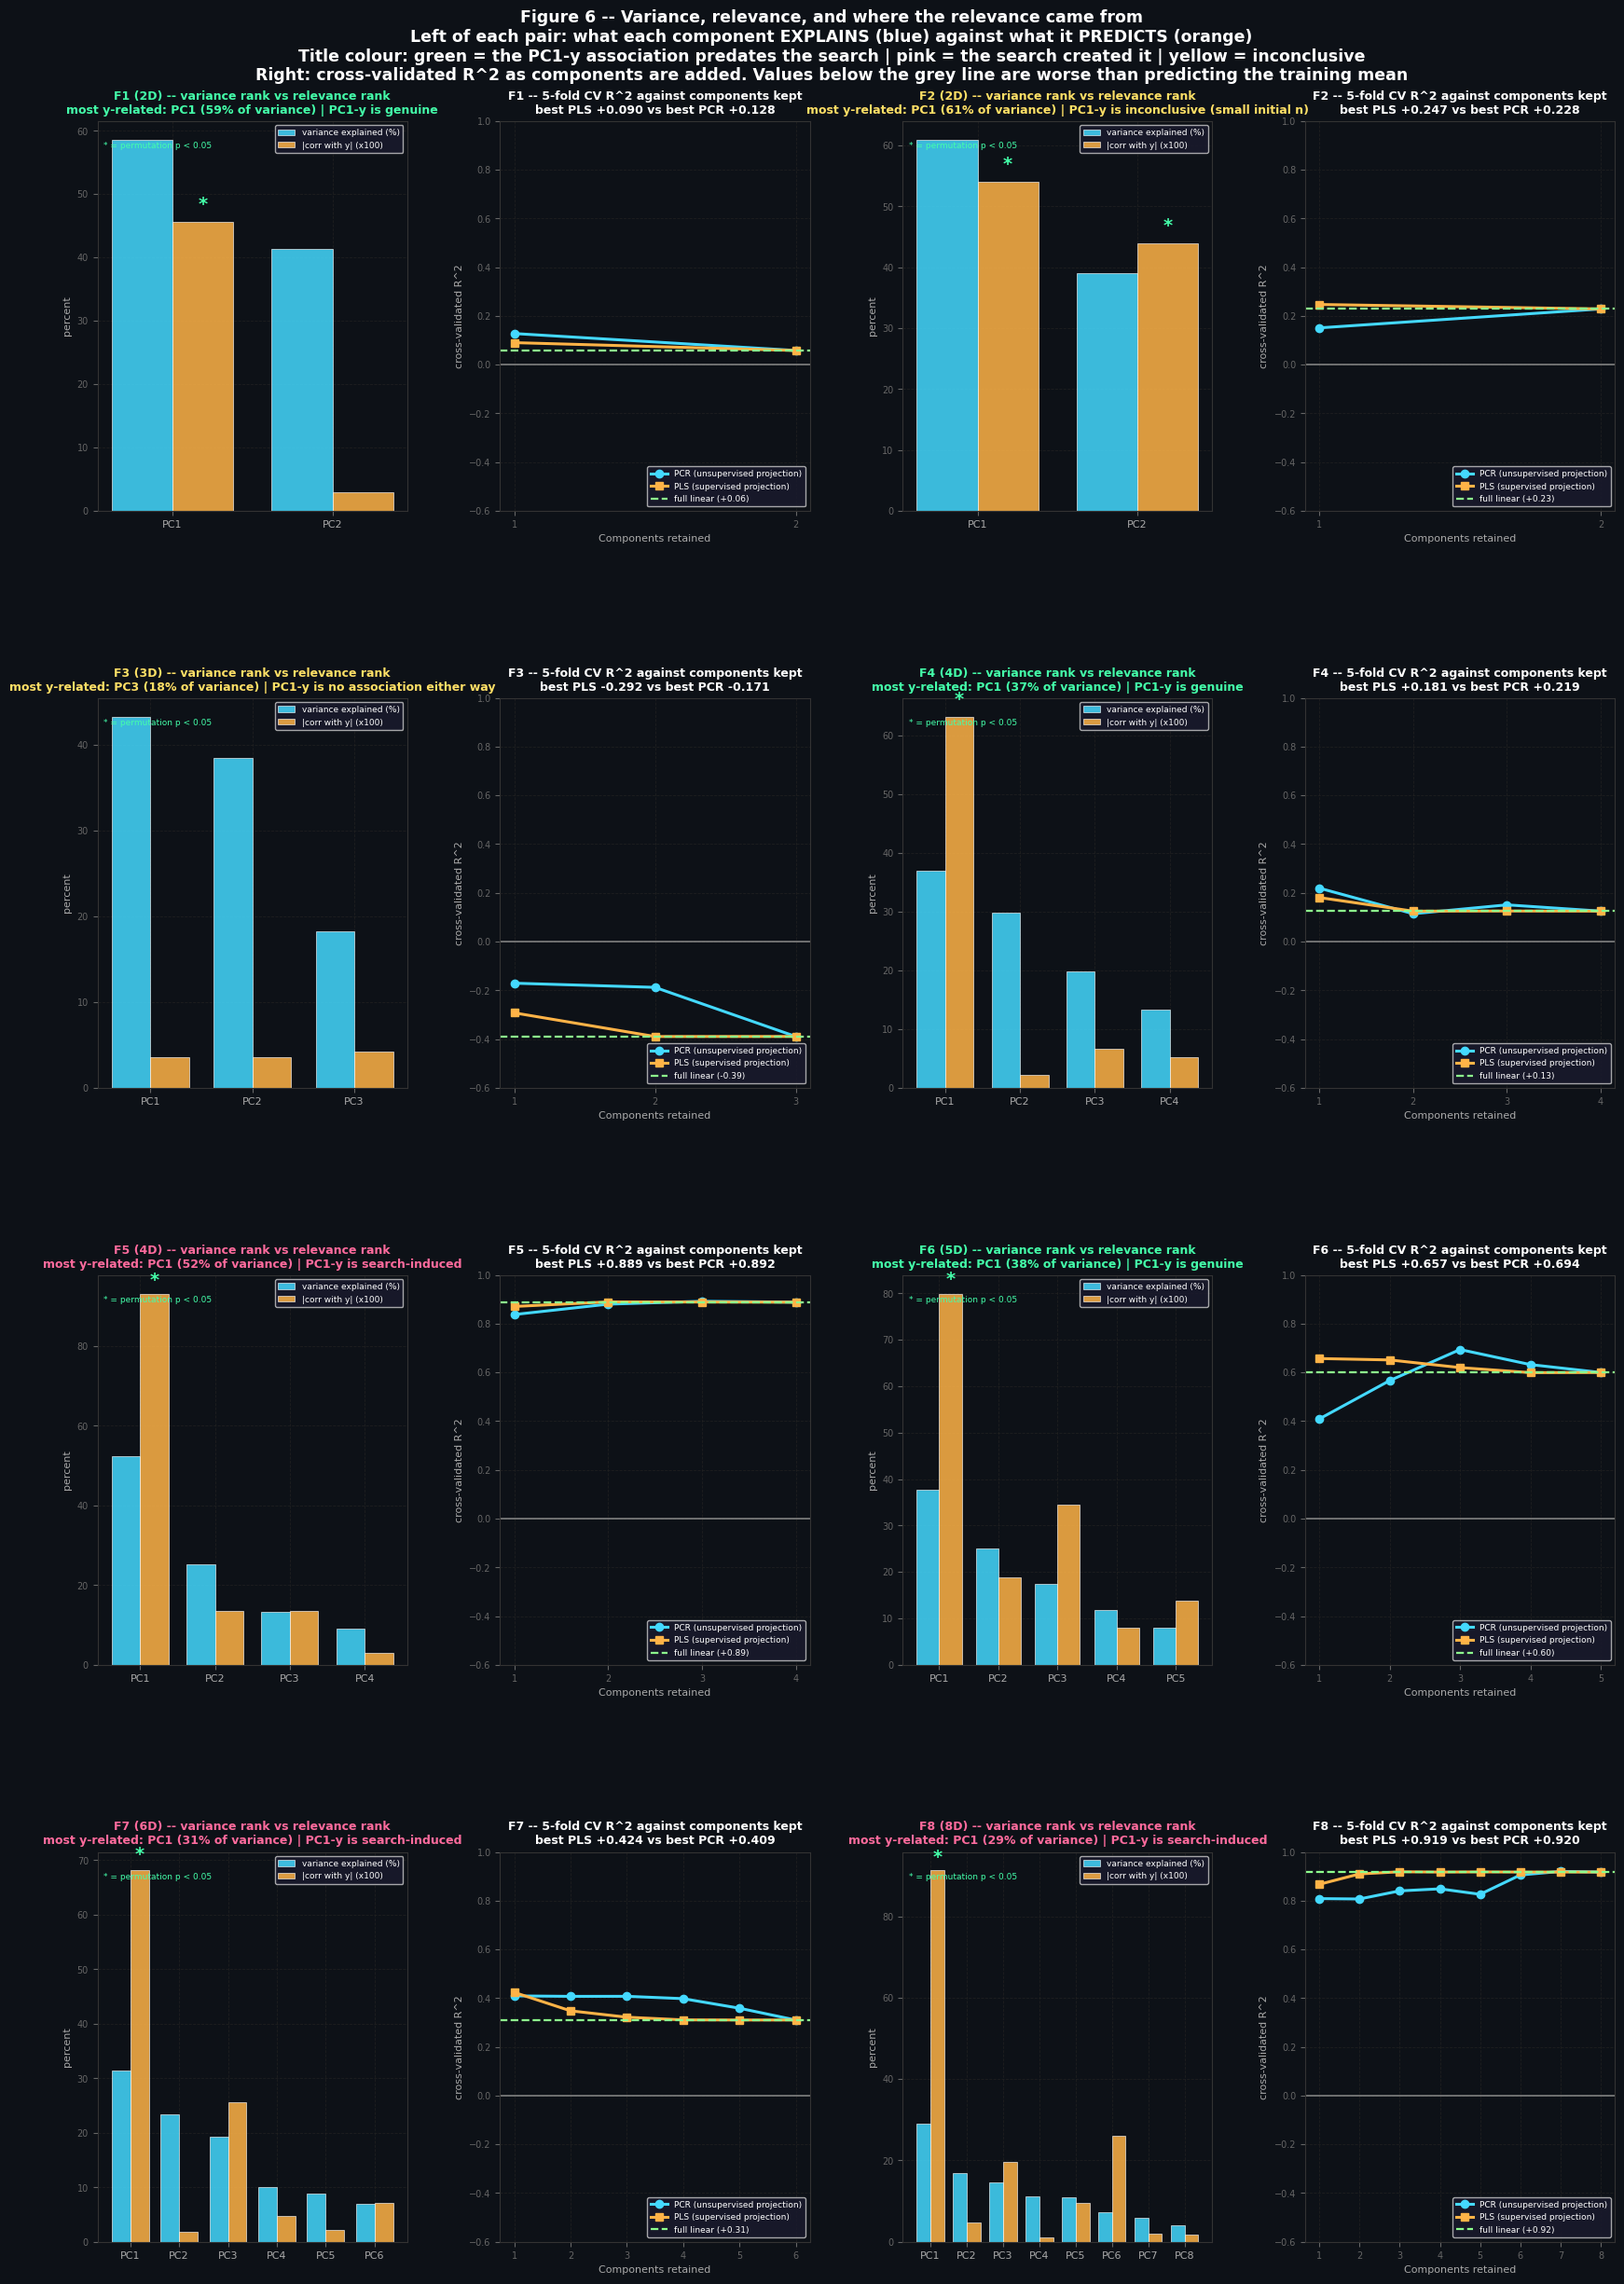

Saved pca_fig6_variance_vs_relevance.png


In [22]:
fig = plt.figure(figsize=(21, 25))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.48, wspace=0.30,
                       top=0.940, bottom=0.030)

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    dim = DIMS[fid]
    R   = RELEV[fid]
    ks  = np.arange(1, dim + 1)

    # -- Panel A: explained variance vs |corr with y| ------------------------
    ax = fig.add_subplot(gs[r, c * 2])
    style_ax(ax)
    ax.bar(ks - 0.19, SPEC[fid]['evr'] * 100, 0.38, color='#44d9ff', alpha=0.85,
           edgecolor='white', lw=0.5, label='variance explained (%)')
    ax.bar(ks + 0.19, np.abs(R['r']) * 100, 0.38, color='#ffb347', alpha=0.85,
           edgecolor='white', lw=0.5, label='|corr with y| (x100)')
    for k in range(dim):
        if R['p'][k] < 0.05:
            ax.text(k + 1.19, abs(R['r'][k]) * 100 + 2, '*', color='#44ffaa',
                    fontsize=14, ha='center', fontweight='bold')
    kb = R['k_best']
    ax.set_xticks(ks); ax.set_xticklabels([f'PC{k}' for k in ks], color=AC, fontsize=8)
    verdict = SOURCE_TEST[fid]['verdict']
    vcol = {'genuine': '#44ffaa', 'search-induced': '#ff6b9d'}.get(verdict, '#ffe066')
    ax.set_title(f"F{fid} ({dim}D) -- variance rank vs relevance rank\n"
                 f"most y-related: PC{kb+1} ({SPEC[fid]['evr'][kb]*100:.0f}% of variance) | "
                 f"PC1-y is {verdict}",
                 color=vcol, fontsize=9, fontweight='bold')
    ax.set_ylabel('percent', color=AC, fontsize=8)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='upper right')
    ax.text(0.02, 0.93, '* = permutation p < 0.05', transform=ax.transAxes,
            color='#44ffaa', fontsize=6.5)

    # -- Panel B: CV R^2 curves ----------------------------------------------
    ax = fig.add_subplot(gs[r, c * 2 + 1])
    style_ax(ax)
    ax.plot(ks, CV[fid]['r2_pcr'], marker='o', ms=6, lw=2.2, color='#44d9ff',
            label='PCR (unsupervised projection)')
    ax.plot(ks, CV[fid]['r2_pls'], marker='s', ms=6, lw=2.2, color='#ffb347',
            label='PLS (supervised projection)')
    ax.axhline(CV[fid]['r2_full'], color='#8dff8d', ls='--', lw=1.6,
               label=f"full linear ({CV[fid]['r2_full']:+.2f})")
    ax.axhline(0, color='#888888', lw=1.4, alpha=0.8)
    lo = min(-0.6, float(min(CV[fid]['r2_pcr'].min(), CV[fid]['r2_pls'].min())) - 0.1)
    ax.set_ylim(max(lo, -3.0), 1.0)
    ax.set_xticks(ks)
    ax.set_title(f"F{fid} -- {CV_FOLDS}-fold CV R^2 against components kept\n"
                 f"best PLS {CV[fid]['r2_pls'].max():+.3f} vs best PCR "
                 f"{CV[fid]['r2_pcr'].max():+.3f}",
                 color=TC, fontsize=9, fontweight='bold')
    ax.set_xlabel('Components retained', color=AC, fontsize=8)
    ax.set_ylabel('cross-validated R^2', color=AC, fontsize=8)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='lower right')

fig.suptitle(
    'Figure 6 -- Variance, relevance, and where the relevance came from\n'
    'Left of each pair: what each component EXPLAINS (blue) against what it PREDICTS (orange)\n'
    'Title colour: green = the PC1-y association predates the search | pink = the search created it | yellow = inconclusive\n'
    'Right: cross-validated R^2 as components are added. Values below the grey line are worse than predicting the training mean',
    color='white', fontsize=12.5, fontweight='bold', y=0.988)

plt.savefig('pca_fig6_variance_vs_relevance.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig6_variance_vs_relevance.png')

---
## Section 9 — Active subspaces: the dimension reduction that BBO actually wants

PLS fixed the objective but kept the model linear. **Active subspace analysis** keeps the objective
*and* allows the function to be nonlinear, which makes it the natural high-dimensional diagnostic
for a black-box optimisation problem.

### 9.1 The idea

Instead of the covariance of the *inputs*, build the average outer product of the function's
*gradients* over the domain:

$$
\mathbf{C} \;=\; \mathbb{E}\!\left[\nabla f(\mathbf{x})\, \nabla f(\mathbf{x})^\top\right]
\;=\; \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^\top
$$

The eigenvector $\mathbf{v}_1$ is the direction along which $f$ changes fastest on average, and
$\lambda_k$ measures how much variation direction $k$ contributes. A large gap between $\lambda_1$
and $\lambda_2$ means the function is essentially a **ridge**: it depends on one linear combination
of inputs and is nearly flat in the other $d-1$ directions. An 8D problem with a 2D active subspace
is, for optimisation purposes, a 2D problem.

Compare the two matrices directly:

| | PCA | Active subspace |
|---|---|---|
| Object | $\operatorname{Cov}(\mathbf{x})$ | $\mathbb{E}[\nabla f \nabla f^\top]$ |
| Answers | Where did I sample? | What does the function respond to? |
| Needs $y$ | No | Yes |
| Ridge in a flat design | Invisible | Found immediately |

### 9.2 Where the gradients come from

We cannot differentiate a black box. So we fit a **GP surrogate** with an ARD Matern kernel and
differentiate *that*, by central differences on a Monte-Carlo sample of the box.

This is the honest weak point of the method and it must be stated in the report: **the active
subspace inherits every assumption of the surrogate.** With 22–52 points the GP is smoothing
heavily, so the recovered directions are biased towards whatever the kernel finds easy to
represent. Two guards are applied below:

1. gradients are computed both over a uniform MC sample **and** at the observed points only, and
   the two leading directions are compared by cosine — disagreement means the result is driven by
   extrapolation into unsampled corners;
2. the **ARD length-scales** are reported alongside. A short length-scale on $x_j$ means the GP
   needed to wiggle in that direction, which is an independent read on the same question. When
   $1/\ell_j$ and $|v_{1j}|$ agree, the finding is much more solid.

### Cell 23 — Fit surrogates, estimate the active subspace, cross-check against ARD

In [23]:
def fit_surrogate(fid, y_mode=None, random_state=RANDOM_STATE):
    """GP with an ARD Matern(5/2) kernel plus a white-noise term.

    normalize_y handles the output scale; the y transform handles its SHAPE.
    Both are needed: F5 without a transform makes the length-scale optimiser chase
    a handful of extreme points.
    """
    d   = DATA[fid]
    dim = d['dim']
    yv  = transform_y(d['y'], y_mode or Y_MODE[f'F{fid}'])
    ker = (ConstantKernel(1.0, (1e-3, 1e3))
           * Matern(length_scale=np.ones(dim), length_scale_bounds=(1e-2, 1e2), nu=2.5)
           + WhiteKernel(1e-4, (1e-10, 1e0)))
    gp = GaussianProcessRegressor(kernel=ker, normalize_y=True,
                                  n_restarts_optimizer=3,
                                  random_state=random_state).fit(d['X'], yv)
    return gp


def gradient_matrix(gp, P, h=1e-3):
    """Central-difference gradients of the surrogate at the rows of P."""
    P = np.atleast_2d(P)
    dim = P.shape[1]
    G = np.zeros_like(P)
    for j in range(dim):
        Pp, Pm = P.copy(), P.copy()
        Pp[:, j] = np.clip(Pp[:, j] + h, 0, 1)
        Pm[:, j] = np.clip(Pm[:, j] - h, 0, 1)
        G[:, j] = (gp.predict(Pp) - gp.predict(Pm)) / (Pp[:, j] - Pm[:, j])
    return G


def active_subspace(fid, n_mc=400, random_state=RANDOM_STATE):
    """Eigendecomposition of E[grad f grad f^T], estimated two ways."""
    d   = DATA[fid]
    dim = d['dim']
    gp  = fit_surrogate(fid)
    rng = np.random.default_rng(random_state)

    P_mc = rng.random((n_mc, dim))
    C_mc = gradient_matrix(gp, P_mc).T @ gradient_matrix(gp, P_mc) / n_mc
    w_mc, V_mc = np.linalg.eigh(C_mc)
    o = np.argsort(w_mc)[::-1]; w_mc, V_mc = w_mc[o], V_mc[:, o]

    G_ob = gradient_matrix(gp, d['X'])
    C_ob = G_ob.T @ G_ob / len(G_ob)
    w_ob, V_ob = np.linalg.eigh(C_ob)
    o = np.argsort(w_ob)[::-1]; w_ob, V_ob = w_ob[o], V_ob[:, o]

    ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale).astype(float)
    if ls.size == 1:
        ls = np.repeat(ls, dim)

    agree = float(abs(np.dot(V_mc[:, 0], V_ob[:, 0])))
    return dict(gp=gp, eig=w_mc, V=V_mc, eig_obs=w_ob, V_obs=V_ob,
                agree=agree, length_scale=ls,
                evr=w_mc / (w_mc.sum() + 1e-300))


print('=' * 116)
print('  ACTIVE SUBSPACE -- eigenvalues of E[grad f grad f^T] from a fitted GP surrogate')
print('=' * 116)

ACT = {}
rows = []
for fid in FIDS:
    d   = DATA[fid]
    dim = d['dim']
    A   = active_subspace(fid)
    ACT[fid] = A

    gap  = float(A['eig'][0] / (A['eig'][1] + 1e-300)) if dim > 1 else np.inf
    pr, _ = eff_dim(A['evr'])
    v1   = fix_loading_sign(A['V'][:, 0][None, :])[0]
    inv_ls = 1.0 / A['length_scale']
    inv_ls = inv_ls / inv_ls.sum()
    rho = float(np.corrcoef(np.abs(v1), inv_ls)[0, 1]) if dim > 2 else np.nan

    rows.append({
        'Fn':                f'F{fid}',
        'd':                 dim,
        'AS lam1 %':         round(A['evr'][0] * 100, 1),
        'AS lam1/lam2':      round(gap, 1) if np.isfinite(gap) else 'inf',
        'AS d_eff':          round(pr, 2),
        'PCA d_eff':         round(SPEC[fid]['pr'], 2),
        'MC vs obs |cos|':   round(A['agree'], 3),
        'ARD agreement r':   ('n/a' if np.isnan(rho) else round(rho, 2)),
        'dominant input':    d['xcols'][int(np.argmax(np.abs(v1)))],
    })

ACT_TABLE = pd.DataFrame(rows)
print(ACT_TABLE.to_string(index=False))

print('\n  Reading the columns:')
print('    AS lam1 %       share of the function\'s average squared gradient on ONE direction.')
print('                    Above ~60% means the surrogate sees a ridge, and the problem is')
print('                    effectively lower-dimensional than d for optimisation purposes.')
print('    AS d_eff        the same effective-dimension statistic as PCA, but computed on the')
print('                    gradient covariance. Compare it with the PCA column beside it: they')
print('                    answer different questions and there is no reason for them to match.')
print('    MC vs obs |cos| robustness. Below ~0.9 means the leading direction depends on where')
print('                    you evaluate the gradients, i.e. on GP extrapolation. Treat with care.')
print('    ARD agreement   correlation between |v1| and the normalised inverse length-scales.')
print('                    Two independent readings of "which inputs matter"; agreement is')
print('                    corroboration, disagreement is a warning.')

print('\n  Per-function active direction (sign convention: largest entry positive):')
for fid in FIDS:
    d  = DATA[fid]
    v1 = fix_loading_sign(ACT[fid]['V'][:, 0][None, :])[0]
    terms = ' '.join(f"{v:+.2f}*{c}" for v, c in zip(v1, d['xcols']))
    print(f"    F{fid}: v1 = {terms}")
    print(f"          ARD length-scales: " +
          '  '.join(f'{c}={l:.2f}' for c, l in zip(d['xcols'], ACT[fid]['length_scale'])))
    off = [c for c, l in zip(d['xcols'], ACT[fid]['length_scale']) if l > 10]
    if off:
        print(f"          !! the surrogate has effectively SWITCHED OFF {', '.join(off)} "
              f"(length-scale > 10 across a [0,1] range)")

print('\n  A warning the robustness column cannot give you.')
print('  When ARD drives a length-scale to the top of its bound, the GP has concluded that the')
print('  input does not matter -- and every gradient it produces will then be flat in that')
print('  direction, so the active subspace inherits the conclusion rather than testing it.')
print('  With 22-52 points that decision is often made on very little evidence. Check the flagged')
print('  inputs above against A2\'s coefficients and A4\'s cluster profiles before believing them:')
print('  a high MC-vs-obs cosine says the answer is STABLE, not that it is CORRECT.')

  ACTIVE SUBSPACE -- eigenvalues of E[grad f grad f^T] from a fitted GP surrogate
Fn  d  AS lam1 %  AS lam1/lam2  AS d_eff  PCA d_eff  MC vs obs |cos| ARD agreement r dominant input
F1  2       79.8           3.9      1.48       1.94            0.754             n/a             x2
F2  2      100.0       64026.6      1.00       1.91            1.000             n/a             x1
F3  3       69.2           2.3      1.74       2.71            0.999            0.87             x3
F4  4       40.5           1.7      3.49       3.53            0.976           -0.45             x2
F5  4       83.9          10.0      1.40       2.75            0.996            0.96             x4
F6  5       46.9           1.9      3.01       3.91            0.866            0.72             x2
F7  6       61.9           2.6      2.21       4.68            0.042            0.88             x5
F8  8       76.7           5.6      1.64       5.91            0.996            0.94             x3

  Reading the col

Fn  d  AS lam1 %  AS lam1/lam2  AS d_eff  PCA d_eff  MC vs obs |cos| ARD agreement r dominant input
F1  2       81.0           4.3      1.45       1.94            0.759             n/a             x2
F2  2      100.0      493467.0      1.00       1.89            1.000             n/a             x1
F3  3       70.6           2.4      1.71       2.71            0.997            0.88             x3
F4  4       40.7           1.8      3.48       3.53            0.976           -0.47             x2
F5  4       83.0           9.1      1.43       2.77            0.996            0.96             x4
F6  5       47.2           1.9      3.00       3.93            0.863            0.72             x2
F7  6       62.1           2.6      2.21       4.70            0.079            0.88             x5
F8  8       76.7           5.6      1.64       6.01            0.996            0.94             x3

  Reading the columns:
    AS lam1 %       share of the function's average squared gradient on ONE 

### Cell 24 — Figure 7: sufficient summary plots

The **sufficient summary plot** is the diagnostic that makes or breaks an active subspace. Plot
$y$ against the single active variable $\mathbf{v}_1^\top\mathbf{x}$. If the points collapse onto a
recognisable curve, then that one linear combination genuinely summarises the function and a $d$-dimensional
search can be steered along a single direction. If they form a shapeless cloud, one direction is
not enough — read the eigenvalue panel to see how many are.

Each function gets two panels: the summary plot on the left, and the active-subspace spectrum
against the PCA spectrum on the right. **Where the two spectra disagree is exactly where PCA would
have misled you.**

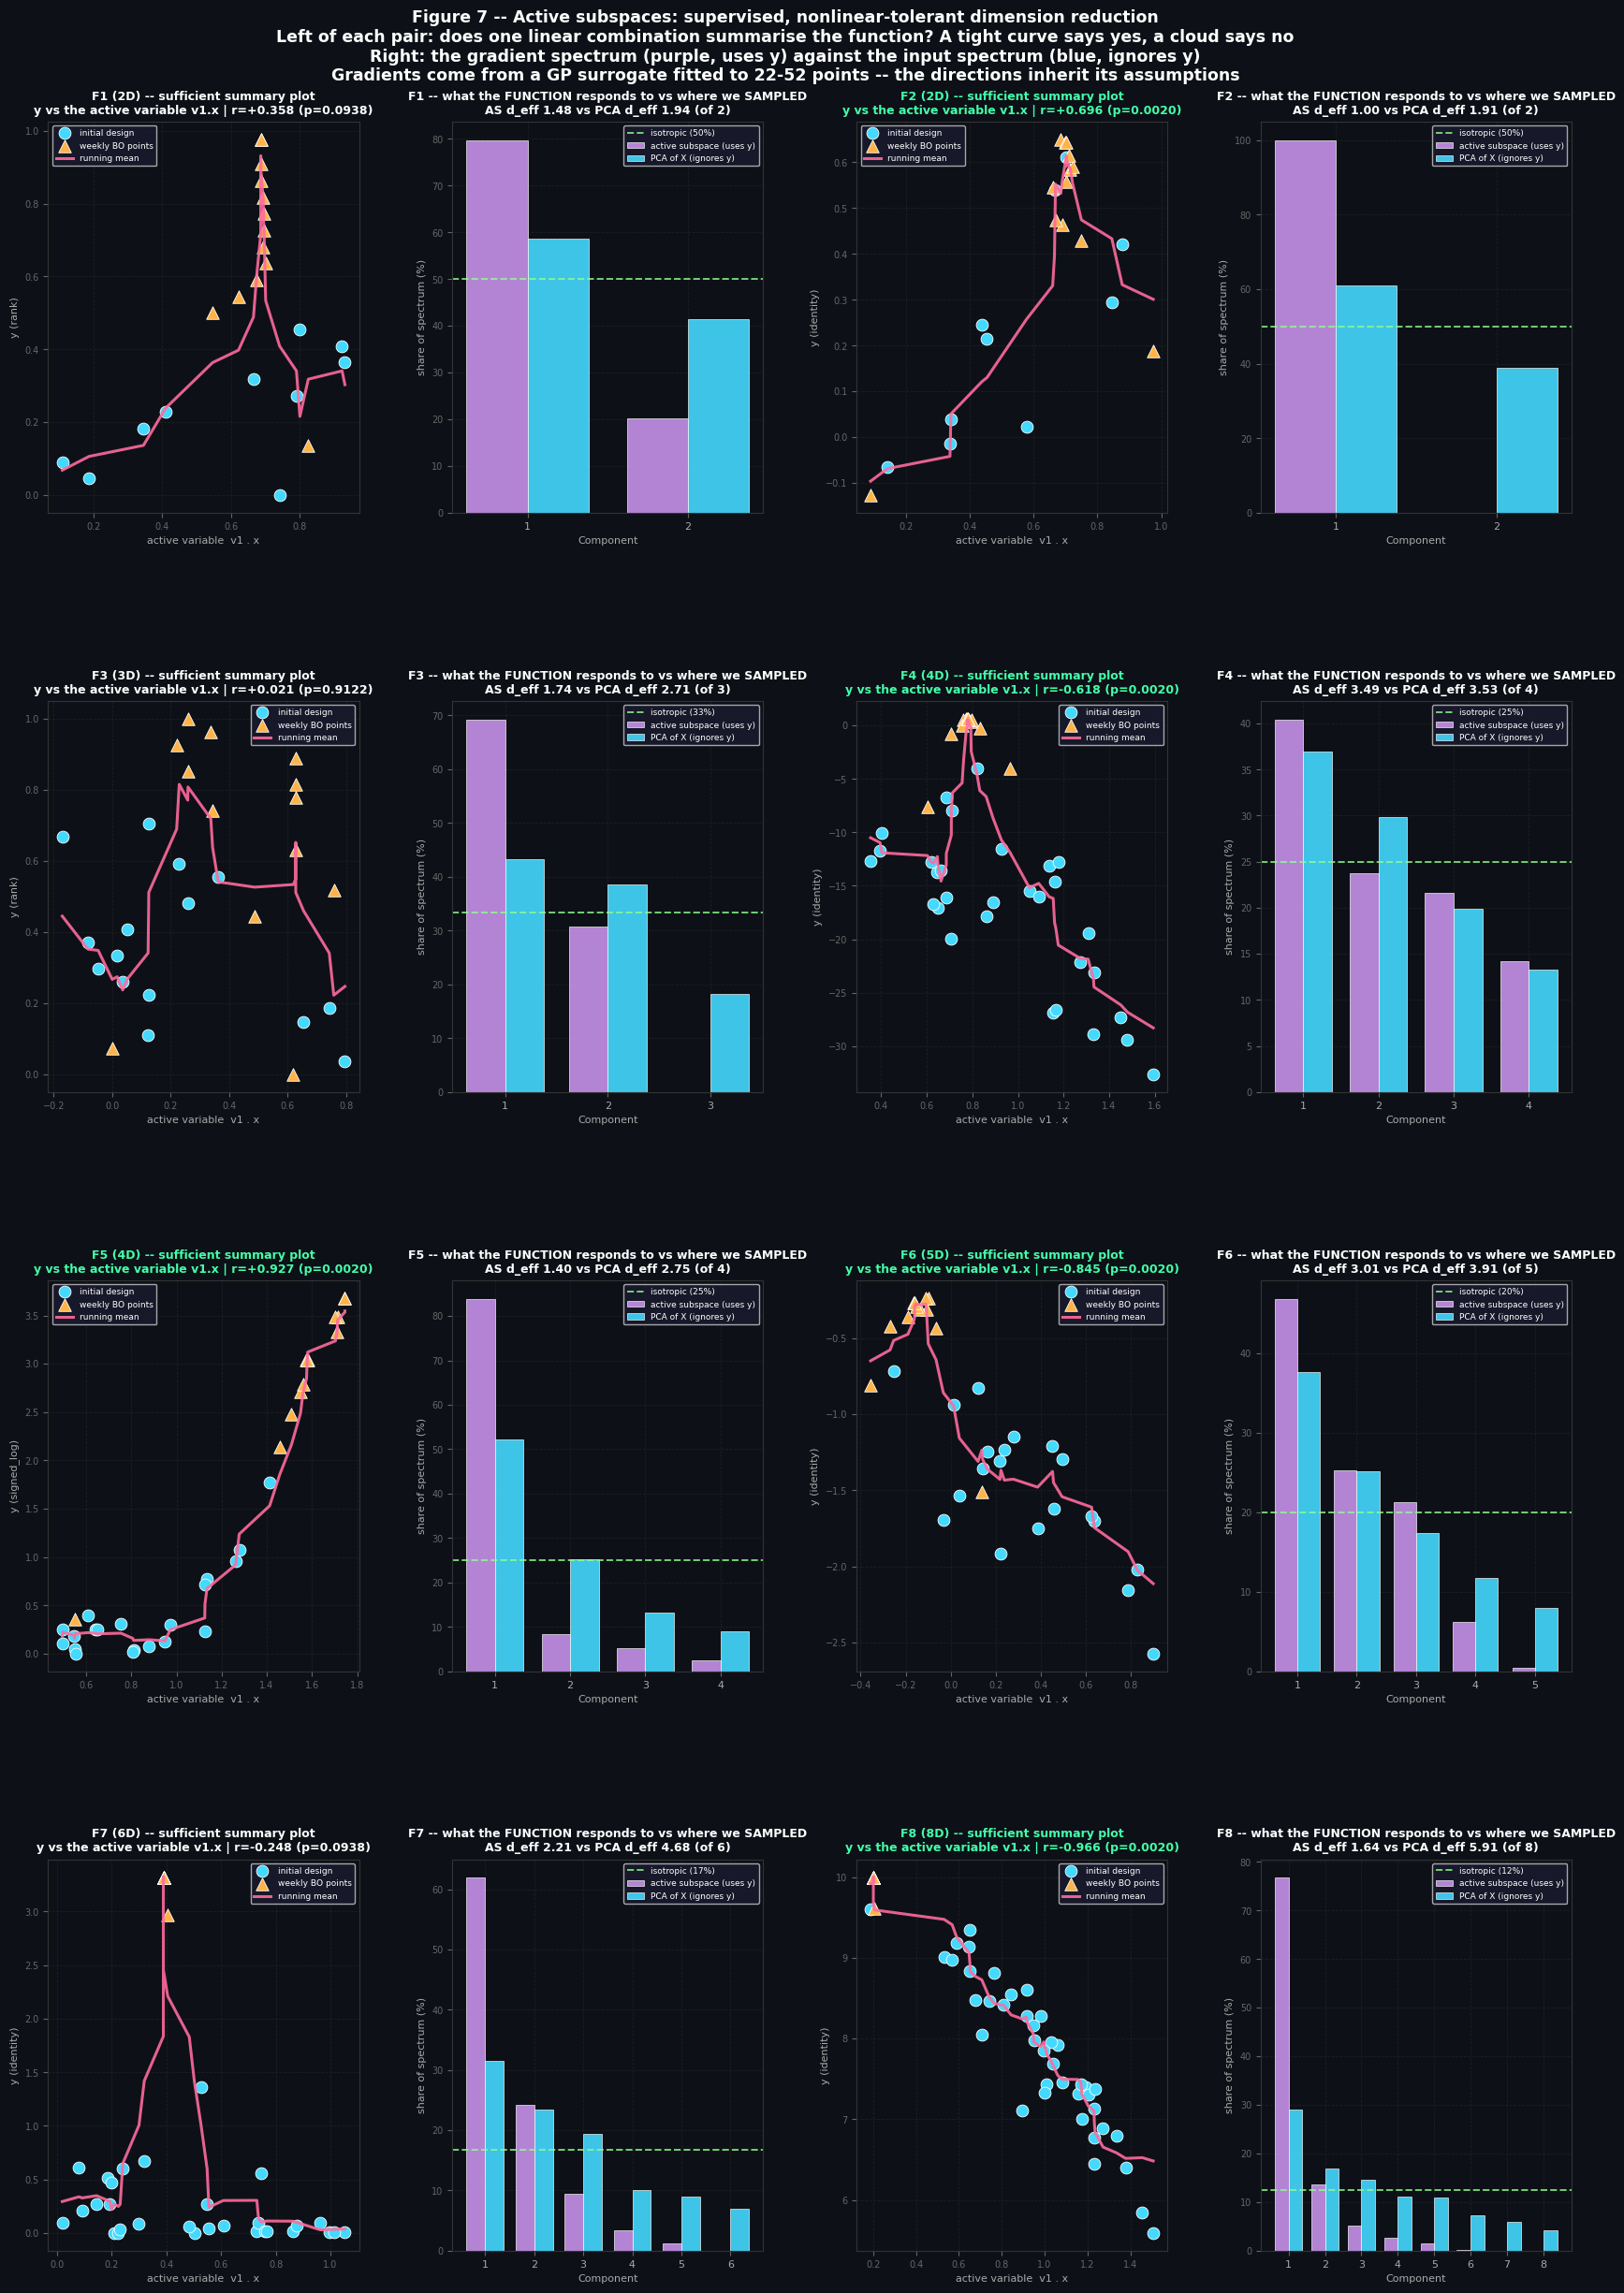

Saved pca_fig7_active_subspace.png


In [24]:
fig = plt.figure(figsize=(21, 25))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.48, wspace=0.30,
                       top=0.940, bottom=0.030)

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    d   = DATA[fid]
    dim = d['dim']
    A   = ACT[fid]
    yv  = transform_y(d['y'], Y_MODE[f'F{fid}'])
    v1  = fix_loading_sign(A['V'][:, 0][None, :])[0]
    u   = d['X'] @ v1

    # -- Panel A: sufficient summary plot ------------------------------------
    ax = fig.add_subplot(gs[r, c * 2])
    style_ax(ax)
    is_week = np.r_[np.zeros(len(d['y_init']), bool), np.ones(len(d['y_week']), bool)]
    ax.scatter(u[~is_week], yv[~is_week], s=85, color='#44d9ff',
               edgecolor='white', lw=0.6, label='initial design', zorder=3)
    ax.scatter(u[is_week], yv[is_week], s=95, marker='^', color='#ffb347',
               edgecolor='white', lw=0.6, label='weekly BO points', zorder=4)
    if len(u) > 4:
        o = np.argsort(u)
        wnd = max(3, len(u) // 5)
        sm = pd.Series(yv[o]).rolling(wnd, center=True, min_periods=1).mean().to_numpy()
        ax.plot(u[o], sm, color='#ff6b9d', lw=2.2, alpha=0.9, zorder=5,
                label='running mean')
    rr, pp = perm_test_corr(u, yv)
    ax.set_title(f"F{fid} ({dim}D) -- sufficient summary plot\n"
                 f"y vs the active variable v1.x | r={rr:+.3f} (p={pp:.4f})",
                 color=('#44ffaa' if pp < 0.05 else TC), fontsize=9, fontweight='bold')
    ax.set_xlabel('active variable  v1 . x', color=AC, fontsize=8)
    ax.set_ylabel(f"y ({Y_MODE[f'F{fid}']})", color=AC, fontsize=8)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='best')

    # -- Panel B: AS spectrum vs PCA spectrum --------------------------------
    ax = fig.add_subplot(gs[r, c * 2 + 1])
    style_ax(ax)
    ks = np.arange(1, dim + 1)
    ax.bar(ks - 0.19, A['evr'] * 100, 0.38, color='#c792ea', alpha=0.9,
           edgecolor='white', lw=0.5, label='active subspace (uses y)')
    ax.bar(ks + 0.19, SPEC[fid]['evr'] * 100, 0.38, color='#44d9ff', alpha=0.9,
           edgecolor='white', lw=0.5, label='PCA of X (ignores y)')
    ax.axhline(100.0 / dim, color='#8dff8d', ls='--', lw=1.4, alpha=0.8,
               label=f'isotropic ({100.0/dim:.0f}%)')
    pr, _ = eff_dim(A['evr'])
    ax.set_xticks(ks); ax.set_xticklabels([f'{k}' for k in ks], color=AC, fontsize=8)
    ax.set_title(f"F{fid} -- what the FUNCTION responds to vs where we SAMPLED\n"
                 f"AS d_eff {pr:.2f} vs PCA d_eff {SPEC[fid]['pr']:.2f} (of {dim})",
                 color=TC, fontsize=9, fontweight='bold')
    ax.set_xlabel('Component', color=AC, fontsize=8)
    ax.set_ylabel('share of spectrum (%)', color=AC, fontsize=8)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='upper right')

fig.suptitle(
    'Figure 7 -- Active subspaces: supervised, nonlinear-tolerant dimension reduction\n'
    'Left of each pair: does one linear combination summarise the function? '
    'A tight curve says yes, a cloud says no\n'
    'Right: the gradient spectrum (purple, uses y) against the input spectrum (blue, ignores y)\n'
    'Gradients come from a GP surrogate fitted to 22-52 points -- the directions inherit its assumptions',
    color='white', fontsize=12.5, fontweight='bold', y=0.988)

plt.savefig('pca_fig7_active_subspace.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig7_active_subspace.png')

---
## Section 10 — Kernel PCA: the same logic, moved into a feature space

Everything so far has been linear. PCA can rotate the axes but it cannot bend them, so structure
that lies along a curve is invisible to it — the cloud gets flattened rather than unrolled.

**Kernel PCA** keeps the machinery and changes the space. Map each point through some
$\phi: \mathbb{R}^d \to \mathcal{F}$ into a higher-dimensional feature space, then do ordinary
linear PCA *there*. A structure that is curved in $\mathbb{R}^d$ can be flat in $\mathcal{F}$, and
a linear method applied in $\mathcal{F}$ then finds it.

### 10.1 The kernel trick, and the shape flip

The obvious objection is that $\mathcal{F}$ may be enormous — for the RBF kernel it is
infinite-dimensional, so $\phi(\mathbf{x})$ cannot be written down at all.

It never has to be. PCA only ever touches the data through **inner products**, and a kernel
function supplies those directly:

$$
k(\mathbf{x}, \mathbf{x}') = \langle \phi(\mathbf{x}), \phi(\mathbf{x}') \rangle
\qquad\qquad
k_{\text{RBF}}(\mathbf{x}, \mathbf{x}') = \exp\left(-\gamma \lVert \mathbf{x} - \mathbf{x}' \rVert^2\right)
$$

So build the $n \times n$ **Gram matrix** $K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$, centre it *in
feature space* — which cannot be done by subtracting a mean you do not have, but can be done
entirely through $K$:

$$
\tilde{\mathbf{K}} = \mathbf{K} - \mathbf{1}_n\mathbf{K} - \mathbf{K}\mathbf{1}_n + \mathbf{1}_n\mathbf{K}\mathbf{1}_n,
\qquad (\mathbf{1}_n)_{ij} = 1/n
$$

then eigendecompose $\tilde{\mathbf{K}}$. With unit eigenvectors $\mathbf{v}_k$ and eigenvalues
$\lambda_k$, the projections are $\sqrt{\lambda_k}\,\mathbf{v}_k$.

**Notice the shape flip.** Linear PCA eigendecomposes a $d \times d$ covariance matrix; kernel PCA
eigendecomposes an $n \times n$ Gram matrix. Cost now scales with the number of *observations*, not
the number of *dimensions* — which is why kernel PCA is comfortable at $d = 8$ and painful at
$n = 10^5$. For us, with $n \le 52$, it is free.

### 10.2 What you give up, and why it matters here

Kernel PCA is not a strict improvement on PCA. Four things are lost, and the last two bite hardest
in a black-box optimisation setting.

| Property | Linear PCA | Kernel PCA |
|---|---|---|
| Out-of-sample transform | Yes | **Yes** — unlike $t$-SNE, and a real advantage |
| Loadings on the original inputs | Yes | **No** — components live in $\mathcal{F}$ |
| Map a point back to input space | Trivial | **No exact pre-image** |
| Hyperparameters | None | $\gamma$, and no principled way to set it |

**No loadings.** There is no weight vector on $x_1 \ldots x_d$, so the entire interpretive apparatus
of Section 7 — loading heatmaps, bootstrap intervals, sparse components, "PC1 is $x_2$ against
$x_5$" — simply does not transfer. You get coordinates and no vocabulary to describe them.

**No pre-image.** A point in the kernel PCA embedding generally corresponds to no point in
$\mathbb{R}^d$ at all. For BBO that is close to fatal: identifying a promising region in the
embedding gives you nothing to submit, because you cannot invert the map to get an $\mathbf{x}$.

**An untunable hyperparameter.** $\gamma$ sets the width of the RBF, and it changes the answer
completely — Cell 25 shows it changing *which component* carries the structure. Since kernel PCA is
unsupervised there is no held-out score to tune against, and tuning $\gamma$ by looking at $y$ would
walk straight back into Section 4.3's circularity.

### Cell 25 — Kernel PCA by hand, verified against `sklearn`

Same discipline as Section 3: build the Gram matrix, centre it, eigendecompose, and check the
result against the library before trusting it anywhere else.

In [25]:
from sklearn.metrics.pairwise import rbf_kernel

fid = 7
Z   = SPEC[fid]['Z']
n   = len(Z)

# Median heuristic for the RBF width: gamma = 1 / (2 * median squared distance).
# It is a scale-matching rule, not an optimum -- see Cell 26 for how much it matters.
dsq   = pdist(Z, 'sqeuclidean')
gamma = 1.0 / (2.0 * np.median(dsq))

print('=' * 96)
print(f'  KERNEL PCA BY HAND -- F{fid} ({DIMS[fid]}D, n={n}), RBF kernel, gamma={gamma:.4f}')
print('=' * 96)

# Step 1 -- the Gram matrix
K = rbf_kernel(Z, gamma=gamma)
print(f'\n  Step 1  Gram matrix K is {K.shape[0]}x{K.shape[1]} '
      f'(n x n -- NOT d x d; kernel PCA scales with sample size)')
print(f'          K is symmetric      : {np.allclose(K, K.T)}')
print(f'          diagonal is 1       : {np.allclose(np.diag(K), 1.0)}  '
      f'(k(x,x) = exp(0) = 1 for the RBF)')
print(f'          off-diagonal range  : [{K[~np.eye(n, dtype=bool)].min():.4f}, '
      f'{K[~np.eye(n, dtype=bool)].max():.4f}]')

# Step 2 -- centre IN FEATURE SPACE, using only K
O  = np.ones((n, n)) / n
Kc = K - O @ K - K @ O + O @ K @ O
print(f'\n  Step 2  centred in feature space using only K')
print(f'          row sums of Kc are zero: max |sum| = {np.abs(Kc.sum(axis=0)).max():.2e}')
print('          We never formed phi(x). The centring was done entirely through inner products,')
print('          which is the whole point of the kernel trick.')

# Step 3 -- eigendecomposition
w, V = np.linalg.eigh(Kc)
o = np.argsort(w)[::-1]
w, V = np.clip(w[o], 0, None), V[:, o]
scores_manual = V * np.sqrt(w)
print(f'\n  Step 3  leading eigenvalues of Kc: {np.round(w[:5], 4)}')

# Verify against sklearn
kp = KernelPCA(n_components=5, kernel='rbf', gamma=gamma)
S_sk = kp.fit_transform(Z)
print(f'\n  AGREEMENT WITH SKLEARN')
print(f'    |eigenvalues| max difference : '
      f'{np.abs(w[:5] - kp.eigenvalues_[:5]).max():.2e}')
print(f'    |scores|      max difference : '
      f'{np.abs(np.abs(scores_manual[:, :5]) - np.abs(S_sk)).max():.2e}')
print('    (absolute values compared -- eigenvector sign is arbitrary here exactly as in Section 3)')

# The spectrum, with the caveat that matters
evr_k = w / w.sum()
print(f'\n  SPECTRUM COMPARISON')
print(f'    kernel PCA, share of first 3 components : '
      f'{np.round(evr_k[:3] * 100, 1)}  (of {n} available)')
print(f'    linear PCA, share of first 3 components : '
      f'{np.round(SPEC[fid]["evr"][:3] * 100, 1)}  (of {DIMS[fid]} available)')
print('\n    These percentages are NOT comparable. Linear PCA distributes variance over d')
print(f'    components; kernel PCA distributes it over up to n = {n}, and it is variance in')
print('    FEATURE space, not in input space. A kernel component "explaining 40%" tells you')
print('    nothing about how much of your data it reconstructs in the units you care about.')
print('    Cell 26 uses trustworthiness and the Shepard correlation instead, which are')
print('    measured in the original space and therefore mean the same thing for both methods.')

  KERNEL PCA BY HAND -- F7 (6D, n=43), RBF kernel, gamma=0.0434

  Step 1  Gram matrix K is 43x43 (n x n -- NOT d x d; kernel PCA scales with sample size)
          K is symmetric      : True
          diagonal is 1       : True  (k(x,x) = exp(0) = 1 for the RBF)
          off-diagonal range  : [0.2168, 1.0000]

  Step 2  centred in feature space using only K
          row sums of Kc are zero: max |sum| = 2.65e-14
          We never formed phi(x). The centring was done entirely through inner products,
          which is the whole point of the kernel trick.

  Step 3  leading eigenvalues of Kc: [4.4431 2.8231 2.4576 1.3732 1.1733]

  AGREEMENT WITH SKLEARN
    |eigenvalues| max difference : 8.88e-16
    |scores|      max difference : 1.28e-15
    (absolute values compared -- eigenvector sign is arbitrary here exactly as in Section 3)

  SPECTRUM COMPARISON
    kernel PCA, share of first 3 components : [27.5 17.5 15.2]  (of 43 available)
    linear PCA, share of first 3 components : [31.

### 10.3 A case where linear PCA provably cannot win

Our space-filling designs are a poor showcase: they have no curved manifold, so nothing is hiding
from the linear method. To see the syllabus's claim — *structure that linear methods miss* — we
need data where the failure is guaranteed rather than incidental.

**Two concentric circles.** The inner and outer rings are perfectly separable, but not by any
straight line, and not by any projection onto a straight line either. Since linear PCA can only
rotate, *every* component it produces is a linear combination of $x_1$ and $x_2$, and every such
projection maps both rings onto overlapping intervals. It is not that linear PCA does badly here;
it is that no rotation exists that would help.

The cell below quantifies that with a single number — the cross-validated accuracy of a logistic
regression fitted on **one** component — and then sweeps $\gamma$ across four orders of magnitude.

Watch the second half of the output rather than the first. The textbook version of this demo stops
at "kernel PCA separates the circles"; the sweep shows something more useful and more troubling.

### Cell 26 — The circles demonstration, and the $\gamma$ problem

In [26]:
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

Xc, yc = make_circles(n_samples=300, factor=0.3, noise=0.06, random_state=RANDOM_STATE)

print('=' * 100)
print('  WHERE LINEAR PCA CANNOT WIN -- two concentric rings, 300 points')
print('  Score = 5-fold CV accuracy of logistic regression on ONE component (0.5 = chance)')
print('=' * 100)

lin1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(Xc)
acc_lin = cross_val_score(LogisticRegression(), lin1, yc, cv=5).mean()
acc_lin_both = cross_val_score(LogisticRegression(), Xc, yc, cv=5).mean()
print(f'\n  LINEAR PCA, first component        : {acc_lin:.3f}')
print(f'  Logistic regression on RAW x1, x2  : {acc_lin_both:.3f}')
print('  Both at chance, and necessarily so: every linear projection of two concentric rings')
print('  maps them onto overlapping intervals. No rotation fixes this.')

d_med = pdist(Xc, 'sqeuclidean')
gamma_med = 1.0 / (2.0 * np.median(d_med))
gammas = np.array([0.1, 0.25, 0.5, 1, 2, 5, 10, 20, 50])

print(f'\n  KERNEL PCA (RBF), first four components, across a range of gamma')
print(f'  Median-heuristic value for this dataset: gamma = {gamma_med:.3f}\n')
rows = []
KPCA_SWEEP = {}
for g in gammas:
    S = KernelPCA(n_components=4, kernel='rbf', gamma=g,
                  random_state=RANDOM_STATE).fit_transform(Xc)
    accs = [cross_val_score(LogisticRegression(), S[:, k:k+1], yc, cv=5).mean()
            for k in range(4)]
    KPCA_SWEEP[float(g)] = (S, accs)
    rows.append({'gamma': g, 'KPC1': round(accs[0], 3), 'KPC2': round(accs[1], 3),
                 'KPC3': round(accs[2], 3), 'KPC4': round(accs[3], 3),
                 'best': f'KPC{int(np.argmax(accs))+1}',
                 'best acc': round(max(accs), 3)})
CIRCLES_TABLE = pd.DataFrame(rows)
print(CIRCLES_TABLE.to_string(index=False))

best_overall = CIRCLES_TABLE.loc[CIRCLES_TABLE['best acc'].idxmax()]
# For the headline, prefer a width where the structure lands in KPC1 -- that is the claim
# people actually make about kernel PCA ("the first component separates them").
g_top   = float(CIRCLES_TABLE.loc[CIRCLES_TABLE['KPC1'].idxmax(), 'gamma'])
acc_top = float(CIRCLES_TABLE['KPC1'].max())

print(f"\n  1. Kernel PCA DOES find it. At gamma={g_top:g} the FIRST component separates the rings")
print(f"     at {acc_top:.3f} accuracy, against chance for every linear alternative.")
print('     This is the syllabus claim -- structure a linear method cannot see -- and it holds.')

print('\n  2. But look at the "best" column. The component carrying the structure MOVES:')
for _, r in CIRCLES_TABLE.iterrows():
    print(f"     gamma={r['gamma']:<5} -> {r['best']} at {r['best acc']:.3f}")
print('     At small gamma the separation sits in KPC3, at moderate gamma in KPC1, and at large')
print('     gamma it degrades into noise. "Take the top component" is not a safe default here.')

k_med = np.argmin(np.abs(gammas - gamma_med))
accs_med = KPCA_SWEEP[float(gammas[k_med])][1]
print(f"\n  3. The median heuristic lands at gamma ~ {gamma_med:.2f}, nearest swept value "
      f"{gammas[k_med]}, where KPC1 scores {accs_med[0]:.3f}")
print(f"     and the structure is actually in KPC{int(np.argmax(accs_med))+1}. The default rule")
print('     used everywhere in this notebook -- and in most tutorials -- would have missed it.')
print('\n  This is the practical content of "an untunable hyperparameter". We could only diagnose')
print('  the problem here because make_circles comes with labels. On F1-F8 there are no labels,')
print('  and using y to choose gamma would be the circularity of Section 4.3 in a new costume.')

  WHERE LINEAR PCA CANNOT WIN -- two concentric rings, 300 points
  Score = 5-fold CV accuracy of logistic regression on ONE component (0.5 = chance)

  LINEAR PCA, first component        : 0.477
  Logistic regression on RAW x1, x2  : 0.453
  Both at chance, and necessarily so: every linear projection of two concentric rings
  maps them onto overlapping intervals. No rotation fixes this.

  KERNEL PCA (RBF), first four components, across a range of gamma
  Median-heuristic value for this dataset: gamma = 0.601

 gamma  KPC1  KPC2  KPC3  KPC4 best  best acc
  0.10 0.470 0.463 1.000 0.540 KPC3     1.000
  0.25 0.480 0.480 1.000 0.530 KPC3     1.000
  0.50 0.470 0.473 1.000 0.513 KPC3     1.000
  1.00 0.457 0.500 1.000 0.480 KPC3     1.000
  2.00 1.000 0.450 0.457 0.473 KPC1     1.000
  5.00 1.000 0.477 0.517 0.487 KPC1     1.000
 10.00 0.907 0.793 0.810 0.487 KPC1     0.907
 20.00 0.627 0.733 1.000 0.703 KPC3     1.000
 50.00 0.643 0.703 0.627 0.830 KPC4     0.830

  1. Kernel PCA DOES f

 gamma  KPC1  KPC2  KPC3  KPC4 best  best acc
  0.10 0.470 0.463 1.000 0.540 KPC3     1.000
  0.25 0.480 0.480 1.000 0.530 KPC3     1.000
  0.50 0.470 0.473 1.000 0.513 KPC3     1.000
  1.00 0.457 0.500 1.000 0.480 KPC3     1.000
  2.00 1.000 0.450 0.457 0.473 KPC1     1.000
  5.00 1.000 0.477 0.517 0.487 KPC1     1.000
 10.00 0.907 0.793 0.810 0.487 KPC1     0.907
 20.00 0.627 0.733 1.000 0.703 KPC3     1.000
 50.00 0.643 0.703 0.627 0.830 KPC4     0.830

  1. Kernel PCA DOES find it. At gamma=2 the FIRST component separates the rings
     at 1.000 accuracy, against chance for every linear alternative.
     This is the syllabus claim -- structure a linear method cannot see -- and it holds.

  2. But look at the "best" column. The component carrying the structure MOVES:
     gamma=0.1   -> KPC3 at 1.000
     gamma=0.25  -> KPC3 at 1.000
     gamma=0.5   -> KPC3 at 1.000
     gamma=1.0   -> KPC3 at 1.000
     gamma=2.0   -> KPC1 at 1.000
     gamma=5.0   -> KPC1 at 1.000
     gamma=10.0

### Cell 27 — Figure 8: what the kernel sees, and what $\gamma$ does to it

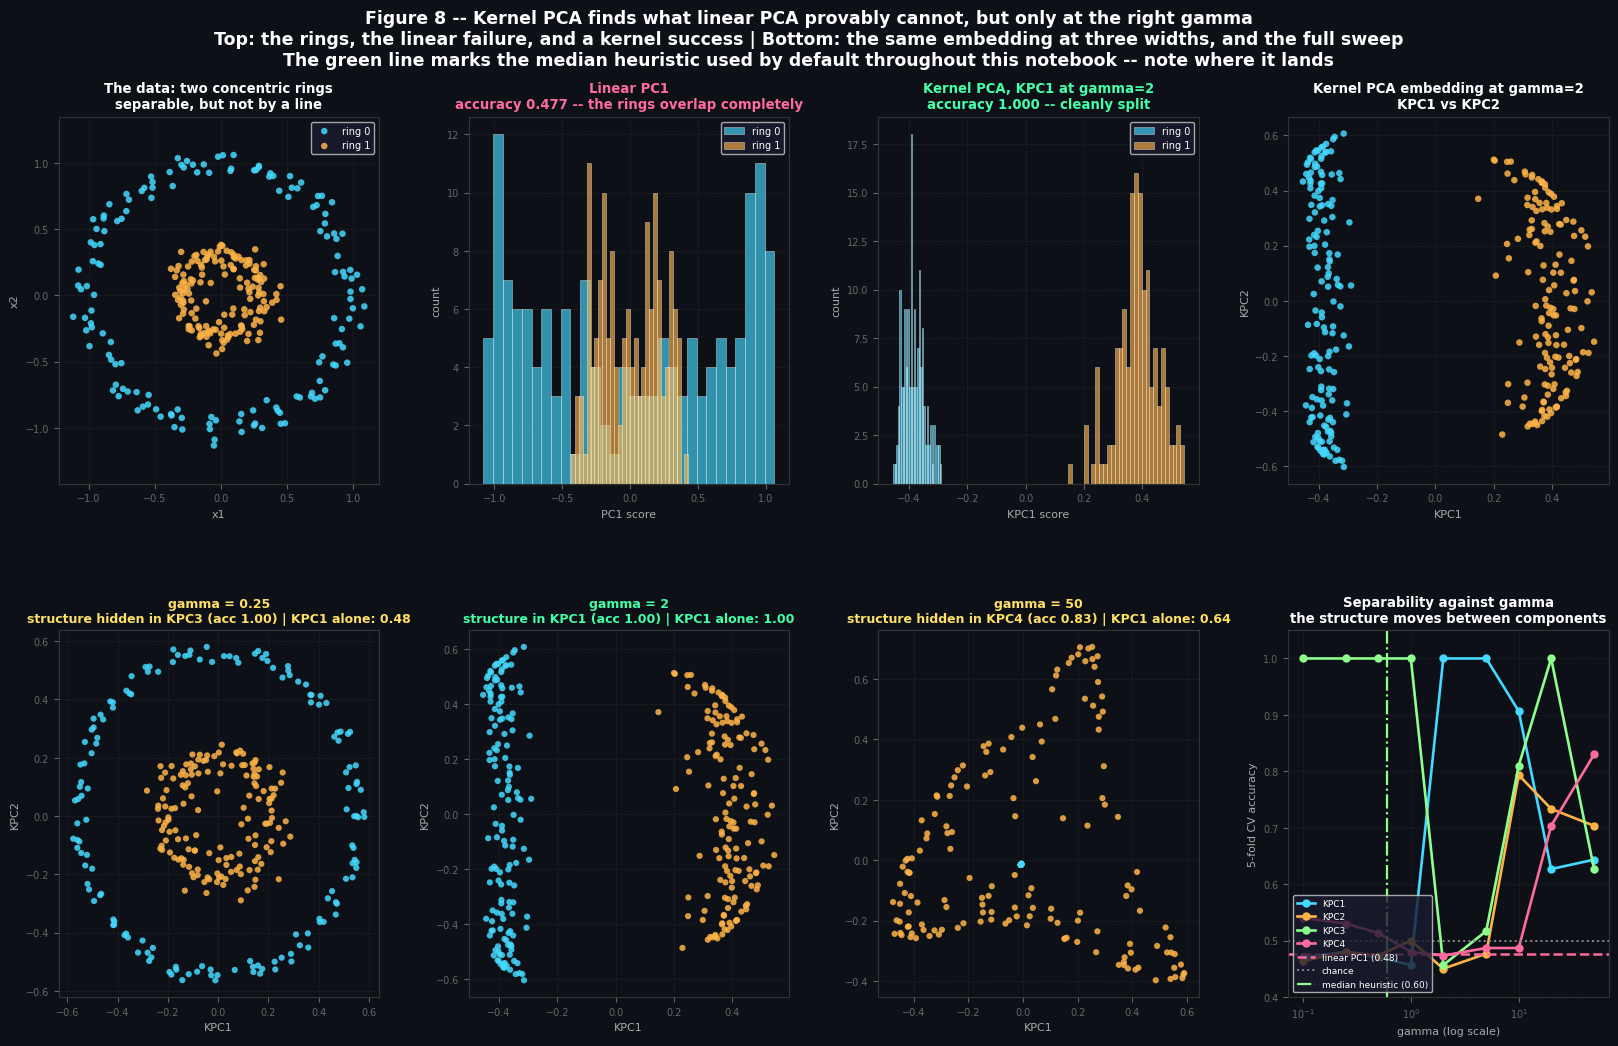

Saved pca_fig8_kernel_pca_circles.png


In [27]:
fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.40, wspace=0.28,
                       top=0.870, bottom=0.070)

RING = ['#44d9ff', '#ffb347']

# -- Panel 1: the raw data ---------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
style_ax(ax)
for c in [0, 1]:
    ax.scatter(Xc[yc == c, 0], Xc[yc == c, 1], s=22, color=RING[c],
               edgecolor='none', alpha=0.85, label=f'ring {c}')
ax.set_title('The data: two concentric rings\nseparable, but not by a line',
             color=TC, fontsize=9.5, fontweight='bold')
ax.set_xlabel('x1', color=AC, fontsize=8); ax.set_ylabel('x2', color=AC, fontsize=8)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')
ax.set_aspect('equal', adjustable='datalim')

# -- Panel 2: linear PCA, 1D ------------------------------------------------
ax = fig.add_subplot(gs[0, 1])
style_ax(ax)
for c in [0, 1]:
    ax.hist(lin1[yc == c, 0], bins=30, color=RING[c], alpha=0.65,
            edgecolor='white', lw=0.4, label=f'ring {c}')
ax.set_title(f'Linear PC1\naccuracy {acc_lin:.3f} -- the rings overlap completely',
             color='#ff6b9d', fontsize=9.5, fontweight='bold')
ax.set_xlabel('PC1 score', color=AC, fontsize=8); ax.set_ylabel('count', color=AC, fontsize=8)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')

# -- Panels 3-4: kernel PCA at a working gamma ------------------------------
g_best = g_top
S_best = KPCA_SWEEP[g_best][0]
k_best = int(np.argmax(KPCA_SWEEP[g_best][1]))

ax = fig.add_subplot(gs[0, 2])
style_ax(ax)
for c in [0, 1]:
    ax.hist(S_best[yc == c, k_best], bins=30, color=RING[c], alpha=0.65,
            edgecolor='white', lw=0.4, label=f'ring {c}')
ax.set_title(f'Kernel PCA, KPC{k_best+1} at gamma={g_best:g}\n'
             f'accuracy {max(KPCA_SWEEP[g_best][1]):.3f} -- cleanly split',
             color='#44ffaa', fontsize=9.5, fontweight='bold')
ax.set_xlabel(f'KPC{k_best+1} score', color=AC, fontsize=8)
ax.set_ylabel('count', color=AC, fontsize=8)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')

ax = fig.add_subplot(gs[0, 3])
style_ax(ax)
for c in [0, 1]:
    ax.scatter(S_best[yc == c, 0], S_best[yc == c, 1], s=22, color=RING[c],
               edgecolor='none', alpha=0.85)
ax.set_title(f'Kernel PCA embedding at gamma={g_best:g}\nKPC1 vs KPC2',
             color=TC, fontsize=9.5, fontweight='bold')
ax.set_xlabel('KPC1', color=AC, fontsize=8); ax.set_ylabel('KPC2', color=AC, fontsize=8)

# -- Bottom row: three gammas showing the structure move --------------------
show_g = [0.25, 2.0, 50.0]
for i, g in enumerate(show_g):
    S, accs = KPCA_SWEEP[g]
    kb = int(np.argmax(accs))
    ax = fig.add_subplot(gs[1, i])
    style_ax(ax)
    for c in [0, 1]:
        ax.scatter(S[yc == c, 0], S[yc == c, 1], s=20, color=RING[c],
                   edgecolor='none', alpha=0.85)
    tag = ('structure in KPC1' if kb == 0 else f'structure hidden in KPC{kb+1}')
    ax.set_title(f'gamma = {g:g}\n{tag} (acc {accs[kb]:.2f}) | KPC1 alone: {accs[0]:.2f}',
                 color=('#44ffaa' if kb == 0 else '#ffe066'), fontsize=9, fontweight='bold')
    ax.set_xlabel('KPC1', color=AC, fontsize=8); ax.set_ylabel('KPC2', color=AC, fontsize=8)

# -- Bottom right: the sweep curve ------------------------------------------
ax = fig.add_subplot(gs[1, 3])
style_ax(ax)
for k in range(4):
    ax.plot(gammas, [KPCA_SWEEP[float(g)][1][k] for g in gammas],
            marker='o', ms=5, lw=1.9, color=PC_COLORS[k], label=f'KPC{k+1}')
ax.axhline(acc_lin, color='#ff6b9d', ls='--', lw=1.8,
           label=f'linear PC1 ({acc_lin:.2f})')
ax.axhline(0.5, color='#888888', ls=':', lw=1.4, label='chance')
ax.axvline(gamma_med, color='#8dff8d', ls='-.', lw=1.6,
           label=f'median heuristic ({gamma_med:.2f})')
ax.set_xscale('log')
ax.set_ylim(0.4, 1.05)
ax.set_title('Separability against gamma\nthe structure moves between components',
             color=TC, fontsize=9.5, fontweight='bold')
ax.set_xlabel('gamma (log scale)', color=AC, fontsize=8)
ax.set_ylabel('5-fold CV accuracy', color=AC, fontsize=8)
ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='lower left')

fig.suptitle(
    'Figure 8 -- Kernel PCA finds what linear PCA provably cannot, but only at the right gamma\n'
    'Top: the rings, the linear failure, and a kernel success | Bottom: the same embedding at three widths, and the full sweep\n'
    'The green line marks the median heuristic used by default throughout this notebook -- note where it lands',
    color='white', fontsize=12.5, fontweight='bold', y=0.968)

plt.savefig('pca_fig8_kernel_pca_circles.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig8_kernel_pca_circles.png')

### 10.4 Now on our own eight functions

The circles were built to make kernel PCA win. The honest question is what it does on the actual
capstone data, where the designs are space-filling and there is no hidden manifold to unroll.

Both fidelity measures from Section 11 are used, because both are computed **in the original input
space** and therefore mean the same thing for a linear and a kernel embedding — unlike explained
variance, which Cell 24 showed is not comparable across the two.

Expect a modest result. A method that adds a hyperparameter, removes the loadings and destroys the
pre-image needs to earn its place, and on an isotropic design it usually cannot.

### Cell 28 — $\gamma$ sweep across all eight functions

In [28]:
print('=' * 112)
print('  KERNEL PCA ON F1-F8 -- does it beat linear PCA on OUR data?')
print('  Both scores measured in the original input space, so linear and kernel are comparable')
print('=' * 112)

gamma_mult = np.array([0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 10.0, 25.0])
KSWEEP = {}
rows = []

for fid in FIDS:
    Z = SPEC[fid]['Z']
    n = len(Z)
    k_tw = max(2, min(5, (n - 1) // 2 - 1))
    D0 = pdist(Z)
    g_med = 1.0 / (2.0 * np.median(pdist(Z, 'sqeuclidean')))

    # linear baseline
    E_lin = fit_pca(Z, n_components=min(2, DIMS[fid]))['scores']
    T_lin = float(trustworthiness(Z, E_lin, n_neighbors=k_tw))
    R_lin = float(stats.spearmanr(D0, pdist(E_lin)).statistic)

    Ts, Rs = [], []
    for m in gamma_mult:
        E = KernelPCA(n_components=min(2, DIMS[fid]), kernel='rbf',
                      gamma=g_med * m, random_state=RANDOM_STATE).fit_transform(Z)
        if E.shape[1] < 2:
            Ts.append(np.nan); Rs.append(np.nan); continue
        Ts.append(float(trustworthiness(Z, E, n_neighbors=k_tw)))
        Rs.append(float(stats.spearmanr(D0, pdist(E)).statistic))
    Ts, Rs = np.array(Ts), np.array(Rs)

    KSWEEP[fid] = dict(g_med=g_med, mult=gamma_mult, T=Ts, R=Rs,
                       T_lin=T_lin, R_lin=R_lin)
    i_best = int(np.nanargmax(Ts))
    rows.append({
        'Fn':            f'F{fid}',
        'd':             DIMS[fid],
        'gamma median':  round(g_med, 3),
        'linear T':      round(T_lin, 3),
        'best kernel T': round(float(Ts[i_best]), 3),
        'at gamma x':    gamma_mult[i_best],
        'T gain':        round(float(Ts[i_best]) - T_lin, 3),
        'linear rho':    round(R_lin, 3),
        'kernel rho there': round(float(Rs[i_best]), 3),
        'rho change':    round(float(Rs[i_best]) - R_lin, 3),
    })

KSWEEP_TABLE = pd.DataFrame(rows)
print(KSWEEP_TABLE.to_string(index=False))

print('\n  "at gamma x" is a MULTIPLE of that function\'s median heuristic, so 1.0 means the')
print('  default width was already optimal and anything else means the default was not.')

gain = KSWEEP_TABLE['T gain'].to_numpy()
n_better = int((gain > 0.01).sum())
print(f'\n  Kernel PCA improved local fidelity by more than 0.01 in {n_better} of {len(FIDS)} functions.')
n_med_best = int((KSWEEP_TABLE['at gamma x'] == 1.0).sum())
print(f'  The median heuristic was the best swept width in {n_med_best} of {len(FIDS)} functions.')

n_small = int((KSWEEP_TABLE['at gamma x'] <= 0.1).sum())
if n_small:
    print(f'\n  In {n_small} of {len(FIDS)} functions the best width was at or below 0.1x the median '
          f'heuristic.')
    print('  That is worth reading carefully rather than as a tuning result. As gamma -> 0 the RBF')
    print('  kernel exp(-gamma d^2) -> 1 - gamma d^2, which is linear in the squared distances, so')
    print('  kernel PCA converges on ORDINARY PCA. The sweep is telling us the best kernel for')
    print('  these designs is the one that stops being a kernel -- which doubles as a check that')
    print('  the implementation is correct, since the two methods agree in the limit where theory')
    print('  says they must.')

tradeoff = KSWEEP_TABLE[(KSWEEP_TABLE['T gain'] > 0) & (KSWEEP_TABLE['rho change'] < -0.01)]
if len(tradeoff):
    print(f"\n  Functions where the local gain was paid for with a GLOBAL loss: "
          f"{', '.join(tradeoff['Fn'])}")
    print('  That is the same trade-off Section 11 finds for t-SNE, in milder form: neighbourhood')
    print('  detail bought by distorting the large-scale geometry.')

print('\n  VERDICT FOR THIS CAPSTONE')
print('  Kernel PCA is the right tool when the structure is curved, and the circles demonstration')
print('  shows it genuinely recovers what no rotation can. Our designs are not that case: they are')
print('  space-filling by construction, so there is no manifold folded up inside them and the')
print('  gains above are small and inconsistent.')
print('  Against that, you give up the loadings (Section 7 becomes inapplicable), you give up the')
print('  pre-image (so no embedding coordinate can be turned back into a query), and you take on a')
print('  hyperparameter that Cell 25 showed can move the structure between components.')
print('  Use linear PCA for describing these designs. Keep kernel PCA for the case where you have')
print('  independent reason to believe the sampled region is curved -- and say what that reason is.')

  KERNEL PCA ON F1-F8 -- does it beat linear PCA on OUR data?
  Both scores measured in the original input space, so linear and kernel are comparable
Fn  d  gamma median  linear T  best kernel T  at gamma x  T gain  linear rho  kernel rho there  rho change
F1  2         0.241     1.000          1.000        0.05   0.000       1.000             1.000      -0.000
F2  2         0.140     1.000          1.000        0.05   0.000       1.000             1.000      -0.000
F3  3         0.098     0.926          0.933        1.00   0.007       0.911             0.813      -0.098
F4  4         0.072     0.868          0.871        0.10   0.003       0.834             0.833      -0.001
F5  4         0.061     0.903          0.908        1.00   0.005       0.923             0.910      -0.014
F6  5         0.052     0.885          0.886        0.50   0.001       0.805             0.784      -0.021
F7  6         0.043     0.835          0.845        2.00   0.011       0.797             0.582      -

### Cell 29 — Figure 9: the $\gamma$ sweep on the capstone functions

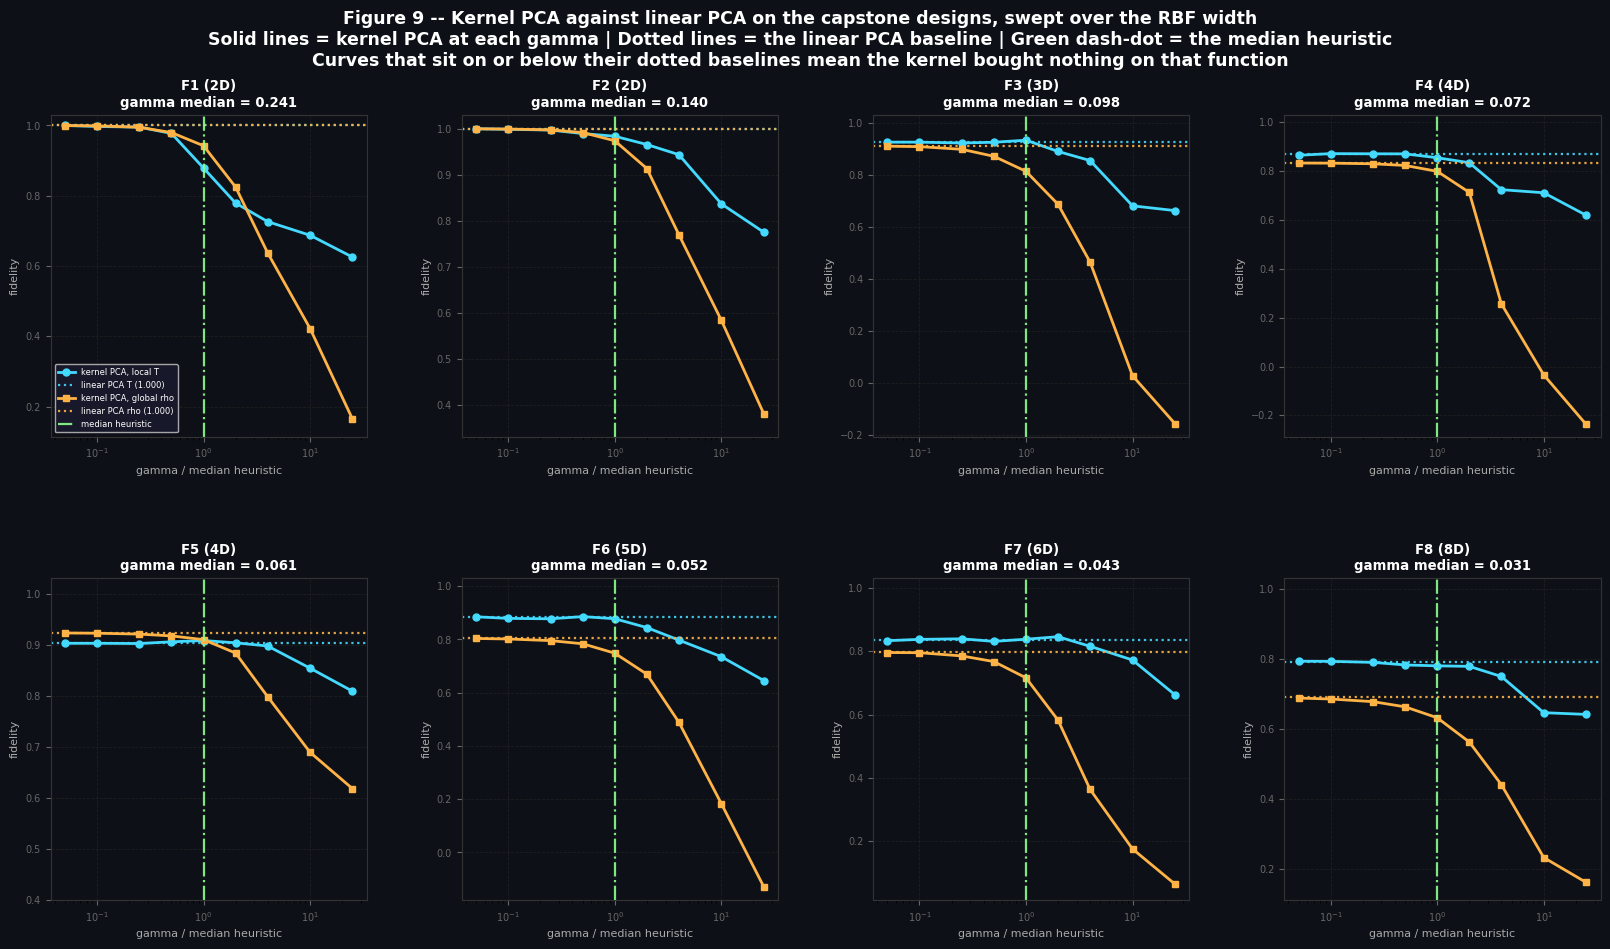

Saved pca_fig9_kernel_gamma_sweep.png


In [29]:
fig = plt.figure(figsize=(20, 10))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.44, wspace=0.30,
                       top=0.860, bottom=0.075)

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 4)
    ax = fig.add_subplot(gs[r, c])
    style_ax(ax)
    K = KSWEEP[fid]

    ax.plot(K['mult'], K['T'], marker='o', ms=5, lw=2, color='#44d9ff',
            label='kernel PCA, local T')
    ax.axhline(K['T_lin'], color='#44d9ff', ls=':', lw=1.6, alpha=0.9,
               label=f"linear PCA T ({K['T_lin']:.3f})")
    ax.plot(K['mult'], K['R'], marker='s', ms=5, lw=2, color='#ffb347',
            label='kernel PCA, global rho')
    ax.axhline(K['R_lin'], color='#ffb347', ls=':', lw=1.6, alpha=0.9,
               label=f"linear PCA rho ({K['R_lin']:.3f})")
    ax.axvline(1.0, color='#8dff8d', ls='-.', lw=1.6, alpha=0.9,
               label='median heuristic')

    ax.set_xscale('log')
    ax.set_ylim(min(0.4, float(np.nanmin([K['T'].min(), K['R'].min()])) - 0.05), 1.03)
    ax.set_title(f"F{fid} ({DIMS[fid]}D)\ngamma median = {K['g_med']:.3f}",
                 color=TC, fontsize=9.5, fontweight='bold')
    ax.set_xlabel('gamma / median heuristic', color=AC, fontsize=8)
    ax.set_ylabel('fidelity', color=AC, fontsize=8)
    if idx == 0:
        ax.legend(fontsize=6, facecolor='#1a1a2e', labelcolor='white', loc='lower left')

fig.suptitle(
    'Figure 9 -- Kernel PCA against linear PCA on the capstone designs, swept over the RBF width\n'
    'Solid lines = kernel PCA at each gamma | Dotted lines = the linear PCA baseline | '
    'Green dash-dot = the median heuristic\n'
    'Curves that sit on or below their dotted baselines mean the kernel bought nothing on that function',
    color='white', fontsize=12.5, fontweight='bold', y=0.965)

plt.savefig('pca_fig9_kernel_gamma_sweep.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig9_kernel_gamma_sweep.png')

---
## Section 11 — Nonlinear reduction, and how to tell whether it helped

PCA can only rotate. If the sampled region lies on a curved surface — a valley that bends, a ridge
that turns — no linear projection recovers it. Four alternatives, each with a different definition
of "structure":

| Method | Preserves | Out-of-sample? | Honest use |
|---|---|---|---|
| **Kernel PCA** (RBF) | Inner products in a feature space | Yes | Curved but smooth structure -- covered in depth in Section 10 |
| **Isomap** | Geodesic distances along a neighbour graph | Approximately | Manifolds with a clear neighbourhood scale |
| **MDS** | All pairwise distances | No | Faithful global geometry |
| **$t$-SNE** | Local neighbourhoods only | **No** | Visual inspection, nothing else |
| **Random projection** | Distances, approximately (Johnson–Lindenstrauss) | Yes | The baseline that costs no thought |

The random projection is included deliberately. If a method cannot beat a random 2D projection,
the structure it claims to have found is decoration.

### 10.1 Two metrics, because one metric would be rigged

A 2D scatter always looks like *something*, so the comparison needs numbers rather than taste.

**Local — trustworthiness** (Venna & Kaski). Do the points that appear close in the embedding
correspond to points that were actually close in the original space? False neighbours are penalised
by their original-space rank:

$$
T(k) = 1 - \frac{2}{nk(2n - 3k - 1)}\sum_{i=1}^{n}\sum_{j \in U_i^{(k)}} \left(\rho_{ij} - k\right)
$$

**Global — the Shepard correlation.** The Spearman correlation between all original pairwise
distances and all embedded pairwise distances. Rank-based, so it is indifferent to the monotone
rescalings every embedding applies.

Reporting only the first would be a rigged contest: **trustworthiness is essentially $t$-SNE's own
objective**, and the Shepard correlation is essentially MDS's. Each method would win its own exam.
Together they expose the trade-off that is actually being made — a method that wins locally while
collapsing globally has bought neighbourhood detail by destroying the large-scale geometry, which
for an optimisation problem is usually the wrong trade.

### 10.2 Two warnings about $t$-SNE, both of which apply to us

**Sample size.** With $n = 22$ and perplexity capped below $n/3$, $t$-SNE is fitting a
neighbourhood model to about six neighbours per point. The layout will change with the seed.

**Distances are not distances.** $t$-SNE deliberately distorts scale — cluster sizes and
between-cluster gaps in the output carry no meaning. Never measure anything on a $t$-SNE plot;
never feed its coordinates to a downstream model.

### Cell 30 — Fit five embeddings per function and score them all

In [30]:
def embeddings(fid, random_state=RANDOM_STATE):
    """Five 2D embeddings of one function's standardised inputs, each scored by
    trustworthiness against the original space."""
    Z   = SPEC[fid]['Z']
    n, dim = Z.shape
    k_tw = max(2, min(5, (n - 1) // 2 - 1))          # trustworthiness needs k < n/2
    out  = {}

    out['PCA'] = fit_pca(Z, n_components=min(2, dim))['scores']

    # median heuristic for the RBF width -- gamma = 1 / (2 * median squared distance)
    dsq = pdist(Z, 'sqeuclidean')
    gamma = 1.0 / (2.0 * np.median(dsq)) if np.median(dsq) > 0 else 1.0
    out['KernelPCA (RBF)'] = KernelPCA(n_components=min(2, dim), kernel='rbf',
                                       gamma=gamma,
                                       random_state=random_state).fit_transform(Z)

    try:
        nn = int(np.clip(n // 4, 4, n - 2))
        out['Isomap'] = Isomap(n_components=2, n_neighbors=nn).fit_transform(Z)
    except Exception as e:
        out['Isomap'] = None

    out['MDS'] = MDS(n_components=2, random_state=random_state,
                     n_init=4, max_iter=400).fit_transform(Z)

    perp = float(np.clip((n - 1) / 3.0, 2.0, 30.0))
    out['t-SNE'] = TSNE(n_components=2, perplexity=perp, init='pca',
                        learning_rate='auto',
                        random_state=random_state).fit_transform(Z)

    if dim > 2:
        out['Random proj.'] = GaussianRandomProjection(
            n_components=2, random_state=random_state).fit_transform(Z)
    else:
        out['Random proj.'] = None

    D0 = pdist(Z)
    scores, glob = {}, {}
    for name, E in out.items():
        if E is None or E.shape[1] < 2:
            scores[name] = glob[name] = np.nan
            continue
        scores[name] = float(trustworthiness(Z, E, n_neighbors=k_tw))
        # Global fidelity: Spearman correlation between original and embedded
        # pairwise distances (the Shepard-diagram correlation). Rank-based, so it
        # tolerates the monotone rescalings that every embedding applies.
        glob[name] = float(stats.spearmanr(D0, pdist(E)).statistic)
    return out, scores, glob, k_tw, perp


print('=' * 116)
print('  NONLINEAR EMBEDDINGS -- trustworthiness of each 2D projection')
print('  T = 1 perfect neighbourhood preservation, T ~ 0.5 chance')
print('=' * 116)

METHODS = ['PCA', 'KernelPCA (RBF)', 'Isomap', 'MDS', 't-SNE', 'Random proj.']

EMB, TW, GLOB = {}, {}, {}
rows_l, rows_g = [], []
for fid in FIDS:
    E, S, G, k_tw, perp = embeddings(fid)
    EMB[fid], TW[fid], GLOB[fid] = E, S, G
    base = {'Fn': f'F{fid}', 'd': DIMS[fid], 'n': len(DATA[fid]['y'])}
    rl = dict(base, **{'k (nbrs)': k_tw, 'perplexity': round(perp, 1)})
    rg = dict(base)
    for name in METHODS:
        rl[name] = 'n/a' if np.isnan(S.get(name, np.nan)) else round(S[name], 3)
        rg[name] = 'n/a' if np.isnan(G.get(name, np.nan)) else round(G[name], 3)
    rows_l.append(rl); rows_g.append(rg)

TW_TABLE = pd.DataFrame(rows_l)
GLOB_TABLE = pd.DataFrame(rows_g)
print('\n  LOCAL fidelity -- trustworthiness (are the embedding\'s neighbours real neighbours?)')
print(TW_TABLE.to_string(index=False))
print('\n  GLOBAL fidelity -- Spearman correlation of pairwise distances (Shepard correlation)')
print(GLOB_TABLE.to_string(index=False))

print('\n' + '-' * 116)
print('  BEFORE READING THESE TABLES: each metric is some method\'s own objective.')
print('-' * 116)
print('  t-SNE optimises local neighbourhood preservation, which is what trustworthiness')
print('  measures. MDS optimises agreement of pairwise distances, which is what the Shepard')
print('  correlation measures. So each will tend to win its own table almost by definition.')
print('  A single-metric comparison here would not be an evaluation, it would be a tautology.')
print('  Read the two together: a method that wins BOTH has found something; a method that wins')
print('  one and collapses on the other has traded away a property you may still need.')

print('\n  Local vs global, per function (d >= 3 only -- below that there is nothing to reduce):')
for fid in FIDS:
    if DIMS[fid] < 3:
        continue
    S = {k: v for k, v in TW[fid].items() if not np.isnan(v)}
    G = {k: v for k, v in GLOB[fid].items() if not np.isnan(v)}
    bl, bg = max(S, key=S.get), max(G, key=G.get)
    print(f"    F{fid} ({DIMS[fid]}D): local winner {bl:<16} T={S[bl]:.3f} "
          f"(its global rho={G.get(bl, float('nan')):+.3f})")
    print(f"              global winner {bg:<16} rho={G[bg]:+.3f} "
          f"(its local T={S.get(bg, float('nan')):.3f})")
    print(f"              plain PCA     T={S['PCA']:.3f}, rho={G['PCA']:+.3f}   |   "
          f"random projection T={S.get('Random proj.', float('nan')):.3f}, "
          f"rho={G.get('Random proj.', float('nan')):+.3f}")

print('\n  Compare every row against the RANDOM PROJECTION figures. A method that only just beats')
print('  a random 2D projection has not earned the extra assumptions, the tuning parameters, or')
print('  the loss of an out-of-sample transform.')
print('\n  For 2D functions every method scores near 1.0 -- a "2D embedding" of 2D data is at')
print('  worst a rotation, so those rows carry no information about method quality.')
if not HAS_UMAP:
    print('\n  UMAP not installed; it would slot in beside t-SNE with the same caveats plus an')
    print('  out-of-sample transform. pip install umap-learn to add it.')

  NONLINEAR EMBEDDINGS -- trustworthiness of each 2D projection
  T = 1 perfect neighbourhood preservation, T ~ 0.5 chance

  LOCAL fidelity -- trustworthiness (are the embedding's neighbours real neighbours?)
Fn  d  n  k (nbrs)  perplexity   PCA  KernelPCA (RBF)  Isomap   MDS  t-SNE Random proj.
F1  2 23         5         7.3 1.000            0.879   0.976 1.000  0.843          n/a
F2  2 23         5         7.3 1.000            0.984   0.975 1.000  0.963          n/a
F3  3 28         5         9.0 0.926            0.933   0.920 0.941  0.951        0.874
F4  4 43         5        14.0 0.868            0.855   0.862 0.886  0.917        0.809
F5  4 33         5        10.7 0.903            0.908   0.942 0.948  0.971          0.9
F6  5 33         5        10.7 0.885            0.878   0.889 0.921  0.928        0.866
F7  6 43         5        14.0 0.835            0.837   0.822 0.905  0.868        0.801
F8  8 53         5        17.3 0.791            0.780   0.789 0.834  0.888        0.75


  LOCAL fidelity -- trustworthiness (are the embedding's neighbours real neighbours?)
Fn  d  n  k (nbrs)  perplexity   PCA  KernelPCA (RBF)  Isomap   MDS  t-SNE Random proj.
F1  2 22         5         7.0 1.000            0.903   0.983 1.000  0.810          n/a
F2  2 22         5         7.0 1.000            0.979   0.978 0.999  0.968          n/a
F3  3 27         5         8.7 0.920            0.917   0.945 0.926  0.949        0.864
F4  4 42         5        13.7 0.869            0.854   0.862 0.888  0.919         0.81
F5  4 32         5        10.3 0.895            0.895   0.940 0.938  0.960        0.891
F6  5 32         5        10.3 0.882            0.879   0.890 0.931  0.925        0.868
F7  6 42         5        13.7 0.841            0.840   0.820 0.906  0.896        0.802
F8  8 52         5        17.0 0.786            0.776   0.785 0.801  0.928         0.75

  GLOBAL fidelity -- Spearman correlation of pairwise distances (Shepard correlation)
Fn  d  n   PCA  KernelPCA (RBF)  I

### Cell 31 — Figure 10: embedding gallery for the higher-dimensional functions

Shown for $d \ge 3$ only, since a 2D embedding of a 2D function is a rotation and teaches nothing.
Every point is coloured by its (transformed) $y$, so you can judge each method on the question that
matters: **does the projection put good points near good points?** The trustworthiness score in each
title is the quantitative version of the same question, minus the wishful thinking.

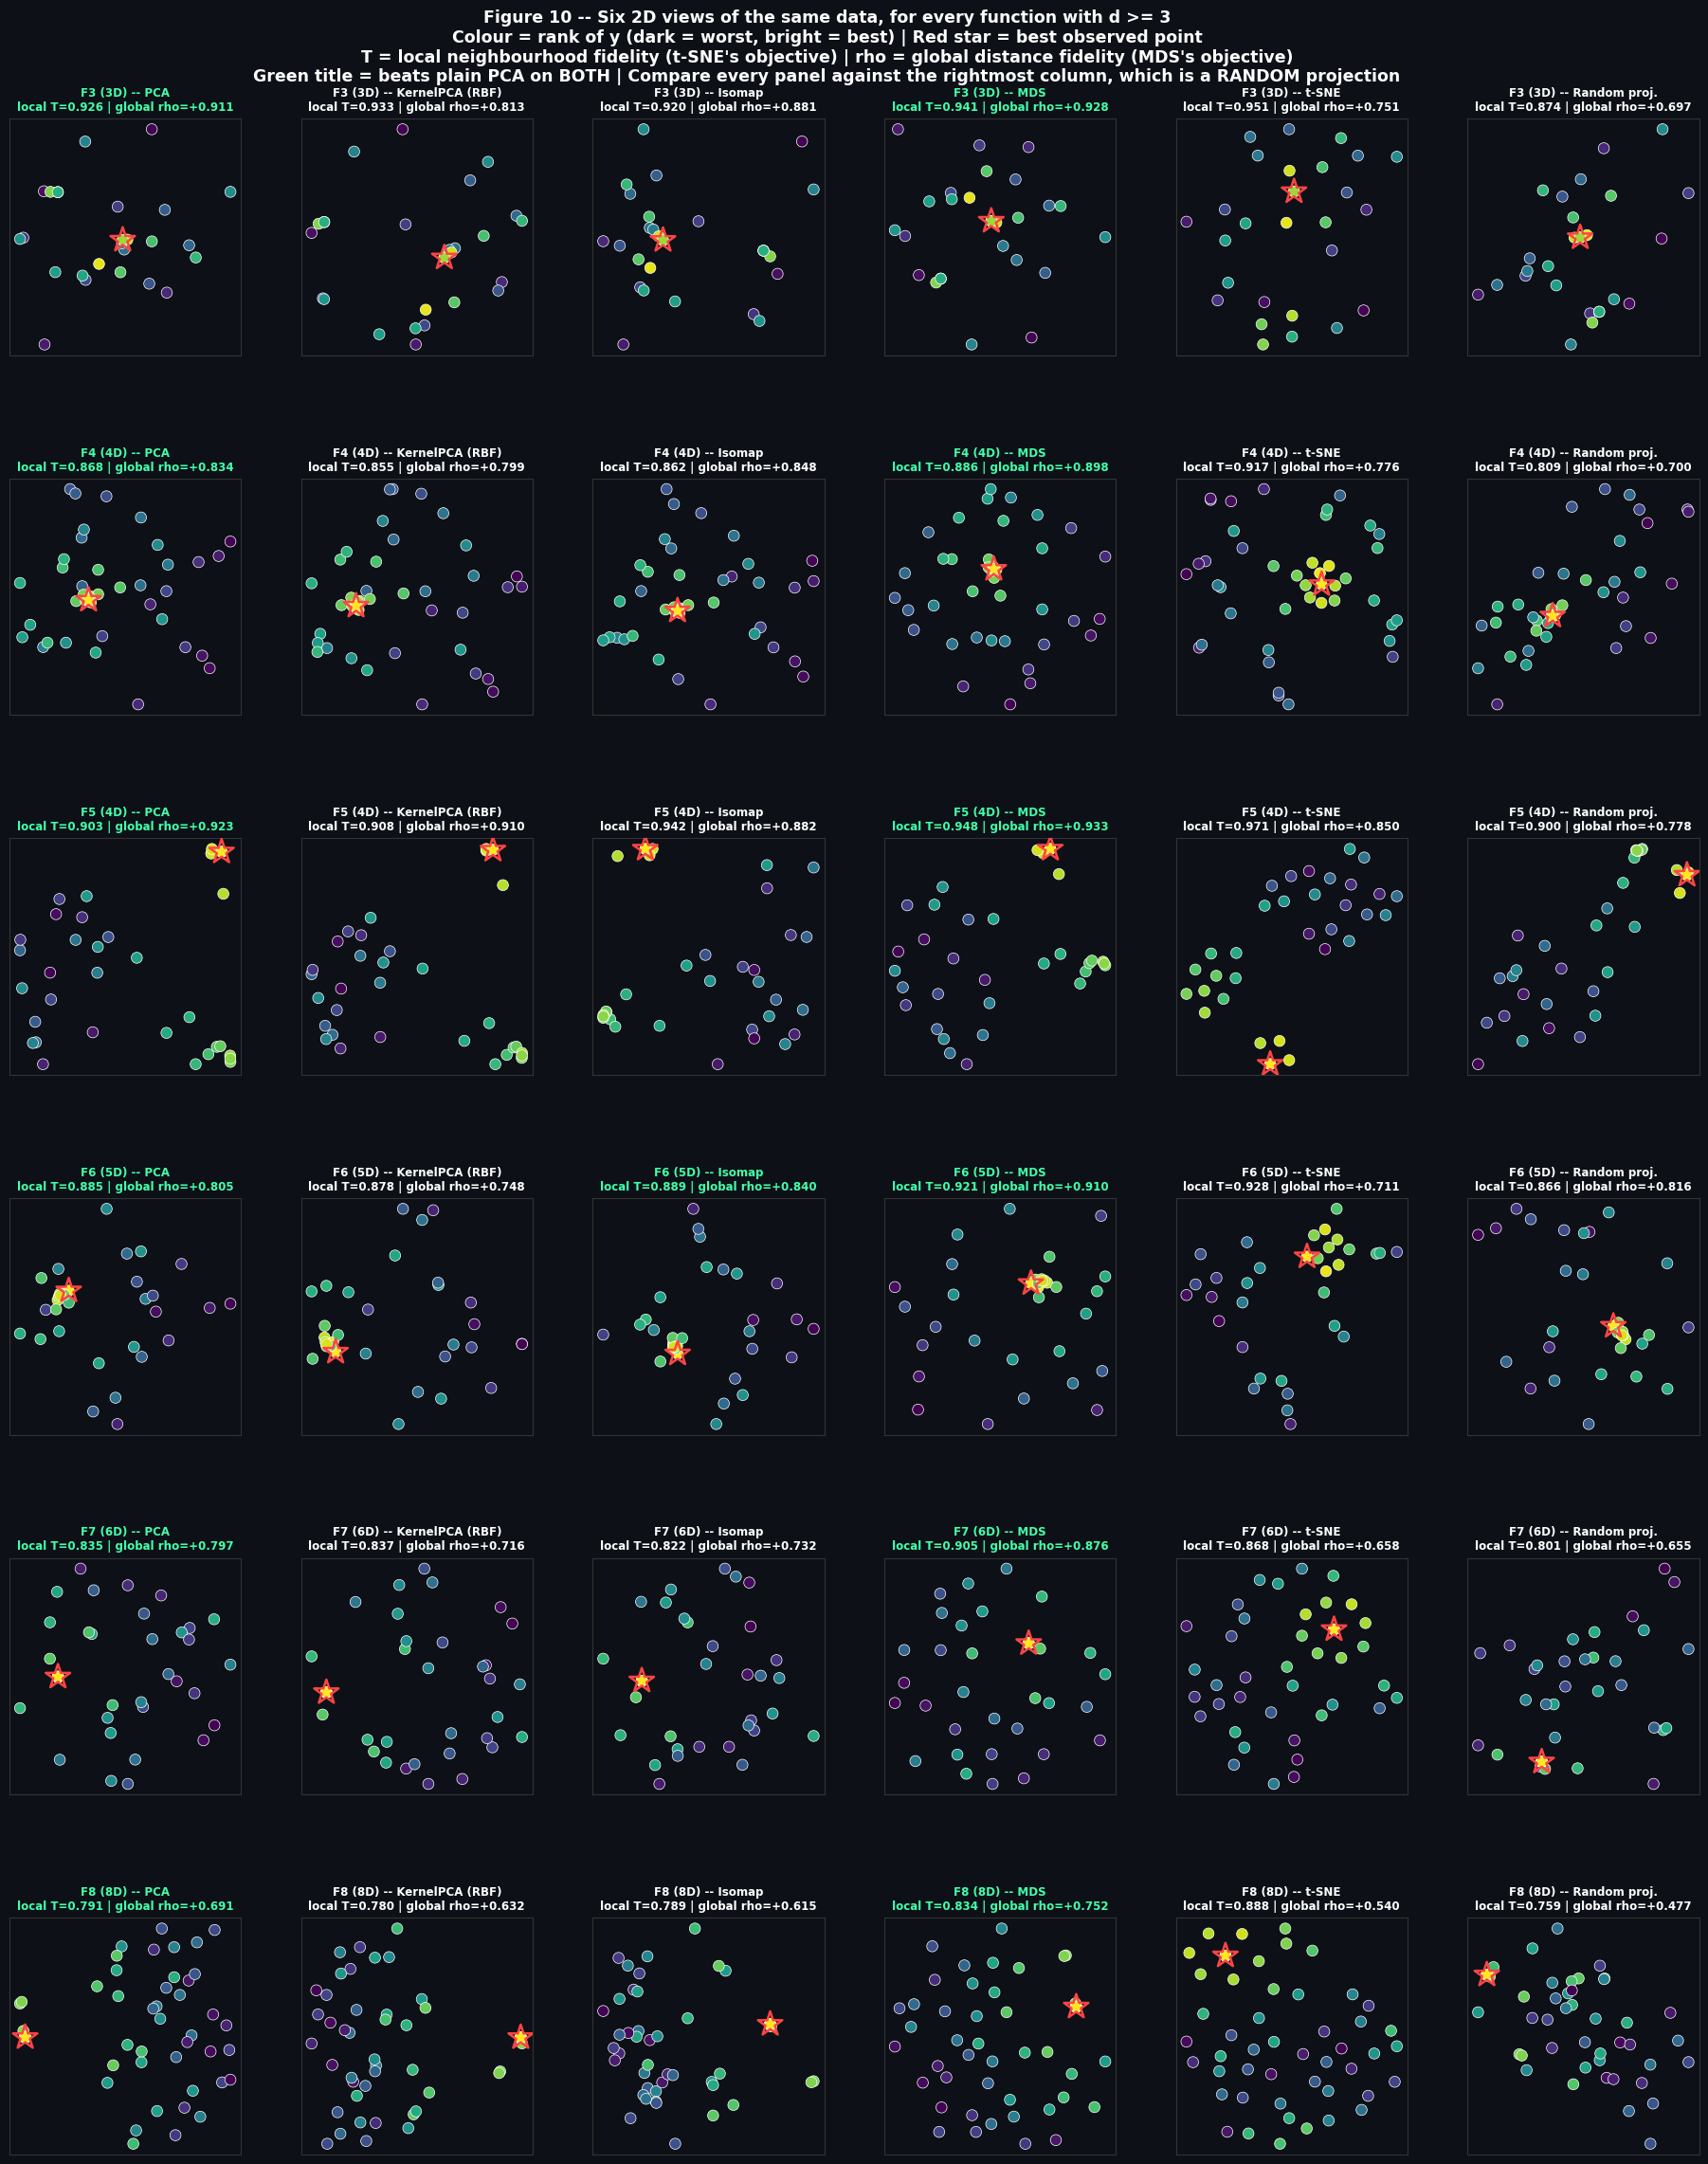

Saved pca_fig10_embedding_gallery.png


In [31]:
show_fids = [f for f in FIDS if DIMS[f] >= 3]
methods = ['PCA', 'KernelPCA (RBF)', 'Isomap', 'MDS', 't-SNE', 'Random proj.']

fig = plt.figure(figsize=(23, 4.0 * len(show_fids)))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(len(show_fids), len(methods), figure=fig,
                       hspace=0.52, wspace=0.26, top=0.930, bottom=0.035)

for r, fid in enumerate(show_fids):
    d  = DATA[fid]
    # Colour by RANK, not by the per-function adopted treatment. Colour is a purely
    # ordinal encoding here, and a rank scale is both readable for skewed outputs
    # (F7's raw y would put almost every point at one end of viridis) and directly
    # comparable across panels with wildly different y units.
    yv = transform_y(d['y'], 'rank')
    best_i = int(np.argmax(d['y']))
    for c, name in enumerate(methods):
        ax = fig.add_subplot(gs[r, c])
        style_ax(ax)
        E = EMB[fid].get(name)
        if E is None or E.shape[1] < 2:
            ax.text(0.5, 0.5, f'{name}\nnot applicable', transform=ax.transAxes,
                    ha='center', va='center', color='#777777', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        ax.scatter(E[:, 0], E[:, 1], c=yv, cmap='viridis', s=70,
                   edgecolor='white', lw=0.5, zorder=3)
        ax.scatter([E[best_i, 0]], [E[best_i, 1]], marker='*', s=380,
                   facecolor='none', edgecolor='#ff4444', lw=1.8, zorder=6)
        t = TW[fid].get(name, np.nan)
        g = GLOB[fid].get(name, np.nan)
        both = (not np.isnan(t) and t >= TW[fid]['PCA']
                and not np.isnan(g) and g >= GLOB[fid]['PCA'])
        col = '#44ffaa' if both else TC
        ax.set_title(f"F{fid} ({DIMS[fid]}D) -- {name}\n"
                     f"local T={t:.3f} | global rho={g:+.3f}",
                     color=col, fontsize=8.5, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(
    'Figure 10 -- Six 2D views of the same data, for every function with d >= 3\n'
    'Colour = rank of y (dark = worst, bright = best) | Red star = best observed point\n'
    'T = local neighbourhood fidelity (t-SNE\'s objective) | rho = global distance fidelity (MDS\'s objective)\n'
    'Green title = beats plain PCA on BOTH | Compare every panel against the rightmost column, which is a RANDOM projection',
    color='white', fontsize=12.5, fontweight='bold', y=0.978)

plt.savefig('pca_fig10_embedding_gallery.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig10_embedding_gallery.png')

---
## Section 12 — Intrinsic dimension and the curse, measured on our own ladder

Two related questions, both answerable because we have the same design at eight different $d$.

**11.1 Intrinsic dimension.** PCA measures *linear* dimension. A curved 1D curve embedded in 8D has
linear dimension 8 and intrinsic dimension 1. The **Two-NN estimator** (Facco et al., 2017) uses
only each point's two nearest neighbours: for $\mu_i = r_{i2}/r_{i1}$, the maximum-likelihood
estimate is

$$
\hat{d} = \frac{n}{\sum_i \log \mu_i}
$$

It needs no neighbourhood-size parameter, which matters at $n = 22$.

**Expect $\hat{d} \approx d$.** A space-filling design fills the box, and a filled box has intrinsic
dimension equal to its ambient dimension. Anything meaningfully *below* $d$ would mean the sample
has collapsed onto a lower-dimensional set — which for us would be evidence about the optimiser's
behaviour, not the landscape.

**11.2 Distance concentration.** In high dimensions all pairwise distances converge towards the same
value. The **relative contrast**

$$
\text{RC} = \frac{d_{\max} - d_{\min}}{d_{\text{mean}}}
$$

collapses as $d$ grows, which is why nearest-neighbour reasoning, DBSCAN's `eps`, and silhouette
scores all degrade — the three failures A4 documented empirically. Our eight functions give the
decay curve directly, alongside the uniform-random reference at the same $n$ and $d$.

### Cell 32 — Intrinsic dimension and distance concentration across the ladder

In [32]:
def two_nn_dimension(X):
    """Facco et al. (2017) Two-NN intrinsic dimension estimator.

    Uses only the ratio of the second to the first nearest-neighbour distance,
    so there is no neighbourhood-size parameter to tune -- which is why it is the
    right choice at n = 22. The top decile of ratios is discarded, as recommended,
    because they are dominated by boundary effects.
    """
    D = squareform(pdist(X))
    np.fill_diagonal(D, np.inf)
    srt = np.sort(D, axis=1)
    r1, r2 = srt[:, 0], srt[:, 1]
    ok = (r1 > 0) & np.isfinite(r2)
    mu = r2[ok] / r1[ok]
    mu = np.sort(mu)[:max(3, int(0.9 * len(mu)))]
    return float(len(mu) / np.sum(np.log(mu)))


def relative_contrast(X):
    """(max - min) / mean over all pairwise distances."""
    D = pdist(X)
    return float((D.max() - D.min()) / D.mean()), float(D.std() / D.mean())


print('=' * 112)
print('  INTRINSIC DIMENSION AND DISTANCE CONCENTRATION -- the ladder as a controlled experiment')
print('=' * 112)

rng_ref = np.random.default_rng(RANDOM_STATE)
CURSE = {}
rows = []
for fid in FIDS:
    d   = DATA[fid]
    dim = d['dim']
    n   = len(d['y'])

    id_obs = two_nn_dimension(d['X'])
    rc_obs, cv_obs = relative_contrast(d['X'])

    # uniform reference at the same n and d, averaged over 30 draws
    ids, rcs, cvs = [], [], []
    for _ in range(30):
        U = rng_ref.random((n, dim))
        ids.append(two_nn_dimension(U))
        a, b = relative_contrast(U)
        rcs.append(a); cvs.append(b)

    CURSE[fid] = dict(id_obs=id_obs, id_ref=float(np.mean(ids)),
                      rc_obs=rc_obs, rc_ref=float(np.mean(rcs)),
                      cv_obs=cv_obs, cv_ref=float(np.mean(cvs)))
    rows.append({
        'Fn':               f'F{fid}',
        'd':                dim,
        'n':                n,
        'ID (Two-NN)':      round(id_obs, 2),
        'ID uniform ref':   round(float(np.mean(ids)), 2),
        'ID / ref':         round(id_obs / float(np.mean(ids)), 2),
        'PCA d_eff':        round(SPEC[fid]['pr'], 2),
        'rel. contrast':    round(rc_obs, 3),
        'RC uniform ref':   round(float(np.mean(rcs)), 3),
        'sd/mean dist':     round(cv_obs, 3),
    })

CURSE_TABLE = pd.DataFrame(rows)
print(CURSE_TABLE.to_string(index=False))

print('\n  READ THE "ID / ref" COLUMN, NOT "ID (Two-NN)" ON ITS OWN.')
print('  The raw estimate exceeds d for several functions -- F2 reports about 3 in 2 dimensions.')
print('  That is not a bug and not a finding: the Two-NN estimator is biased upward at small n,')
print('  and the bias is severe at n = 22. The uniform reference column is the SAME estimator on')
print('  a genuinely d-dimensional uniform sample at the same n and d, so it carries the same')
print('  bias. Their ratio cancels it. This is the small-sample-calibration habit that Section 5')
print('  applied to eigenvalues via parallel analysis, reused on a different statistic.')
for fid in FIDS:
    c = CURSE[fid]
    ratio = c['id_obs'] / c['id_ref']
    tag = ('  <- fills its box: no lower-dimensional manifold to find' if ratio > 0.85 else
           '  <- mild collapse onto a lower-dimensional set' if ratio > 0.70 else
           '  <- substantially lower-dimensional than the design intended')
    print(f"    F{fid} ({DIMS[fid]}D): ID/ref = {ratio:.2f} "
          f"({c['id_obs']:.2f} against {c['id_ref']:.2f}){tag}")
print('\n  A ratio below 1 with a space-filling design means the sample has been pulled onto a')
print('  narrower set than the design intended -- and since the only thing editing the sample is')
print('  the acquisition function, that is the optimiser concentrating, exactly as in Section 6.')

dd  = np.array([DIMS[f] for f in FIDS], float)
rcs = np.array([CURSE[f]['rc_obs'] for f in FIDS])
print(f"\n  Correlation between ambient dimension and relative contrast: "
      f"{np.corrcoef(dd, rcs)[0, 1]:+.3f}")
print('  Strongly negative is the curse of dimensionality, demonstrated on our own eight')
print('  functions rather than asserted from a textbook. It is the mechanism behind A4\'s')
print('  falling silhouettes and DBSCAN failures at high d.')

  INTRINSIC DIMENSION AND DISTANCE CONCENTRATION -- the ladder as a controlled experiment
Fn  d  n  ID (Two-NN)  ID uniform ref  ID / ref  PCA d_eff  rel. contrast  RC uniform ref  sd/mean dist
F1  2 23         3.60            2.68      1.34       1.94          2.842           2.083         0.743
F2  2 23         2.65            3.01      0.88       1.91          2.001           2.109         0.534
F3  3 28         4.05            3.70      1.09       2.71          2.459           1.876         0.425
F4  4 43         3.34            5.02      0.67       3.53          2.121           1.779         0.427
F5  4 33         4.88            5.01      0.97       2.75          1.710           1.695         0.384
F6  5 33         6.14            6.04      1.02       3.91          1.968           1.530         0.411
F7  6 43         5.46            6.96      0.78       4.68          1.847           1.485         0.402
F8  8 53         7.66            9.74      0.79       5.91          1.643     

### Cell 33 — Figure 11: the curse, and where PCA stops helping

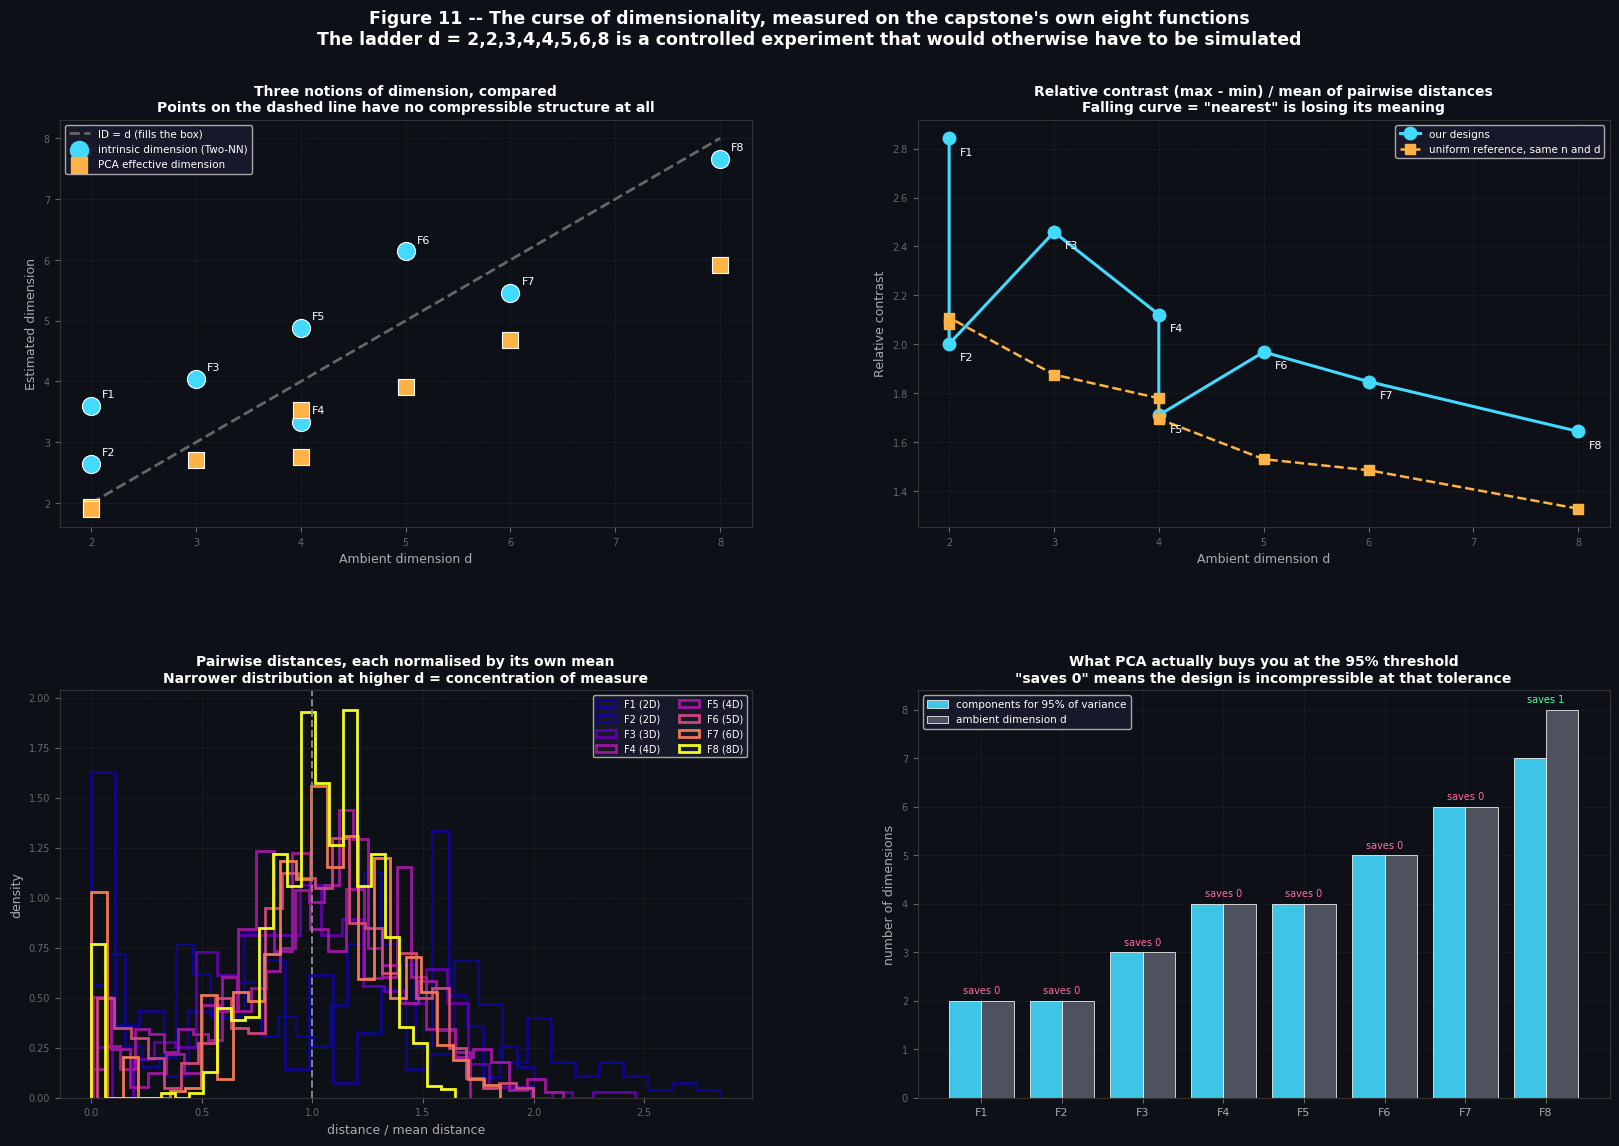

Saved pca_fig11_curse_of_dimensionality.png


In [33]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.24,
                       top=0.880, bottom=0.065)

x = np.arange(len(FIDS))
names = [f'F{f}' for f in FIDS]

# -- Panel 1: intrinsic vs ambient vs PCA effective dimension ----------------
ax = fig.add_subplot(gs[0, 0])
style_ax(ax)
ax.plot(dd, dd, color='#666666', ls='--', lw=2, label='ID = d (fills the box)')
for f in FIDS:
    ax.scatter([DIMS[f]], [CURSE[f]['id_obs']], s=170, color='#44d9ff',
               edgecolor='white', lw=0.8, zorder=5)
    ax.scatter([DIMS[f]], [SPEC[f]['pr']], s=140, marker='s', color='#ffb347',
               edgecolor='white', lw=0.8, zorder=5)
    ax.annotate(f'F{f}', (DIMS[f], CURSE[f]['id_obs']), textcoords='offset points',
                xytext=(8, 6), color='white', fontsize=8)
ax.scatter([], [], s=170, color='#44d9ff', label='intrinsic dimension (Two-NN)')
ax.scatter([], [], s=140, marker='s', color='#ffb347', label='PCA effective dimension')
ax.set_title('Three notions of dimension, compared\n'
             'Points on the dashed line have no compressible structure at all',
             color=TC, fontsize=10, fontweight='bold')
ax.set_xlabel('Ambient dimension d', color=AC, fontsize=9)
ax.set_ylabel('Estimated dimension', color=AC, fontsize=9)
ax.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white', loc='upper left')

# -- Panel 2: distance concentration -----------------------------------------
ax = fig.add_subplot(gs[0, 1])
style_ax(ax)
ax.plot(dd, [CURSE[f]['rc_obs'] for f in FIDS], marker='o', ms=9, lw=2.2,
        color='#44d9ff', label='our designs')
ax.plot(dd, [CURSE[f]['rc_ref'] for f in FIDS], marker='s', ms=7, lw=1.8,
        ls='--', color='#ffb347', label='uniform reference, same n and d')
for f in FIDS:
    ax.annotate(f'F{f}', (DIMS[f], CURSE[f]['rc_obs']), textcoords='offset points',
                xytext=(8, -12), color='white', fontsize=8)
ax.set_title('Relative contrast (max - min) / mean of pairwise distances\n'
             'Falling curve = "nearest" is losing its meaning',
             color=TC, fontsize=10, fontweight='bold')
ax.set_xlabel('Ambient dimension d', color=AC, fontsize=9)
ax.set_ylabel('Relative contrast', color=AC, fontsize=9)
ax.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white')

# -- Panel 3: pairwise distance distributions --------------------------------
ax = fig.add_subplot(gs[1, 0])
style_ax(ax)
for f in FIDS:
    D = pdist(DATA[f]['X'])
    D = D / D.mean()
    ax.hist(D, bins=26, histtype='step', lw=2, density=True,
            color=dim_color(DIMS[f]), label=f'F{f} ({DIMS[f]}D)')
ax.axvline(1.0, color='#888888', lw=1.4, ls='--')
ax.set_title('Pairwise distances, each normalised by its own mean\n'
             'Narrower distribution at higher d = concentration of measure',
             color=TC, fontsize=10, fontweight='bold')
ax.set_xlabel('distance / mean distance', color=AC, fontsize=9)
ax.set_ylabel('density', color=AC, fontsize=9)
ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white', ncol=2)

# -- Panel 4: how many PCs for 95%, absolute and relative --------------------
ax = fig.add_subplot(gs[1, 1])
style_ax(ax)
k95 = [SPEC[f]['k']['var95'] for f in FIDS]
ax.bar(x - 0.2, k95, 0.4, color='#44d9ff', alpha=0.9, edgecolor='white',
       lw=0.6, label='components for 95% of variance')
ax.bar(x + 0.2, [DIMS[f] for f in FIDS], 0.4, color='#555a66', alpha=0.9,
       edgecolor='white', lw=0.6, label='ambient dimension d')
for i, f in enumerate(FIDS):
    saved = DIMS[f] - k95[i]
    ax.text(i, max(k95[i], DIMS[f]) + 0.15,
            f'saves {saved}' if saved > 0 else 'saves 0',
            ha='center', color=('#44ffaa' if saved > 0 else '#ff6b9d'), fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(names, color=AC, fontsize=8)
ax.set_title('What PCA actually buys you at the 95% threshold\n'
             '"saves 0" means the design is incompressible at that tolerance',
             color=TC, fontsize=10, fontweight='bold')
ax.set_ylabel('number of dimensions', color=AC, fontsize=9)
ax.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white', loc='upper left')

fig.suptitle(
    'Figure 11 -- The curse of dimensionality, measured on the capstone\'s own eight functions\n'
    'The ladder d = 2,2,3,4,4,5,6,8 is a controlled experiment that would otherwise have to be simulated',
    color='white', fontsize=12.5, fontweight='bold', y=0.972)

plt.savefig('pca_fig11_curse_of_dimensionality.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig11_curse_of_dimensionality.png')

---
## Section 13 — Putting PCA to work: does reducing first actually help anything?

A dimension-reduction step is only worth taking if something downstream improves. Two downstream
tasks, both already part of the capstone.

**12.1 PCA → K-Means (revisiting A4).** A4 clustered the standardised inputs directly and reported
low silhouettes and mostly non-significant $\eta^2$. Does projecting to $k$ components first change
those conclusions? There is a mechanical trap here worth naming: **silhouette will usually rise as
$k$ falls, because discarding dimensions destroys the distance concentration that was suppressing
it.** A higher silhouette after PCA is therefore *not* evidence of better clustering. $\eta^2$ —
which is scored against $y$, a variable PCA never saw — is the honest check.

**12.2 PCA → GP surrogate.** The engine notebook fits a GP on raw inputs. Would a GP on the top $k$
PCs predict held-out points better? Sometimes yes, in high $d$ with few points. But note the cost:
the GP's ARD length-scales on raw inputs tell you *which variable* matters, which is directly
actionable; length-scales on principal components tell you about a rotated combination, which is
much harder to act on. Accuracy is not the only currency.

### Cell 34 — Both pipelines, swept over the number of components retained

In [34]:
def eta_squared(y, labels):
    """Share of the variance in y explained by cluster labels (one-way ANOVA effect size).
    Same definition as A4, reproduced here so this notebook stands alone."""
    y, labels = np.asarray(y, float), np.asarray(labels)
    uniq = np.unique(labels)
    if len(uniq) < 2 or len(y) < 3:
        return np.nan
    grand = y.mean()
    ss_tot = ((y - grand) ** 2).sum()
    if ss_tot <= 0:
        return np.nan
    ss_bet = sum((labels == c).sum() * (y[labels == c].mean() - grand) ** 2 for c in uniq)
    return float(ss_bet / ss_tot)


print('=' * 116)
print('  12.1  PCA -> K-MEANS  |  12.2  PCA -> GP SURROGATE')
print(f'  K fixed at 3 for comparability; GP scored by {CV_FOLDS}-fold CV on the adopted y transform')
print('=' * 116)

PIPE = {}
for fid in FIDS:
    d   = DATA[fid]
    dim = d['dim']
    Z   = SPEC[fid]['Z']
    yv  = transform_y(d['y'], Y_MODE[f'F{fid}'])
    K   = 3
    cv  = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    sil, eta, r2 = [], [], []
    for k in range(1, dim + 1):
        S = fit_pca(Z, n_components=k)['scores']

        if k >= 2:
            lab = KMeans(n_clusters=K, n_init=10,
                         random_state=RANDOM_STATE).fit_predict(S)
            sil.append(float(silhouette_score(S, lab)))
        else:
            lab = KMeans(n_clusters=K, n_init=10,
                         random_state=RANDOM_STATE).fit_predict(S)
            sil.append(np.nan)
        eta.append(eta_squared(yv, lab))

        ker = (ConstantKernel(1.0, (1e-3, 1e3))
               * Matern(length_scale=np.ones(k), length_scale_bounds=(1e-2, 1e2), nu=2.5)
               + WhiteKernel(1e-4, (1e-10, 1e0)))
        gp = GaussianProcessRegressor(kernel=ker, normalize_y=True,
                                      n_restarts_optimizer=0,
                                      random_state=RANDOM_STATE)
        r2.append(float(r2_score(yv, cross_val_predict(gp, S, yv, cv=cv))))

    # baselines on the full standardised input space
    lab_full = KMeans(n_clusters=K, n_init=10,
                      random_state=RANDOM_STATE).fit_predict(Z)
    sil_full = float(silhouette_score(Z, lab_full))
    eta_full = eta_squared(yv, lab_full)
    ker = (ConstantKernel(1.0, (1e-3, 1e3))
           * Matern(length_scale=np.ones(dim), length_scale_bounds=(1e-2, 1e2), nu=2.5)
           + WhiteKernel(1e-4, (1e-10, 1e0)))
    gp_full = GaussianProcessRegressor(kernel=ker, normalize_y=True,
                                       n_restarts_optimizer=0,
                                       random_state=RANDOM_STATE)
    r2_full = float(r2_score(yv, cross_val_predict(gp_full, Z, yv, cv=cv)))

    PIPE[fid] = dict(sil=np.array(sil), eta=np.array(eta), r2=np.array(r2),
                     sil_full=sil_full, eta_full=eta_full, r2_full=r2_full)

rows = []
for fid in FIDS:
    p = PIPE[fid]
    k_best_gp = int(np.nanargmax(p['r2'])) + 1
    rows.append({
        'Fn':               f'F{fid}',
        'd':                DIMS[fid],
        'silh. full X':     round(p['sil_full'], 3),
        'silh. best PCA':   round(float(np.nanmax(p['sil'])), 3),
        'eta2 full X':      round(p['eta_full'], 3),
        'eta2 best PCA':    round(float(np.nanmax(p['eta'])), 3),
        'GP R2 full X':     round(p['r2_full'], 3),
        'GP R2 best PCA':   round(float(np.nanmax(p['r2'])), 3),
        'at k':             k_best_gp,
        'PCA helps GP?':    'yes' if np.nanmax(p['r2']) > p['r2_full'] + 0.01 else 'no',
    })
PIPE_TABLE = pd.DataFrame(rows)
print(PIPE_TABLE.to_string(index=False))

helps = int((PIPE_TABLE['PCA helps GP?'] == 'yes').sum())
print(f"\n  Reducing before the GP improved held-out R^2 in {helps} of {len(FIDS)} functions.")
print('  Where it did not, the reduction discarded a direction the GP was using -- which is the')
print('  expected outcome whenever the relevant direction is NOT the high-variance one (Section 8).')

print('\n  The silhouette trap, made explicit:')
for fid in FIDS:
    p = PIPE[fid]
    up = float(np.nanmax(p['sil'])) - p['sil_full']
    print(f"    F{fid}: silhouette {p['sil_full']:.3f} -> {np.nanmax(p['sil']):.3f} "
          f"({up:+.3f}) while eta2 goes {p['eta_full']:.3f} -> "
          f"{np.nanmax(p['eta']):.3f}")
print('  If silhouette rises while eta2 does not, PCA has made the clusters look tidier without')
print('  making them mean more. That is the distinction A4 was built to protect, and it survives here.')

  12.1  PCA -> K-MEANS  |  12.2  PCA -> GP SURROGATE
  K fixed at 3 for comparability; GP scored by 5-fold CV on the adopted y transform
Fn  d  silh. full X  silh. best PCA  eta2 full X  eta2 best PCA  GP R2 full X  GP R2 best PCA  at k PCA helps GP?
F1  2         0.607           0.607        0.460          0.460         0.420           0.356     2            no
F2  2         0.577           0.577        0.605          0.605         0.724           0.595     2            no
F3  3         0.286           0.422        0.026          0.118         0.081          -0.082     1            no
F4  4         0.320           0.415        0.519          0.618         0.943           0.923     4            no
F5  4         0.514           0.668        0.918          0.918         0.985           0.977     4            no
F6  5         0.362           0.566        0.627          0.635         0.776           0.744     5            no
F7  6         0.325           0.497        0.400          0.582  

Fn  d  silh. full X  silh. best PCA  eta2 full X  eta2 best PCA  GP R2 full X  GP R2 best PCA  at k PCA helps GP?
F1  2         0.592           0.592        0.466          0.466         0.387           0.414     2           yes
F2  2         0.572           0.572        0.593          0.593         0.693           0.362     2            no
F3  3         0.288           0.407        0.012          0.094        -0.088          -0.085     1            no
F4  4         0.311           0.446        0.612          0.612         0.946           0.914     4            no
F5  4         0.499           0.651        0.910          0.910         0.984           0.964     4            no
F6  5         0.348           0.558        0.614          0.623         0.672           0.760     3           yes
F7  6         0.304           0.488        0.517          0.571         0.809           0.923     3           yes
F8  8         0.257           0.541        0.616          0.741         0.990           

### Cell 35 — Figure 12: does reduction help downstream?

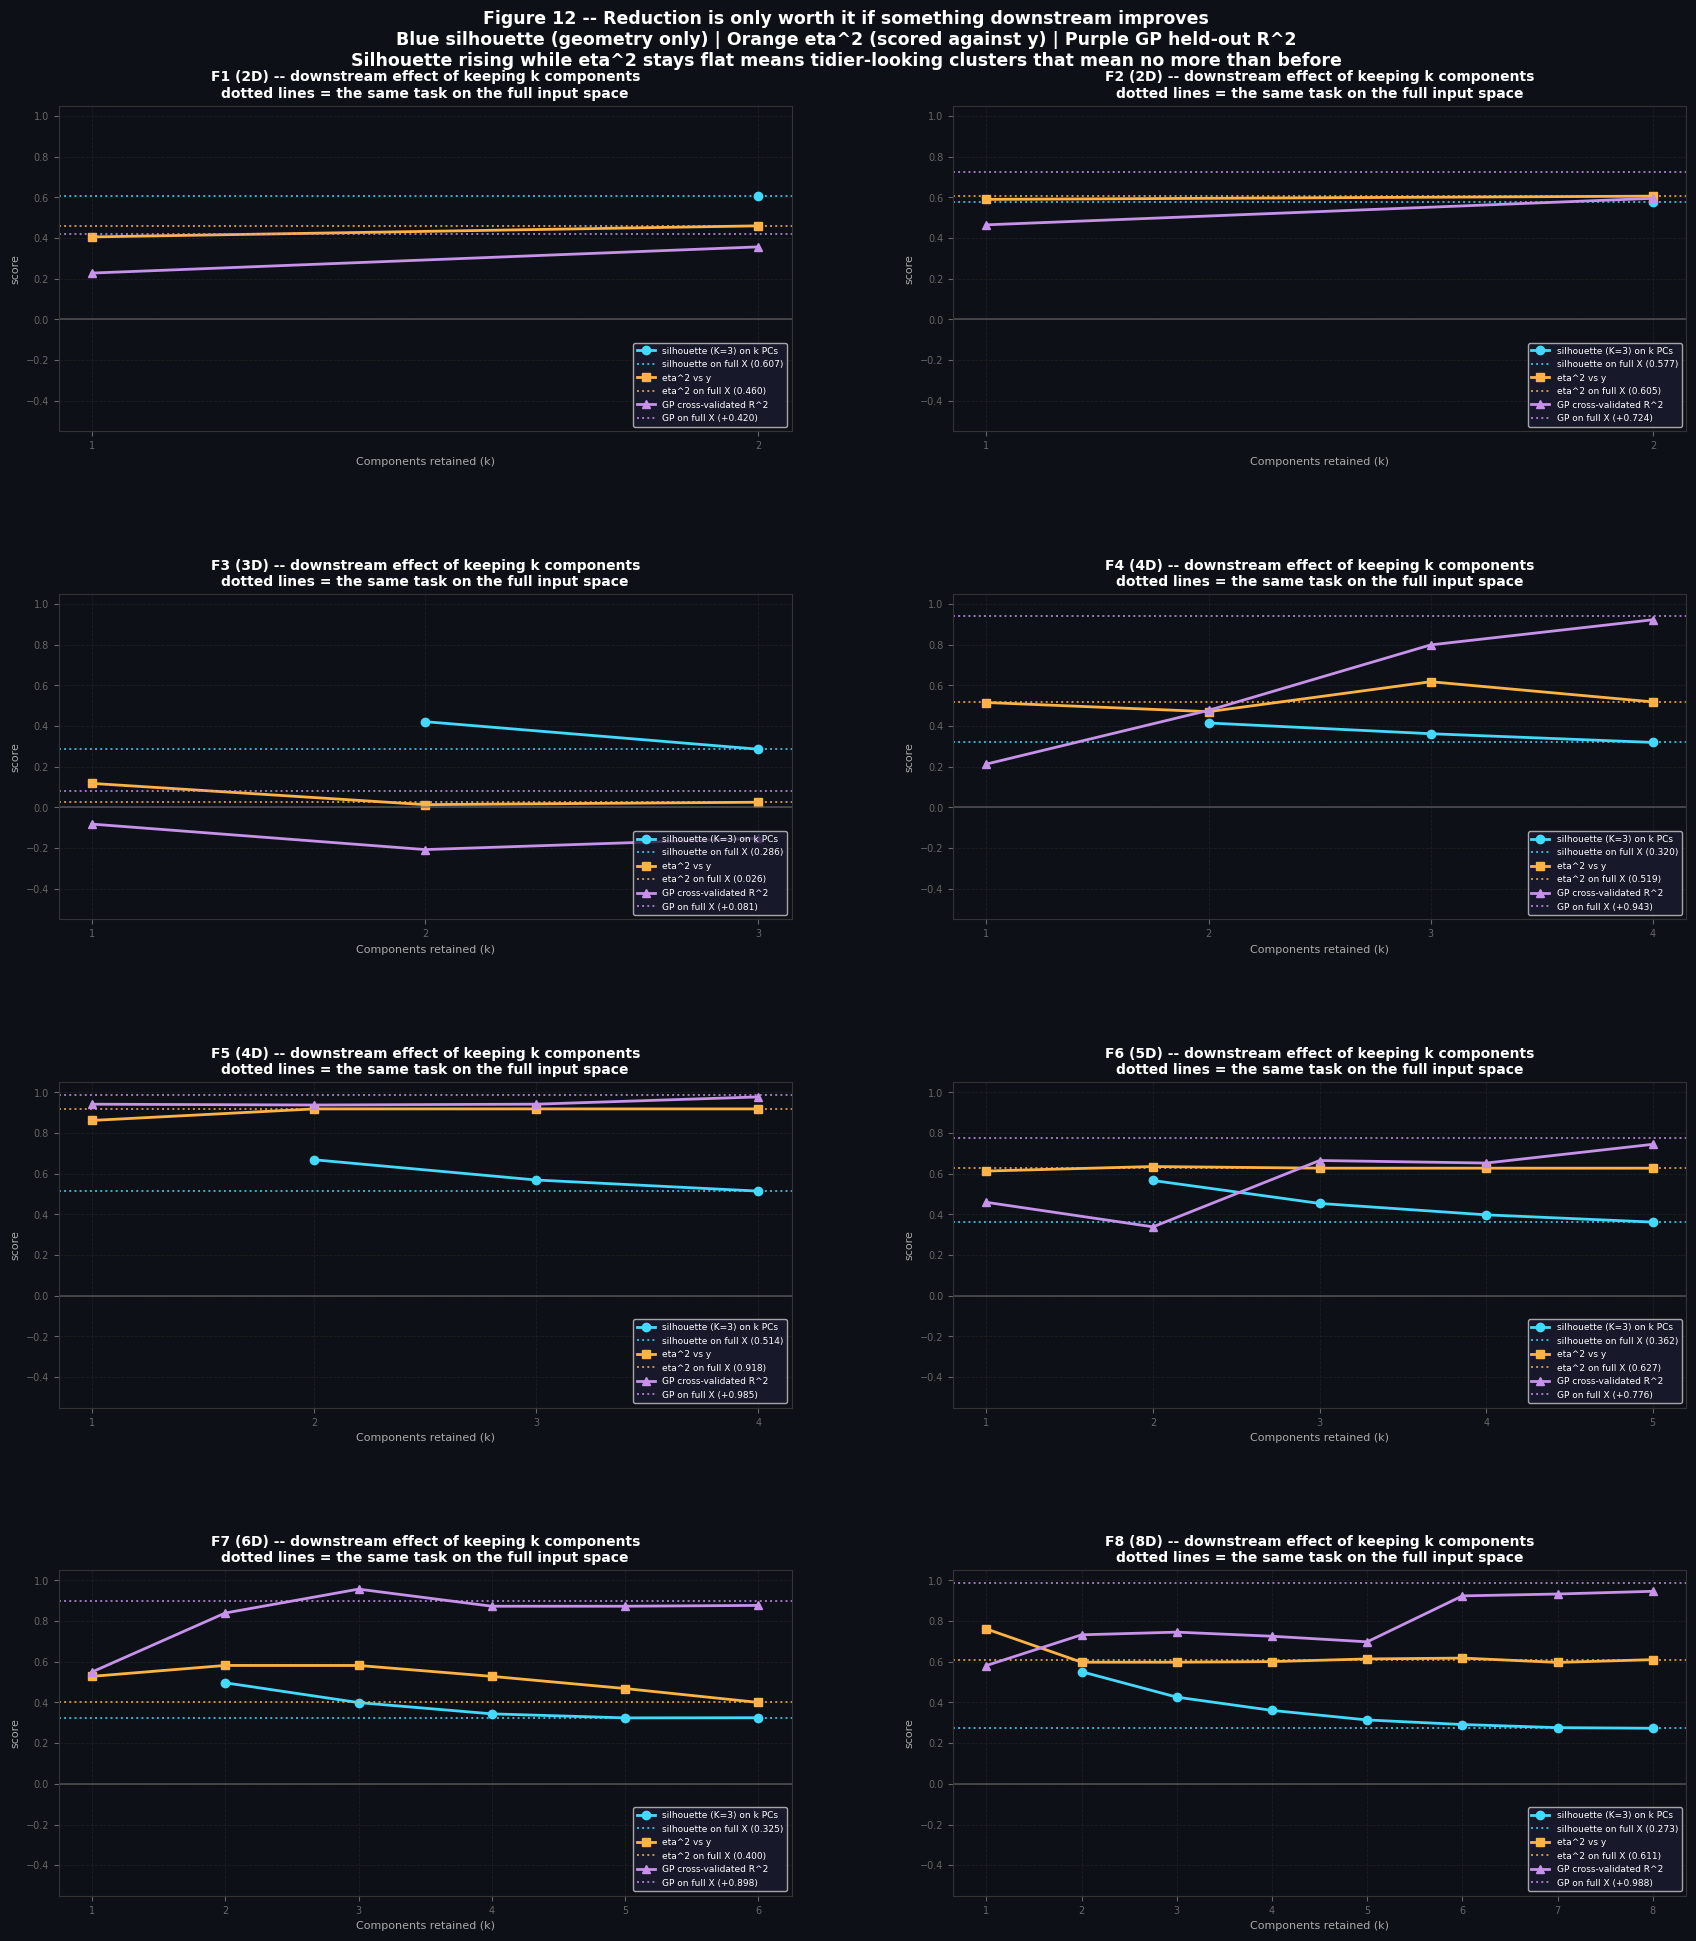

Saved pca_fig12_downstream.png


In [35]:
fig = plt.figure(figsize=(21, 20))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.22,
                       top=0.930, bottom=0.035)

for idx, fid in enumerate(FIDS):
    r, c = divmod(idx, 2)
    ax = fig.add_subplot(gs[r, c])
    style_ax(ax)
    p   = PIPE[fid]
    dim = DIMS[fid]
    ks  = np.arange(1, dim + 1)

    ax.plot(ks, p['sil'], marker='o', ms=6, lw=2, color='#44d9ff',
            label='silhouette (K=3) on k PCs')
    ax.axhline(p['sil_full'], color='#44d9ff', ls=':', lw=1.4, alpha=0.8,
               label=f"silhouette on full X ({p['sil_full']:.3f})")
    ax.plot(ks, p['eta'], marker='s', ms=6, lw=2, color='#ffb347',
            label='eta^2 vs y')
    ax.axhline(p['eta_full'], color='#ffb347', ls=':', lw=1.4, alpha=0.8,
               label=f"eta^2 on full X ({p['eta_full']:.3f})")
    ax.plot(ks, p['r2'], marker='^', ms=6, lw=2, color='#c792ea',
            label='GP cross-validated R^2')
    ax.axhline(p['r2_full'], color='#c792ea', ls=':', lw=1.4, alpha=0.8,
               label=f"GP on full X ({p['r2_full']:+.3f})")
    ax.axhline(0, color='#666666', lw=1.2, alpha=0.7)

    ax.set_xticks(ks)
    ax.set_ylim(min(-0.55, float(np.nanmin(p['r2'])) - 0.1), 1.05)
    ax.set_title(f"F{fid} ({dim}D) -- downstream effect of keeping k components\n"
                 f"dotted lines = the same task on the full input space",
                 color=TC, fontsize=10, fontweight='bold')
    ax.set_xlabel('Components retained (k)', color=AC, fontsize=8)
    ax.set_ylabel('score', color=AC, fontsize=8)
    ax.legend(fontsize=6.5, facecolor='#1a1a2e', labelcolor='white', loc='lower right')

fig.suptitle(
    'Figure 12 -- Reduction is only worth it if something downstream improves\n'
    'Blue silhouette (geometry only) | Orange eta^2 (scored against y) | Purple GP held-out R^2\n'
    'Silhouette rising while eta^2 stays flat means tidier-looking clusters that mean no more than before',
    color='white', fontsize=12.5, fontweight='bold', y=0.978)

plt.savefig('pca_fig12_downstream.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved pca_fig12_downstream.png')

---
## Section 14 — A recipe per dimensionality, and the master table

### 13.1 What to do at each rung of the ladder

| $d$ | Functions | Visualisation | Reduction | What to actually run |
|---|---|---|---|---|
| **2** | F1, F2 | Plot the raw inputs. Nothing beats the truth | PCA is a rotation; there is no useful middle between 2 and 1 | Landscape plots (A3), GP contours. Use PCA here only to learn the mechanics |
| **3–4** | F3, F4, F5 | Pairs plot is still readable (3–6 panels) | PCA can genuinely save a dimension — check the scree first | Pairs plot + PCA cross-check + PLS if a linear trend exists |
| **5–6** | F6, F7 | Direct visualisation is failing; projections take over | PCA for description, **PLS/active subspace for decisions** | Section 9's summary plot is the highest-value single figure |
| **8** | F8 | Finished. Every 2D picture is a shadow | Mandatory, but must be validated | Intrinsic dimension → active subspace → GP with ARD. Check trustworthiness before believing any scatter |

### 13.2 A decision rule you can defend in the report

1. **Is the design compressible?** Read Horn's parallel analysis (Section 5). If no component
   survives, say so and stop — the design is doing its job and PCA has no reduction to offer.
2. **If a component looks predictive, check where that came from.** Read Section 8.2 before
   Section 8.1's correlations. An association that appears only once the weekly points are included
   is the optimiser's footprint, and building a strategy on it is circular.
3. **Is the compressible direction the relevant one?** If the best-correlated component is not PC1,
   do not truncate by variance.
4. **If you need reduction anyway,** use a supervised method: PLS if the response looks linear,
   active subspace if it does not. Expect parsimony rather than a higher ceiling.
5. **Validate downstream, not in-sample.** Section 13's cross-validated comparison is the only
   evidence that a reduction helped.
6. **Say what you discarded.** A projection is a claim that some directions do not matter. That
   claim is falsifiable, so state it.

### Cell 36 — Master summary table

In [36]:
print('=' * 132)
print('  MASTER SUMMARY -- PCA and dimensionality across all eight functions')
print('=' * 132)

master = []
for fid in FIDS:
    d, s, R, A = DATA[fid], SPEC[fid], RELEV[fid], ACT[fid]
    p, L, C = PIPE[fid], LOADS[fid], CURSE[fid]
    as_pr, _ = eff_dim(A['evr'])
    master.append({
        'Fn':            f'F{fid}',
        'd':             d['dim'],
        'N':             len(d['y']),
        'PC1 %':         round(s['evr'][0] * 100, 1),
        'k(95%)':        s['k']['var95'],
        'k(Horn)':       s['k']['horn'],
        'PCA d_eff':     round(s['pr'], 2),
        'ID(2NN)':       round(C['id_obs'], 2),
        'PC1 stab.':     round(L['stab'], 2),
        'best PC for y': f"PC{R['k_best']+1}",
        'PC1~y verdict': SOURCE_TEST[fid]['verdict'],
        'PLS R2':        round(float(CV[fid]['r2_pls'].max()), 3),
        'PCR R2':        round(float(CV[fid]['r2_pcr'].max()), 3),
        'AS lam1 %':     round(A['evr'][0] * 100, 1),
        'AS d_eff':      round(as_pr, 2),
        'GP R2 (X)':     round(p['r2_full'], 3),
        'best T':        round(max(v for v in TW[fid].values() if not np.isnan(v)), 3),
        'best rho':      round(max(v for v in GLOB[fid].values() if not np.isnan(v)), 3),
    })

MASTER = pd.DataFrame(master)
print(MASTER.to_string(index=False))

print('\n' + '-' * 132)
print('  HEADLINE READINGS')
print('-' * 132)

incompressible = [f"F{f}" for f in FIDS if SPEC[f]['k']['var95'] == DIMS[f]]
print(f"\n  1. Designs needing ALL components for 95% of variance: "
      f"{', '.join(incompressible) if incompressible else 'none'}")
print("     For these, PCA offers no reduction at the conventional threshold -- which is the")
print("     correct behaviour of a space-filling design, not a failure of the method.")

induced = [f"F{f}" for f in FIDS if SOURCE_TEST[f]['verdict'] == 'search-induced']
genuine = [f"F{f}" for f in FIDS if SOURCE_TEST[f]['verdict'] == 'genuine']
print(f"\n  2. PC1-y association -- genuine: {', '.join(genuine) if genuine else 'none'}"
      f"  |  search-induced: {', '.join(induced) if induced else 'none'}")
print("     This is the single most reportable result in the notebook. For the search-induced")
print("     functions, 'PC1 predicts y' describes where the acquisition function has been")
print("     querying, not what the landscape looks like. Quoting it as structure would be")
print("     circular: it recommends the region you already chose to sample.")

mismatch = [f"F{f}" for f in FIDS if RELEV[f]['k_best'] != 0]
print(f"\n  2b. Functions where the most y-relevant component is not PC1: "
      f"{', '.join(mismatch) if mismatch else 'none'}")
print("     For these, truncating by explained variance discards signal while keeping noise.")

unstable = [f"F{f}" for f in FIDS if LOADS[f]['stab'] < 0.70]
print(f"\n  3. Functions whose PC1 direction is not identified at this sample size: "
      f"{', '.join(unstable) if unstable else 'none'}")
print("     Report the subspace or the interval, never the point estimate, for these.")

ridge = [f"F{f}" for f in FIDS if ACT[f]['evr'][0] > 0.60]
switched_off = [f"F{f}" for f in FIDS if np.any(ACT[f]['length_scale'] > 10)]
print(f"\n  4. Functions where the surrogate sees a dominant active direction (>60%): "
      f"{', '.join(ridge) if ridge else 'none'}")
print("     These are the candidates for a search steered along one linear combination --")
print(f"     but check the ARD flags first. The surrogate switched an input off entirely in: "
      f"{', '.join(switched_off) if switched_off else 'none'}")

parsimony = [f"F{f}" for f in FIDS
             if not np.isnan(CV[f]['k_reach']) and CV[f]['k_reach'] < CV[f]['k_pcr']]
print(f"\n  5. Functions where PLS reached PCR's best accuracy with FEWER components: "
      f"{', '.join(parsimony) if parsimony else 'none'}")
print("     Supervised projection does not raise the ceiling -- keep all d components and PCR,")
print("     PLS and least squares coincide. It reaches the ceiling sooner, which is what")
print("     matters when every retained component costs parameters you cannot afford.")

corr_d_sil = np.corrcoef([DIMS[f] for f in FIDS],
                         [CURSE[f]['rc_obs'] for f in FIDS])[0, 1]
print(f"\n  6. Correlation between dimension and relative contrast: {corr_d_sil:+.3f}")
print("     The curse of dimensionality, measured rather than asserted.")

  MASTER SUMMARY -- PCA and dimensionality across all eight functions
Fn  d  N  PC1 %  k(95%)  k(Horn)  PCA d_eff  ID(2NN)  PC1 stab. best PC for y                  PC1~y verdict  PLS R2  PCR R2  AS lam1 %  AS d_eff  GP R2 (X)  best T  best rho
F1  2 23   58.6       2        0       1.94     3.60       0.72           PC1                        genuine   0.090   0.128       79.8      1.48      0.420   1.000     1.000
F2  2 23   61.0       2        0       1.91     2.65       0.90           PC1 inconclusive (small initial n)   0.247   0.228      100.0      1.00      0.724   1.000     1.000
F3  3 28   43.3       3        0       2.71     4.05       0.74           PC3      no association either way  -0.292  -0.171       69.2      1.74      0.081   0.951     0.928
F4  4 43   37.0       4        0       3.53     3.34       0.78           PC1                        genuine   0.181   0.219       40.5      3.49      0.943   0.917     0.898
F5  4 33   52.3       4        1       2.75     4.88   

---
## Section 15 — Limitations, exercises, and what belongs in the report

### 14.1 What this analysis established

Fill this in from the master table — the numbers move every week as observations arrive, so
re-read it rather than copying last week's sentence forward. Four questions worth answering:

1. **Is each design compressible, and by how much?** Quote `k(Horn)` rather than `k(95%)`: the
   former has a stated null hypothesis, the latter has a convention.
2. **Which PC1–$y$ associations are genuine and which did the optimiser manufacture?** This is the
   result with the most direct bearing on how the team reads every other diagnostic, because the
   same contamination affects A1, A2 and A4 — all four notebooks are fitted on a sample that the
   acquisition function has been editing. Section 8.2 gives the split; Section 6 corroborates it
   from the geometry side.
3. **Did any function show a dominant active direction?** That is the finding with the clearest
   operational consequence — it makes a high-$d$ search tractable — but pair it with the ARD
   switched-off flags, since a surrogate that has decided an input is irrelevant will produce a
   confident active subspace that simply agrees with itself.
4. **How does the ladder behave?** The $d = 2 \to 8$ trend in relative contrast and in downstream
   performance is a self-contained result, and it explains A4's degrading silhouettes.

### 14.2 Limitations — state these explicitly

- **Sample size.** 22–52 observations. A covariance matrix in 8D has 36 free parameters; F8
  estimates them from 52 points. Every eigenvector is provisional, which is why Section 7
  bootstraps rather than asserts.
- **The observations are not a random sample.** Weekly points come from an acquisition function
  that concentrates queries deliberately. Any spectrum computed on all observations is partly a
  picture of the GP's search history. Section 6 separates the two; do not skip that split when
  quoting a number.
- **PCA is linear and unsupervised.** Both limits bite here, and Sections 8–10 measure by how much.
- **The active subspace inherits the surrogate.** Gradients come from a GP fitted to a few dozen
  points. The `MC vs obs |cos|` column is the robustness check; treat anything below 0.9 as
  provisional.
- **$t$-SNE and UMAP coordinates are not measurements.** Do not compute distances on them, do not
  feed them to a model, do not compare cluster sizes across panels.
- **Cross-validated $R^2$ at $n \approx 30$ is itself noisy.** A difference of 0.05 between two
  methods is not a result. Differences of the size seen in Section 8 for PLS-vs-PCR on one
  component are worth reporting; smaller ones are not.
- **PCA cannot propose a query.** No uncertainty model, no acquisition function. Diagnostic only,
  exactly like A1, A2 and A4.

### 14.3 How this notebook relates to the rest of the project

| Notebook | Paradigm | Uses $y$ | Can propose a query? |
|---|---|---|---|
| A1 — SVM | Supervised | Manufactured label | No (diagnostic) |
| A2 — Logistic regression | Supervised | Manufactured label | No (diagnostic) |
| A4 — Clustering | Unsupervised | External validator only | No (diagnostic) |
| **A5 — PCA & dimensionality (this)** | **Unsupervised, then supervised** | **Validator in §5–7, target in §8–9** | **No (diagnostic)** |
| 05 — GP suggest engine | Bayesian surrogate | Regression target | **Yes** |

The value is in triangulation. Where A2's coefficients, A4's best cluster, this notebook's active
direction, and the GP's proposal all point the same way, confidence is high. Where they conflict,
the GP takes precedence: it is the only one that models the response surface and quantifies its own
uncertainty.

### 14.4 Exercises

1. **Change the $y$ treatment.** Re-run Sections 8 and 9 with `Y_MODE` forced to `'rank'` for every
   function. Which conclusions move? Anything that flips was resting on a handful of extreme values.
2. **Split by week.** Compute the spectrum using weeks 0–6 only, then 0–12. Plot effective dimension
   against week. Is the optimiser concentrating the design over time, and by how much?
3. **Break PCA on purpose.** Multiply one input column of F7 by 1000 before standardising, and again
   without standardising. Confirm from the loadings which analysis survives.
4. **Test the ridge hypothesis.** For the function with the largest `AS lam1 %`, generate 200 points
   along $\mathbf{v}_1$ through the current best point, predict with the GP, and check whether the
   predicted profile matches the sufficient summary plot.
5. **Reproduce the curse.** Simulate Latin hypercube designs at $d = 2, 4, 8, 16, 32$ with $n = 40$
   and plot relative contrast against $d$. Overlay our eight functions. Do they sit on the curve?
6. **Compare with A4.** Take the K-Means labels from A4 and colour Figure 10's embeddings by them.
   Do the clusters remain contiguous under a nonlinear embedding, or does the projection scatter them?

### 14.5 Reproducibility

Every stochastic component is seeded with `RANDOM_STATE = 42`: PCA and sparse PCA, K-Means restarts,
the GP's optimiser restarts, all bootstraps and permutation tests, the CV fold assignment, and the
$t$-SNE/MDS/random-projection initialisations. Re-running on the same CSV reproduces every number
and figure exactly.

### Cell 37 — Completion report

In [37]:
print('=' * 100)
print('  NOTEBOOK COMPLETE')
print('=' * 100)
print(f'  Functions analysed : {len(FIDS)}  (F1-F8, dimensions '
      f'{", ".join(str(DIMS[f]) for f in FIDS)})')
print(f'  Observations       : {len(OBS)}')
print(f'  Linear methods     : PCA (hand-computed, SVD, sklearn), sparse PCA, PCR, PLS')
print(f'  Supervised         : PLS, active subspaces via GP gradients, GP with ARD')
print(f'  Nonlinear          : kernel PCA, Isomap, MDS, t-SNE'
      + (', UMAP' if HAS_UMAP else '') + ', random projection (baseline)')
print(f'  Validation         : parallel analysis, broken stick, bootstrap loadings,')
print(f'                       permutation tests, {CV_FOLDS}-fold CV, trustworthiness')
print(f'  Random state       : {RANDOM_STATE}   (fully reproducible)')

print('\n  Figures written to the notebook folder:')
for i, name in enumerate([
        'y_transforms', 'geometry_2d', 'scree_gallery', 'design_vs_search',
        'loadings', 'variance_vs_relevance', 'active_subspace',
        'kernel_pca_circles', 'kernel_gamma_sweep',
        'embedding_gallery', 'curse_of_dimensionality', 'downstream'], start=1):
    print(f'    pca_fig{i}_{name}.png')

print('\n  Objects available for further work in this kernel:')
for name, desc in [
        ('DATA',    'per-function X, y, and the initial/weekly split'),
        ('DOSSIER', 'output of explore() for every function'),
        ('SPEC',    'spectra, nulls, retention rules, standardised matrices'),
        ('ANISO',   'initial-vs-all comparison with bootstrap intervals'),
        ('LOADS',   'loadings with bootstrap intervals and stability scores'),
        ('RELEV',   'PC-to-y correlations with permutation p-values'),
        ('CV',      'PCR and PLS cross-validated R^2 curves'),
        ('ACT',     'active subspaces, surrogates, ARD length-scales'),
        ('EMB/TW',  'nonlinear embeddings and trustworthiness scores'),
        ('CURSE',   'intrinsic dimension and distance concentration'),
        ('PIPE',    'downstream K-Means and GP results'),
        ('MASTER',  'the master summary DataFrame')]:
    print(f'    {name:<9} {desc}')

print('\n  Try:  explore(6)   for a full dossier on any function')
print('        MASTER         for the summary table as a DataFrame')
print('\n  Reminder: this is a diagnostic notebook. It describes structure and measures')
print('  dimensionality; it does not select queries. The GP surrogate in notebook 05')
print('  remains the decision engine.')

  NOTEBOOK COMPLETE
  Functions analysed : 8  (F1-F8, dimensions 2, 2, 3, 4, 4, 5, 6, 8)
  Observations       : 279
  Linear methods     : PCA (hand-computed, SVD, sklearn), sparse PCA, PCR, PLS
  Supervised         : PLS, active subspaces via GP gradients, GP with ARD
  Nonlinear          : kernel PCA, Isomap, MDS, t-SNE, random projection (baseline)
  Validation         : parallel analysis, broken stick, bootstrap loadings,
                       permutation tests, 5-fold CV, trustworthiness
  Random state       : 42   (fully reproducible)

  Figures written to the notebook folder:
    pca_fig1_y_transforms.png
    pca_fig2_geometry_2d.png
    pca_fig3_scree_gallery.png
    pca_fig4_design_vs_search.png
    pca_fig5_loadings.png
    pca_fig6_variance_vs_relevance.png
    pca_fig7_active_subspace.png
    pca_fig8_kernel_pca_circles.png
    pca_fig9_kernel_gamma_sweep.png
    pca_fig10_embedding_gallery.png
    pca_fig11_curse_of_dimensionality.png
    pca_fig12_downstream.png

  Objec